In [1]:
# ==============================================================================
# PASO 1: PREPARACIÓN DE DATOS PARA EXPERIMENTOS  (SPLIT 85/15)
# ==============================================================================
# Este script escanea las fuentes, elimina duplicados y genera los archivos
# para las combinaciones específicas: R+H, D+H, y R+D+H.
# Cada combinación tendrá un 85% para train/val y un 15% para test.
# ------------------------------------------------------------------------------

import os
import sys
import pandas as pd
import numpy as np
from collections import defaultdict
from PIL import Image
import imagehash
from sklearn.model_selection import train_test_split
import random
import warnings
warnings.filterwarnings("ignore")

# --- CONFIGURACION ----------------
SEED = 44
random.seed(SEED)
np.random.seed(SEED)

ROOTS = {
    "roboflow": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe",
    "dermnet": "/kaggle/input/dermnet/DermNet",
    "hospital": "/kaggle/input/imageneshospital/Hospital/Hospital" 
}

OUT_BASE = "/kaggle/working/datasets_csv_85_15_caseib"
os.makedirs(OUT_BASE, exist_ok=True)
SPLITS_DIR = os.path.join(OUT_BASE, "splits")
os.makedirs(SPLITS_DIR, exist_ok=True)

# --- Porcentaje para el conjunto de Test Final ---
TEST_SPLIT_RATIO = 0.15

# (El resto de la configuración y las funciones auxiliares se mantienen igual)
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
MAIN_CLASSES = [
    "Psoriasis Vulgar", "Psoriasis Guttata", "Psoriasis Inversa",
    "Psoriasis Pustulosa", "Psoriasis Eritrodermica"
]
CONFIRM_DELETE_DUPES = True

# --- Helpers (sin cambios) ---
def is_image_file(fname):
    return os.path.splitext(fname)[1].lower() in IMG_EXTS

def scan_and_compute_phash(roots):
    records = []
    print("Escaneando rutas y calculando phash...")
    for source, root in roots.items():
        if not os.path.exists(root):
            print(f"WARNING: ruta no existe: {root} (skipping)")
            continue
        for dirpath, _, files in os.walk(root):
            for f in files:
                if not is_image_file(f): continue
                filepath = os.path.join(dirpath, f)
                rel = os.path.relpath(filepath, root)
                parts = rel.split(os.sep)
                label = parts[0] if len(parts) >= 2 else os.path.basename(dirpath)
                phash_hex = None
                try:
                    img = Image.open(filepath).convert("RGB")
                    phash_hex = str(imagehash.phash(img))
                except Exception as e:
                    print(f"  ERROR leyendo {filepath}: {e}")
                records.append({
                    "filepath": filepath, "label": label, "source": source,
                    "phash_hex": phash_hex
                })
    return pd.DataFrame(records)

def list_exact_duplicate_groups(df):
    d = defaultdict(list);
    for i, r in df.iterrows():
        phash = r.get("phash_hex")
        if phash:
            d[phash].append(r["filepath"])
    return {ph: paths for ph, paths in d.items() if len(paths) > 1}

def normalize_label_text(lbl):
    if pd.isna(lbl): return lbl
    s = str(lbl).strip().lower().replace('-', ' ').replace('_', ' ')
    if 'pustular' in s or 'pustul' in s: return "Psoriasis Pustulosa"
    if 'vulgar' in s or 'plaque' in s or 'plaqu' in s: return "Psoriasis Vulgar"
    if 'guttate' in s or 'gutt' in s: return "Psoriasis Guttata"
    if 'inverse' in s or 'inversa' in s: return "Psoriasis Inversa"
    if 'erythrodermic' in s or 'eritro' in s or 'eryth' in s: return "Psoriasis Eritrodermica"
    return str(lbl).strip().title()

def reassign_label_logic(row):
    normalized = normalize_label_text(row.get("label", None))
    if normalized in MAIN_CLASSES: return normalized
    return normalized

def safe_stratified_split(df, strat_col, test_size, seed=SEED):
    try:
        a, b = train_test_split(df, test_size=test_size, stratify=df[strat_col], random_state=seed)
    except Exception as e:
        print(f"  [Aviso] Stratified split falló ({e}). Realizando split aleatorio.")
        a, b = train_test_split(df, test_size=test_size, shuffle=True, random_state=seed)
    return a.reset_index(drop=True), b.reset_index(drop=True)

# --- Ejecución del Pipeline ---

# 1. Escaneo y de-duplicación inicial
df_phash = scan_and_compute_phash(ROOTS)
duplicate_groups = list_exact_duplicate_groups(df_phash)
to_drop = set(p for paths in duplicate_groups.values() for p in paths[1:])
df_no_dupes = df_phash[~df_phash['filepath'].isin(to_drop)].reset_index(drop=True)

# 2. Re-etiquetado y filtrado
df_no_dupes['label_reassigned'] = df_no_dupes.apply(reassign_label_logic, axis=1)
# Filtrar para mantener solo las clases principales
df_final = df_no_dupes[df_no_dupes['label_reassigned'].isin(MAIN_CLASSES)].reset_index(drop=True)
print(f"\nTotal imágenes únicas y filtradas: {len(df_final)}")
print(df_final['source'].value_counts())

# --- MODIFICACIÓN CLAVE: Definir los datasets para los experimentos del CASEIB ---
# 3. Definir las combinaciones de datasets que se crearán
datasets_to_process = {
    'roboflow': df_final[df_final['source'].isin(['roboflow'])],
    'dermnet': df_final[df_final['source'].isin(['dermnet'])],
    'roboflow_hospital': df_final[df_final['source'].isin(['roboflow', 'hospital'])],
    'dermnet_hospital': df_final[df_final['source'].isin(['dermnet', 'hospital'])],
    'roboflow_dermnet': df_final[df_final['source'].isin(['roboflow', 'dermnet'])],
    'roboflow_dermnet_hospital': df_final[df_final['source'].isin(['roboflow', 'dermnet', 'hospital'])]
}

# 4. Función para crear el split 85/15 (sin cambios)
def create_final_splits(name, dfi):
    print(f"\nProcesando dataset '{name}' con {len(dfi)} imágenes...")
    if dfi.empty:
        print("  - dataset vacío, saltando.")
        return
        
    # Realizar el split 85/15
    df_train_val, df_test = safe_stratified_split(dfi, 'label_reassigned', test_size=TEST_SPLIT_RATIO, seed=SEED)
    
    print(f"  - Split generado: {len(df_train_val)} para Train/Val (85%) y {len(df_test)} para Test (15%).")

    # Guardar los dos archivos CSV
    path_train_val = os.path.join(SPLITS_DIR, f"{name}_train_val_85.csv")
    path_test = os.path.join(SPLITS_DIR, f"{name}_test_15.csv")
    
    df_train_val.to_csv(path_train_val, index=False)
    df_test.to_csv(path_test, index=False)
    
    print(f"  - Archivos guardados en: {SPLITS_DIR}")

# 5. Iterar y crear los splits para cada dataset definido
for name, df_instance in datasets_to_process.items():
    create_final_splits(name, df_instance)

print("\nPipeline de preparación de imágenes finalizado.")

Escaneando rutas y calculando phash...

Total imágenes únicas y filtradas: 977
source
dermnet     496
roboflow    445
hospital     36
Name: count, dtype: int64

Procesando dataset 'roboflow' con 445 imágenes...
  - Split generado: 378 para Train/Val (85%) y 67 para Test (15%).
  - Archivos guardados en: /kaggle/working/datasets_csv_85_15_caseib/splits

Procesando dataset 'dermnet' con 496 imágenes...
  - Split generado: 421 para Train/Val (85%) y 75 para Test (15%).
  - Archivos guardados en: /kaggle/working/datasets_csv_85_15_caseib/splits

Procesando dataset 'roboflow_hospital' con 481 imágenes...
  - Split generado: 408 para Train/Val (85%) y 73 para Test (15%).
  - Archivos guardados en: /kaggle/working/datasets_csv_85_15_caseib/splits

Procesando dataset 'dermnet_hospital' con 532 imágenes...
  - Split generado: 452 para Train/Val (85%) y 80 para Test (15%).
  - Archivos guardados en: /kaggle/working/datasets_csv_85_15_caseib/splits

Procesando dataset 'roboflow_dermnet' con 941 i

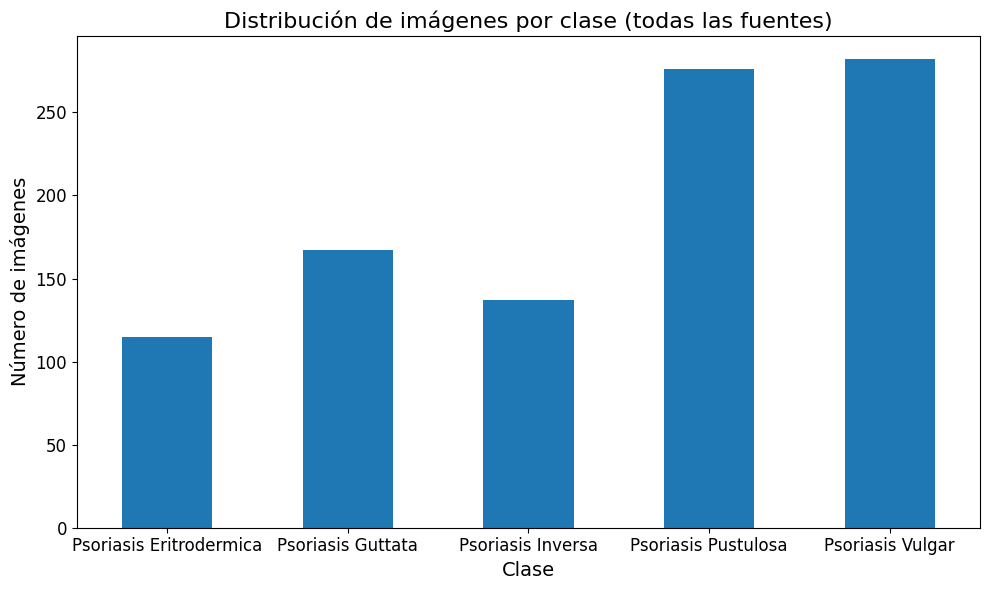

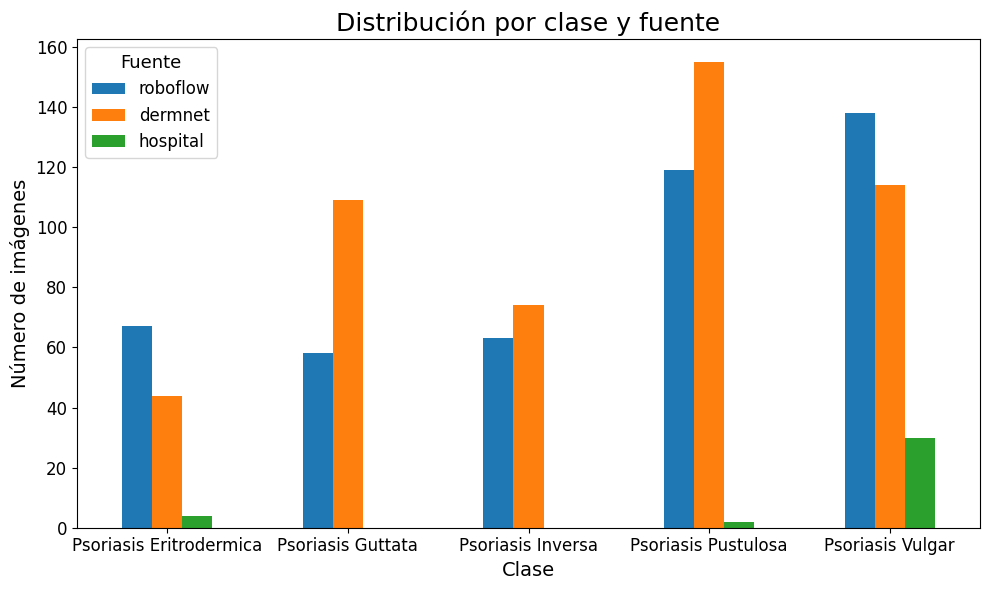

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# df_final: DataFrame resultante tras la preparación (label_reassigned, source)

# 1) Distribución por clase (todas las fuentes)
class_counts = df_final['label_reassigned'].value_counts().sort_index()
plt.figure(figsize=(10,6))
class_counts.plot(kind='bar')

plt.title("Distribución de imágenes por clase (todas las fuentes)", fontsize=16)
plt.xlabel("Clase", fontsize=14)
plt.ylabel("Número de imágenes", fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("distribucion_por_clase.png", dpi=300)
plt.show()

# 2) Distribución por clase y fuente (barras agrupadas)
pivot = df_final.pivot_table(
    index='label_reassigned', 
    columns='source', 
    aggfunc='size', 
    fill_value=0
)

# Ordenar clases alfabéticamente si se desea
pivot = pivot.reindex(index=sorted(pivot.index))

# Reordenar columnas: Roboflow -> Dermnet -> Hospital
col_order = ['roboflow', 'dermnet', 'hospital']
pivot = pivot[[c for c in col_order if c in pivot.columns]]

pivot.plot(kind='bar', figsize=(10,6))

plt.title("Distribución por clase y fuente", fontsize=18)
plt.xlabel("Clase", fontsize=14)
plt.ylabel("Número de imágenes", fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Fuente', fontsize=12, title_fontsize=13)

plt.tight_layout()
plt.savefig("distribucion_por_clase_y_fuente.png", dpi=300)
plt.show()


In [6]:
# ==============================================================================
# SCRIPT PARA ENCONTRAR UN EJEMPLO DE CADA CLASE POR DATASET
# ==============================================================================
import os
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# --- CONFIGURACIÓN (SIN CAMBIOS) ---
ROOTS = {
    "roboflow": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe",
    "dermnet": "/kaggle/input/dermnet/DermNet",
    "hospital": "/kaggle/input/imageneshospital/Hospital/Hospital"
}

MAIN_CLASSES = [
    "Psoriasis Vulgar", "Psoriasis Guttata", "Psoriasis Inversa",
    "Psoriasis Pustulosa", "Psoriasis Eritrodermica"
]

# --- FUNCIONES AUXILIARES ---
def normalize_label_text(lbl):
    """Unifica los nombres de las etiquetas para evitar inconsistencias."""
    if pd.isna(lbl): return lbl
    s = str(lbl).strip().lower().replace('-', ' ').replace('_', ' ')
    if 'pustular' in s or 'pustul' in s: return "Psoriasis Pustulosa"
    if 'vulgar' in s or 'plaque' in s or 'plaqu' in s: return "Psoriasis Vulgar"
    if 'guttate' in s or 'gutt' in s: return "Psoriasis Guttata"
    if 'inverse' in s or 'inversa' in s: return "Psoriasis Inversa"
    if 'erythrodermic' in s or 'eritro' in s or 'eryth' in s: return "Psoriasis Eritrodermica"
    return str(lbl).strip().title()

def find_first_image_of_each_class_by_source(roots_dict, main_classes):
    """
    Escanea directorios y encuentra la primera imagen de cada clase principal
    por cada fuente de datos.
    """
    results = {}
    
    for source_name, root_path in roots_dict.items():
        print(f"Buscando en la fuente: {source_name}")
        results[source_name] = {}
        found_classes = set()
        
        if not os.path.exists(root_path):
            print(f"  AVISO: La ruta '{root_path}' no existe. Saltando.")
            continue
            
        for dirpath, _, files in os.walk(root_path):
            if len(found_classes) == len(main_classes):
                break
                
            for f in files:
                label_raw = os.path.basename(dirpath)
                label_normalized = normalize_label_text(label_raw)
                
                if label_normalized in main_classes and label_normalized not in found_classes:
                    filepath = os.path.join(dirpath, f)
                    if os.path.splitext(f)[1].lower() in {".jpg", ".jpeg", ".png"}:
                        results[source_name][label_normalized] = filepath
                        found_classes.add(label_normalized)
                        print(f"  Encontrada {label_normalized}: {filepath}")
                        break
    return results

# --- EJECUCIÓN DEL SCRIPT ---
if __name__ == "__main__":
    found_images = find_first_image_of_each_class_by_source(ROOTS, MAIN_CLASSES)
    
    print("\n=======================================================")
    print("RESUMEN DE IMÁGENES ENCONTRADAS")
    print("=======================================================")
    
    for source, classes in found_images.items():
        print(f"\n--- Fuente: {source.upper()} ---")
        if not classes:
            print("No se encontraron imágenes en esta fuente.")
        else:
            for class_name, filepath in classes.items():
                print(f"  {class_name}: {filepath}")

Buscando en la fuente: roboflow
  Encontrada Psoriasis Eritrodermica: /kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Eritrodermica/c0261149-800px-wm_jpg.rf.4e5b3eecbb15abfc692488349e1c2d97.jpg
  Encontrada Psoriasis Vulgar: /kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Vulgar/Psoriasis-Chronic-Plaque-110_jpg.rf.bfcff5ed1aec80ac6447cf001075de61.jpg
  Encontrada Psoriasis Inversa: /kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Inversa/Psoriasis-inversus-30_jpg.rf.340f1194cf910696de5bf7097aecd10b.jpg
  Encontrada Psoriasis Guttata: /kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Guttata/Psoriasis-Guttate-29_jpg.rf.65e30da5e64dc37e0e34f3336e364c52.jpg
  Encontrada Psoriasis Pustulosa: /kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Pustulosa/psoriasis-palms-soles-179_jpg.rf.133e2ef7912566660ff85e79d9a2a176.jpg
Buscando en la fuente: dermnet
  Encontrada Psoriasis Eritrodermica: /kaggle/i

In [7]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# ==============================================================================
# INSTRUCCIONES:
# 1. PEGA AQUÍ LAS RUTAS DE LAS IMÁGENES QUE ENCONTRASTE CON TU SCRIPT ANTERIOR.
# 2. ASEGÚRATE DE QUE LAS RUTAS SON CORRECTAS Y LAS IMÁGENES EXISTEN.
# 3. EJECUTA EL SCRIPT.
# ==============================================================================

# --- DATOS DE ENTRADA CON RUTAS DE EJEMPLO ---
# Reemplaza estas rutas con las que obtuviste de tu sistema.
image_paths = {
    "roboflow": {
        "Psoriasis Vulgar": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Vulgar/1-plaque-psoriasis-symptoms-6_jpg.rf.d231945a0505872111eb9ab798836512.jpg",
        "Psoriasis Guttata": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Guttata/d15197824707833075_jpg.rf.48a07f0f62261771ed4f669048a1d13f.jpg",
        "Psoriasis Inversa": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Inversa/intertriginous-psoriasis-symptoms-14_jpg.rf.52358b688d01d4a03423b04c35e3b5e4.jpg",
        "Psoriasis Pustulosa": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Pustulosa/images-12_jpg.rf.9b6f8497d394b9175d27d2c38d386407.jpg",
        "Psoriasis Eritrodermica": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Eritrodermica/Erythrodermic-Psoriasis-Symptoms_jpg.rf.231c5182103328e7529f7983637651a1.jpg",
    },
    "dermnet": {
        "Psoriasis Vulgar": "/kaggle/input/dermnet/DermNet/Psoriasis Vulgar/psoriasis-13_orig_2.jpg",
        "Psoriasis Guttata": "/kaggle/input/dermnet/DermNet/Psoriasis Guttata/psoriasis-guttate-2.jpg",
        "Psoriasis Inversa": "/kaggle/input/dermnet/DermNet/Psoriasis Inversa/inverse-psoriasis-1_orig.jpg",
        "Psoriasis Pustulosa": "/kaggle/input/dermnet/DermNet/Psoriasis Pustulosa/pustular-psoriasis-16.jpg",
        "Psoriasis Eritrodermica": "/kaggle/input/dermnet/DermNet/Psoriasis Eritrodermica/psoriasis-erythrodermic-1.jpg",
    },
    "hospital": {
        "Psoriasis Vulgar": "/kaggle/input/imageneshospital/Hospital/Hospital/Psoriasis Vulgar/psoriasis-vulgar.jpg",
        "Psoriasis Guttata": "/kaggle/input/imageneshospital/Hospital/Hospital/Psoriasis Guttata/guttata.jpg",
        "Psoriasis Inversa": "/kaggle/input/imageneshospital/Hospital/Hospital/Psoriasis Inversa/inversa.jpg",
        "Psoriasis Pustulosa": "/kaggle/input/imageneshospital/Hospital/Hospital/Psoriasis Pustulosa/pustulosa.jpg",
        "Psoriasis Eritrodermica": "/kaggle/input/imageneshospital/Hospital/Hospital/Psoriasis Eritrodermica/eritrodermica.jpg",
    }
}

# --- PARÁMETROS DE CONFIGURACIÓN ---
OUTPUT_DIR = "/kaggle/working/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
IMG_SIZE = (300, 300) # Tamaño de cada sub-imagen
DPI = 300 # Puntos por pulgada para alta calidad
plt.style.use('seaborn-v0_8-whitegrid')

# --- FUNCIÓN PARA CREAR Y GUARDAR CADA FIGURA ---
def create_and_save_figure_by_dataset(data_paths, output_dir, img_size, dpi):
    for source, class_images in data_paths.items():
        if not class_images:
            print(f"No hay imágenes para el dataset '{source}'. Saltando.")
            continue
            
        class_names = list(class_images.keys())
        
        # Crear la figura con 2 filas y 3 columnas
        fig, axes = plt.subplots(2, 3, figsize=(9, 6))
        fig.suptitle(f'Ejemplos de {source.upper()}', fontsize=16, weight='bold')
        
        # Aplanar el array de axes para iterar fácilmente
        ax_flat = axes.flatten()
        
        for i, class_name in enumerate(class_names):
            ax = ax_flat[i]
            img_path = class_images.get(class_name)
            
            if img_path and os.path.exists(img_path):
                try:
                    img = Image.open(img_path).convert("RGB").resize(img_size, Image.Resampling.LANCZOS)
                    ax.imshow(img)
                except Exception as e:
                    print(f"Error al cargar la imagen {img_path}: {e}")
                    ax.text(0.5, 0.5, 'Error de carga', ha='center', va='center', color='red')
            else:
                ax.text(0.5, 0.5, 'Imagen no encontrada', ha='center', va='center', color='red')
            
            ax.set_title(class_name.split(' ')[1].upper(), fontsize=10, weight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
        
        # Ocultar el último subplot, que no se utiliza
        ax_flat[-1].axis('off')
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        
        output_filename = os.path.join(output_dir, f"{source}_psoriasis_examples.png")
        plt.savefig(output_filename, dpi=dpi, bbox_inches='tight')
        plt.close(fig)
        print(f"\nFigura para '{source}' guardada en alta resolución en: {output_filename}")

# --- EJECUCIÓN DEL SCRIPT ---
if __name__ == "__main__":
    create_and_save_figure_by_dataset(image_paths, OUTPUT_DIR, IMG_SIZE, DPI)


Figura para 'roboflow' guardada en alta resolución en: /kaggle/working/figures/roboflow_psoriasis_examples.png

Figura para 'dermnet' guardada en alta resolución en: /kaggle/working/figures/dermnet_psoriasis_examples.png

Figura para 'hospital' guardada en alta resolución en: /kaggle/working/figures/hospital_psoriasis_examples.png


## Curvas Loss y accuracy


2025-09-01 16:59:31.920097: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756745972.254681      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756745972.347669      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Datos cargados para 'roboflow':
  - 378 imágenes para K-Fold (85%)
  - 67 imágenes para Test Final (15%)
Clases detectadas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====

===== INICIANDO NIVEL 2: ENTRENAMIENTO Y EVALUACIÓN DEL MODELO FINAL =====
Cargando el dataset completo de train/val para el modelo final...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 117 imágenes. Objetivo por clase: 292
Generando 235 imágenes para la clase Psoriasis Eritrodermica...
Generando 243 imágenes para la clase Psoriasis Guttata...
Generando 238 imágenes para la clase Psoriasis Inversa...
Generando 191 imágenes para la clase Psoriasis Pustulosa...
Generando 175 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.


I0000 00:00:1756746002.676855      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756746002.677569      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenando modelo final con 1460 imágenes...
Epoch 1/100


I0000 00:00:1756746023.846058     102 service.cc:148] XLA service 0x7eea84091bc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756746023.847619     102 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756746023.847641     102 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756746025.775001     102 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756746035.611063     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


165/165 - 50s - 305ms/step - accuracy: 0.6750 - loss: 0.9179 - val_accuracy: 0.8288 - val_loss: 0.4758 - learning_rate: 0.0010
Epoch 2/100
165/165 - 3s - 17ms/step - accuracy: 0.8638 - loss: 0.3786 - val_accuracy: 0.8630 - val_loss: 0.4074 - learning_rate: 0.0010
Epoch 3/100
165/165 - 2s - 13ms/step - accuracy: 0.8866 - loss: 0.3008 - val_accuracy: 0.8562 - val_loss: 0.4829 - learning_rate: 0.0010
Epoch 4/100
165/165 - 3s - 16ms/step - accuracy: 0.9178 - loss: 0.2089 - val_accuracy: 0.8836 - val_loss: 0.3788 - learning_rate: 0.0010
Epoch 5/100
165/165 - 2s - 13ms/step - accuracy: 0.9323 - loss: 0.1660 - val_accuracy: 0.8425 - val_loss: 0.6792 - learning_rate: 0.0010
Epoch 6/100
165/165 - 3s - 16ms/step - accuracy: 0.9589 - loss: 0.1224 - val_accuracy: 0.8904 - val_loss: 0.4339 - learning_rate: 0.0010
Epoch 7/100
165/165 - 2s - 14ms/step - accuracy: 0.9361 - loss: 0.1983 - val_accuracy: 0.8904 - val_loss: 0.4461 - learning_rate: 0.0010
Epoch 8/100
165/165 - 2s - 13ms/step - accuracy: 0.

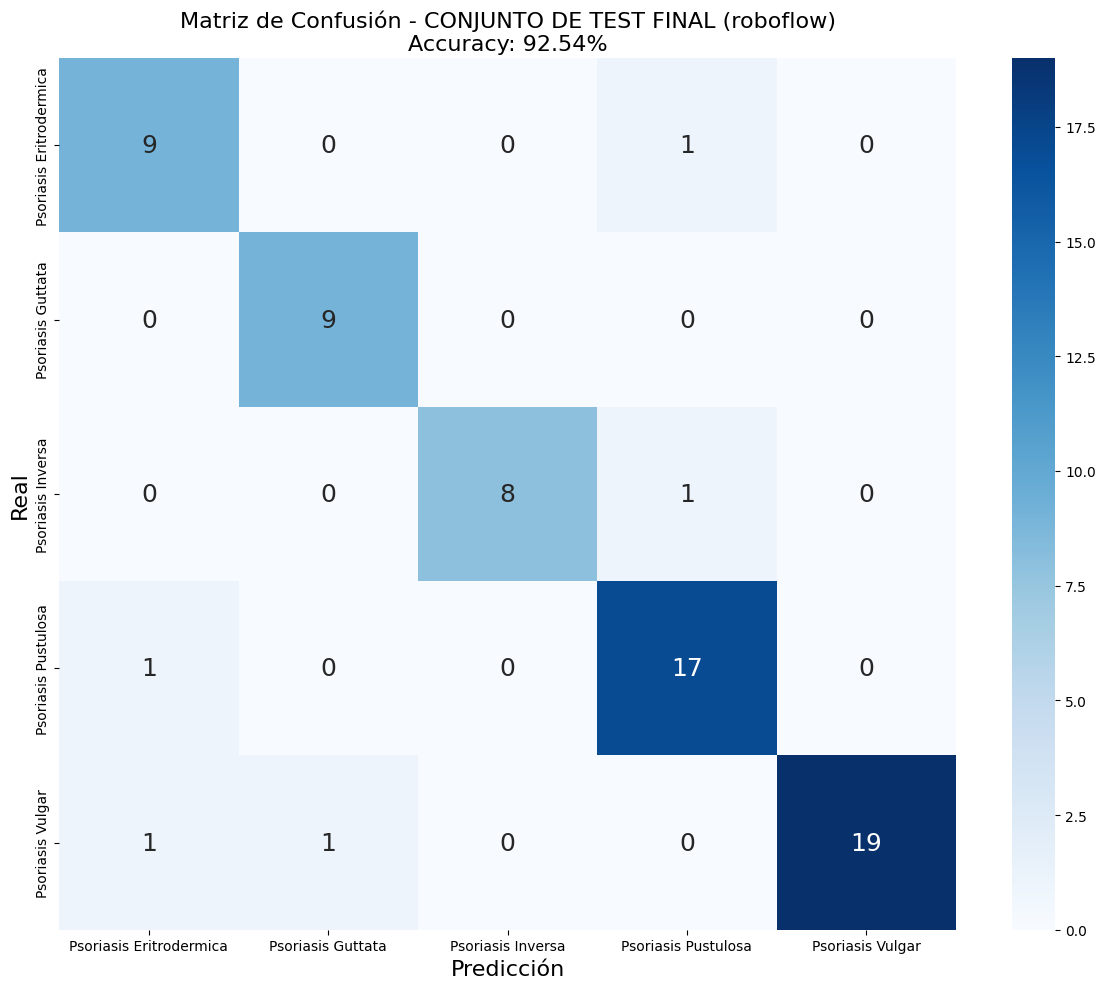


Generando gráfico de curvas de entrenamiento para el modelo final...


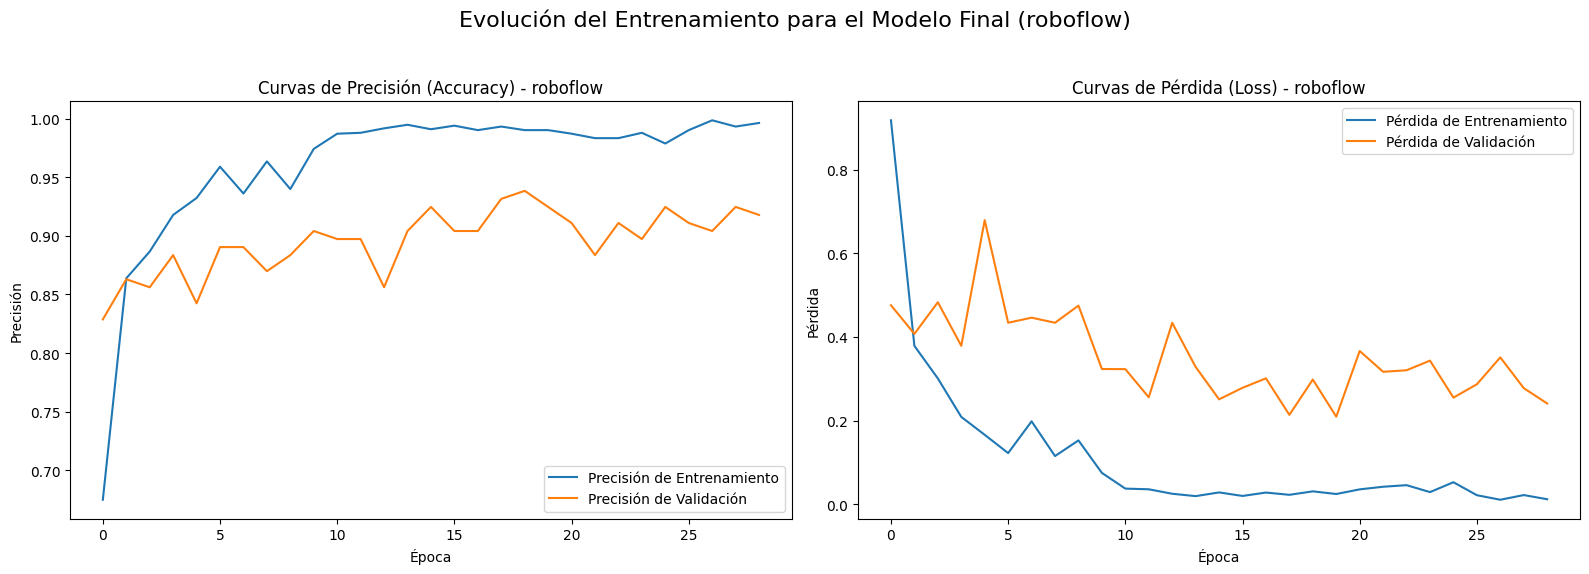


--- PROCESO COMPLETO FINALIZADO ---


In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# ==============================================================================
# INSTRUCCIONES:
# 1. PEGA AQUÍ LAS RUTAS DE LAS IMÁGENES QUE ENCONTRASTE CON TU SCRIPT ANTERIOR.
# 2. ASEGÚRATE DE QUE LAS RUTAS SON CORRECTAS Y LAS IMÁGENES EXISTEN.
# 3. EJECUTA EL SCRIPT.
# ==============================================================================

# --- DATOS DE ENTRADA CON RUTAS DE EJEMPLO ---
# Reemplaza estas rutas con las que obtuviste de tu sistema.
image_paths = {
    "roboflow": {
        "Psoriasis Vulgar": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Vulgar/1-plaque-psoriasis-symptoms-6_jpg.rf.d231945a0505872111eb9ab798836512.jpg",
        "Psoriasis Guttata": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Guttata/d15197824707833075_jpg.rf.48a07f0f62261771ed4f669048a1d13f.jpg",
        "Psoriasis Inversa": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Inversa/intertriginous-psoriasis-symptoms-14_jpg.rf.52358b688d01d4a03423b04c35e3b5e4.jpg",
        "Psoriasis Pustulosa": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Pustulosa/images-12_jpg.rf.9b6f8497d394b9175d27d2c38d386407.jpg",
        "Psoriasis Eritrodermica": "/kaggle/input/roboflow-universe-dataset/Roboflow Universe/Psoriasis Eritrodermica/Erythrodermic-Psoriasis-Symptoms_jpg.rf.231c5182103328e7529f7983637651a1.jpg",
    },
    "dermnet": {
        "Psoriasis Vulgar": "/kaggle/input/dermnet/DermNet/Psoriasis Vulgar/psoriasis-13_orig_2.jpg",
        "Psoriasis Guttata": "/kaggle/input/dermnet/DermNet/Psoriasis Guttata/psoriasis-guttate-2.jpg",
        "Psoriasis Inversa": "/kaggle/input/dermnet/DermNet/Psoriasis Inversa/inverse-psoriasis-1_orig.jpg",
        "Psoriasis Pustulosa": "/kaggle/input/dermnet/DermNet/Psoriasis Pustulosa/pustular-psoriasis-16.jpg",
        "Psoriasis Eritrodermica": "/kaggle/input/dermnet/DermNet/Psoriasis Eritrodermica/psoriasis-erythrodermic-1.jpg",
    },
    "hospital": {
        "Psoriasis Vulgar": "/kaggle/input/imageneshospital/Hospital/Hospital/Psoriasis Vulgar/psoriasis-vulgar.jpg",
        "Psoriasis Guttata": "/kaggle/input/imageneshospital/Hospital/Hospital/Psoriasis Guttata/guttata.jpg",
        "Psoriasis Inversa": "/kaggle/input/imageneshospital/Hospital/Hospital/Psoriasis Inversa/inversa.jpg",
        "Psoriasis Pustulosa": "/kaggle/input/imageneshospital/Hospital/Hospital/Psoriasis Pustulosa/pustulosa.jpg",
        "Psoriasis Eritrodermica": "/kaggle/input/imageneshospital/Hospital/Hospital/Psoriasis Eritrodermica/eritrodermica.jpg",
    }
}

# --- PARÁMETROS DE CONFIGURACIÓN ---
OUTPUT_DIR = "/kaggle/working/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
IMG_SIZE = (300, 300) # Tamaño de cada sub-imagen
DPI = 300 # Puntos por pulgada para alta calidad
plt.style.use('seaborn-v0_8-whitegrid')

# --- FUNCIÓN PARA CREAR, GUARDAR Y MOSTRAR CADA FIGURA ---
def create_and_save_figure_by_dataset(data_paths, output_dir, img_size, dpi):
    for source, class_images in data_paths.items():
        if not class_images:
            print(f"No hay imágenes para el dataset '{source}'. Saltando.")
            continue
            
        class_names = list(class_images.keys())
        
        # Crear la figura con 2 filas y 3 columnas
        fig, axes = plt.subplots(2, 3, figsize=(9, 6))
        fig.suptitle(f'Ejemplos de {source.upper()}', fontsize=16, weight='bold')
        
        # Aplanar el array de axes para iterar fácilmente
        ax_flat = axes.flatten()
        
        for i, class_name in enumerate(class_names):
            ax = ax_flat[i]
            img_path = class_images.get(class_name)
            
            if img_path and os.path.exists(img_path):
                try:
                    img = Image.open(img_path).convert("RGB").resize(img_size, Image.Resampling.LANCZOS)
                    ax.imshow(img)
                except Exception as e:
                    print(f"Error al cargar la imagen {img_path}: {e}")
                    ax.text(0.5, 0.5, 'Error de carga', ha='center', va='center', color='red')
            else:
                ax.text(0.5, 0.5, 'Imagen no encontrada', ha='center', va='center', color='red')
            
            ax.set_title(class_name.split(' ')[1].upper(), fontsize=10, weight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
        
        # Ocultar el último subplot, que no se utiliza
        ax_flat[-1].axis('off')
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        
        output_filename = os.path.join(output_dir, f"{source}_psoriasis_examples.png")
        plt.savefig(output_filename, dpi=dpi, bbox_inches='tight')
        print(f"\nFigura para '{source}' guardada en alta resolución en: {output_filename}")
        plt.show() # Muestra la figura en pantalla
        
        plt.close(fig)

# --- EJECUCIÓN DEL SCRIPT ---
if __name__ == "__main__":
    create_and_save_figure_by_dataset(image_paths, OUTPUT_DIR, IMG_SIZE, DPI)

## Roboflow 

2025-08-27 16:50:14.687265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756313414.859356      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756313414.910086      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Datos cargados para 'roboflow':
  - 378 imágenes para K-Fold (85%)
  - 67 imágenes para Test Final (15%)
Clases detectadas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====

--- INICIANDO FOLD 1/5 ---
Cargando imágenes del fold en memoria...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 93 imágenes. Objetivo por clase: 232
Generando 186 imágenes para la clase Psoriasis Eritrodermica...
Generando 193 imágenes para la clase Psoriasis Guttata...
Generando 189 imágenes para la clase Psoriasis Inversa...
Generando 151 imágenes para la clase Psoriasis Pustulosa...
Generando 139 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.


I0000 00:00:1756313438.829714      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756313438.830400      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Entrenando fold 1 con 1160 imágenes de entrenamiento...
Epoch 1/100


I0000 00:00:1756313461.067347      99 service.cc:148] XLA service 0x7f8208055f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756313461.068292      99 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756313461.068319      99 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756313462.763326      99 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756313472.130120      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


145/145 - 41s - 284ms/step - accuracy: 0.6422 - loss: 0.9860 - val_accuracy: 0.7237 - val_loss: 0.7462 - learning_rate: 0.0010
Epoch 2/100
145/145 - 2s - 14ms/step - accuracy: 0.8578 - loss: 0.4282 - val_accuracy: 0.8289 - val_loss: 0.6714 - learning_rate: 0.0010
Epoch 3/100
145/145 - 2s - 12ms/step - accuracy: 0.9155 - loss: 0.2355 - val_accuracy: 0.8158 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 4/100
145/145 - 2s - 13ms/step - accuracy: 0.9362 - loss: 0.1794 - val_accuracy: 0.8684 - val_loss: 0.7823 - learning_rate: 0.0010
Epoch 5/100
145/145 - 2s - 13ms/step - accuracy: 0.9552 - loss: 0.1301 - val_accuracy: 0.8289 - val_loss: 0.9067 - learning_rate: 0.0010
Epoch 6/100
145/145 - 2s - 12ms/step - accuracy: 0.9483 - loss: 0.1481 - val_accuracy: 0.8684 - val_loss: 0.9470 - learning_rate: 0.0010
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
145/145 - 2s - 12ms/step - accuracy: 0.9672 - loss: 0.1099 - val_accuracy: 0.8421 - val_loss: 0.810

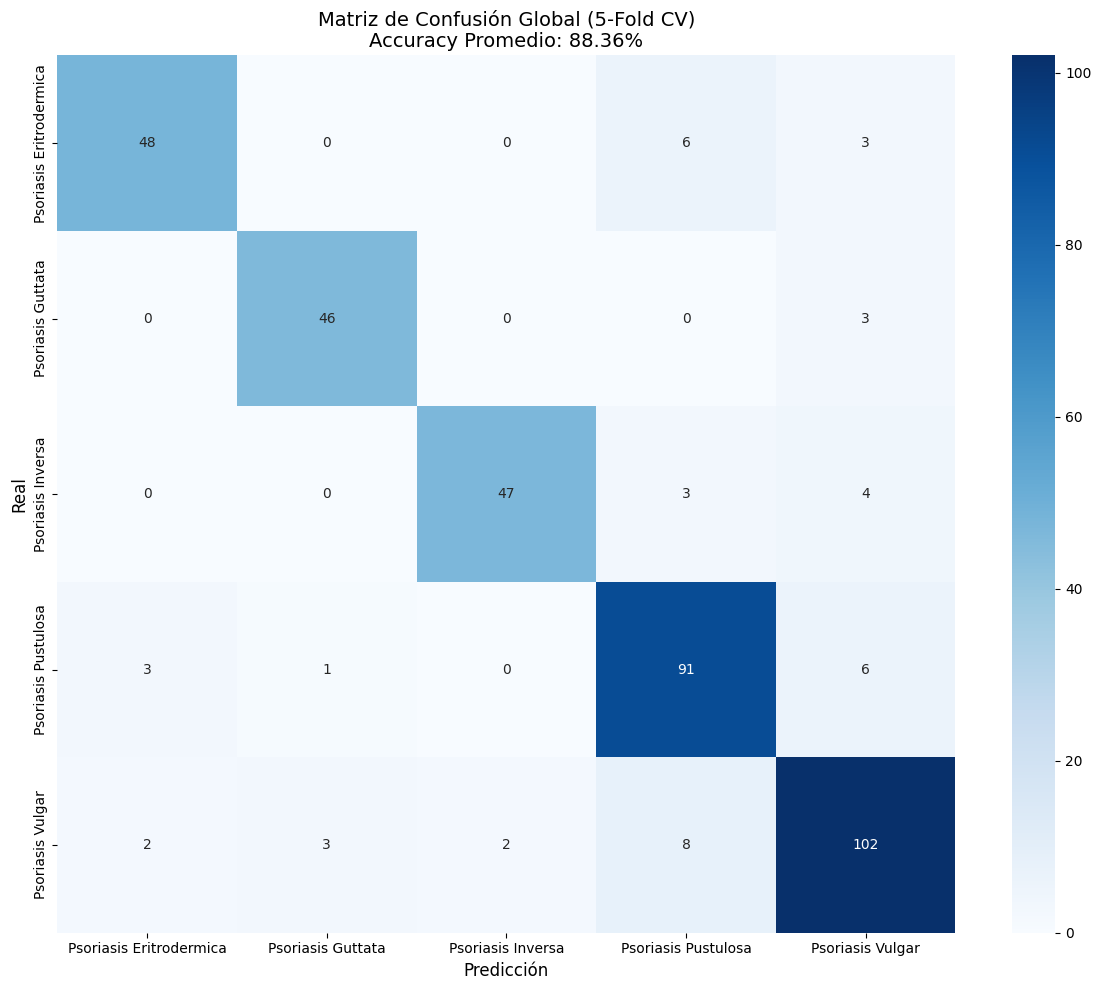


===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====
Cargando el dataset completo de train/val para el modelo final...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 117 imágenes. Objetivo por clase: 292
Generando 235 imágenes para la clase Psoriasis Eritrodermica...
Generando 243 imágenes para la clase Psoriasis Guttata...
Generando 238 imágenes para la clase Psoriasis Inversa...
Generando 191 imágenes para la clase Psoriasis Pustulosa...
Generando 175 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando modelo final con 1460 imágenes...
Epoch 1/100
165/165 - 47s - 285ms/step - accuracy: 0.6895 - loss: 0.8909 - val_accuracy: 0.8356 - val_loss: 0.4248 - learning_rate: 0.0010
Epoch 2/100
165/165 - 3s - 17ms/step - accuracy: 0.8592 - loss: 0.4039 - val_accuracy: 0.8562 - val_loss: 0.3516 - learning_rate: 0.0010
Epoch 3/100
165/165 - 3s - 16ms/step - accuracy: 0.9132 - loss: 0.2649 - val_accuracy: 0.8767 - val

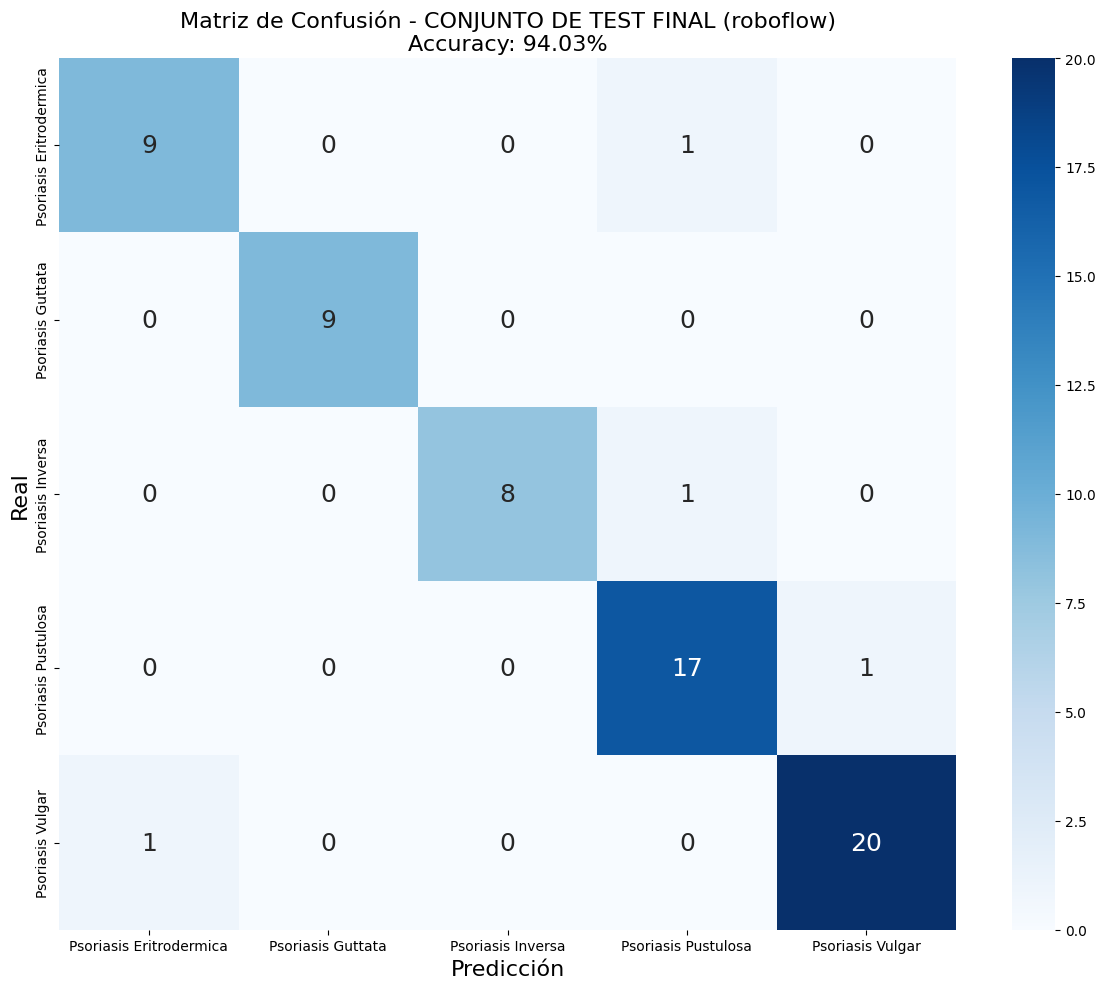


--- PROCESO COMPLETO FINALIZADO ---


In [2]:
# ==============================================================================
# SCRIPT COMPLETO DE ENTRENAMIENTO Y EVALUACIÓN - METODOLOGÍA TFG FINAL
# ==============================================================================
# Este script implementa el protocolo de evaluación de dos niveles:
# 1. Validación Cruzada K-Fold (K=5) sobre el 85% de los datos.
# 2. Entrenamiento de un Modelo Final y Evaluación sobre el 15% de test reservado.
#
# Se asume que el script de preparación con el split 85/15 ya ha sido ejecutado.
# ------------------------------------------------------------------------------

import os
import gc
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter

# Importaciones específicas de la metodología del TFG
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###

# ------------------------------------------------------------------------------
# MODIFICA ESTA VARIABLE PARA CAMBIAR DE EXPERIMENTO
# Opciones: "roboflow", "dermnet", "roboflow_dermnet"
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "roboflow"

# --- Rutas y Configuración General ---
BASE_PATH = "/kaggle/working/datasets_csv_85_15_caseib/splits"
OUTPUT_DIR = f"/kaggle/working/results_{EXPERIMENT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 44
tf.random.set_seed(SEED)
np.random.seed(SEED)

# --- Configuración K-Fold (Sección 3.6 del TFG) ---
N_SPLITS = 5

# --- Configuración del Modelo y Entrenamiento (Secciones 3.3, 3.4, 3.5 del TFG) ---
MODEL_CHOICE = EfficientNetB0
IMG_SIZE = 224 # Tamaño para EfficientNetB0
BATCH_SIZE = 8
EPOCHS = 100 # Un número alto, EarlyStopping decidirá cuándo parar
OVERSAMPLE_FACTOR = 2.5 # Factor de sobremuestreo descrito en el TFG

### --- 2. CARGA DE DATOS --- ###

# Rutas a los nuevos archivos 85/15
train_val_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_train_val_85.csv")
test_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_test_15.csv")

try:
    df_train_val = pd.read_csv(train_val_csv_path)
    df_test = pd.read_csv(test_csv_path)
    print(f"Datos cargados para '{EXPERIMENT_NAME}':")
    print(f"  - {len(df_train_val)} imágenes para K-Fold (85%)")
    print(f"  - {len(df_test)} imágenes para Test Final (15%)")
except FileNotFoundError as e:
    print(f"ERROR: No se encontró el archivo CSV: {e}. Asegúrate de ejecutar la Celda de Preparación primero.")
    raise e

# Mapeo de etiquetas a enteros
class_names = sorted(df_train_val['label_reassigned'].unique())
label_to_int = {label: i for i, label in enumerate(class_names)}
NUM_CLASSES = len(class_names)
df_train_val['label_int'] = df_train_val['label_reassigned'].map(label_to_int)
df_test['label_int'] = df_test['label_reassigned'].map(label_to_int)
print(f"Clases detectadas ({NUM_CLASSES}): {class_names}")


### --- 3. FUNCIONES AUXILIARES (Implementación de la Metodología) --- ###

def load_images_from_df(df):
    """Carga un conjunto de imágenes desde un dataframe a un array de NumPy."""
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(row['label_int'])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
            
    if not images:
        return np.array([]), np.array([])
        
    # Aplicar preprocesamiento de EfficientNet
    images_preprocessed = efficientnet_preprocess(np.array(images))
    return images_preprocessed, tf.keras.utils.to_categorical(np.array(labels), num_classes=NUM_CLASSES)

def balance_dataset_with_augmentation(X_data, y_data):
    """
    Implementación del balanceo de clases descrito en la Sección 3.2 del TFG.
    Aumenta las clases minoritarias hasta 2.5x el tamaño de la clase mayoritaria.
    """
    print("Iniciando balanceo de clases con aumento de datos...")
    
    # Parámetros de ImageDataGenerator descritos en el TFG
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )
    
    y_integers = np.argmax(y_data, axis=1)
    class_counts = Counter(y_integers)
    max_count = max(class_counts.values()) if class_counts else 0
    target_count = int(max_count * OVERSAMPLE_FACTOR)
    print(f"Clase mayoritaria: {max_count} imágenes. Objetivo por clase: {target_count}")

    X_balanced, y_balanced = list(X_data), list(y_data)
    
    for class_idx in range(NUM_CLASSES):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < target_count:
            needed = target_count - current_count
            print(f"Generando {needed} imágenes para la clase {class_names[class_idx]}...")
            
            images_to_augment = X_data[y_integers == class_idx]
            
            generator_flow = datagen.flow(images_to_augment, batch_size=1, seed=SEED)
            for _ in range(needed):
                X_balanced.append(next(generator_flow)[0])
                y_balanced.append(tf.keras.utils.to_categorical(class_idx, num_classes=NUM_CLASSES))
            
    print("Balanceo completado.")
    # Barajar el dataset final
    indices = np.arange(len(X_balanced))
    np.random.shuffle(indices)
    
    return np.array(X_balanced)[indices], np.array(y_balanced)[indices]

def create_model():
    """
    Crea la arquitectura del modelo descrita en la Sección 3.3 del TFG.
    """
    base_model = MODEL_CHOICE(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Base convolucional congelada

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

### --- 4. NIVEL 1 DE EVALUACIÓN: K-FOLD SOBRE EL 85% DEL DATASET --- ###

print("\n===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====")

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_accuracies = []
all_true_labels_kfold = []
all_pred_labels_kfold = []

for fold, (train_indices, val_indices) in enumerate(kf.split(df_train_val, df_train_val['label_int'])):
    print(f"\n--- INICIANDO FOLD {fold+1}/{N_SPLITS} ---")
    
    df_train_fold = df_train_val.iloc[train_indices]
    df_val_fold = df_train_val.iloc[val_indices]

    print("Cargando imágenes del fold en memoria...")
    X_train_fold, y_train_fold = load_images_from_df(df_train_fold)
    X_val_fold, y_val_fold = load_images_from_df(df_val_fold)
    
    if X_train_fold.size == 0 or X_val_fold.size == 0:
        print("Fold vacío, saltando.")
        continue
    
    X_train_balanced, y_train_balanced = balance_dataset_with_augmentation(X_train_fold, y_train_fold)

    model_fold = create_model()
    model_fold.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    
    print(f"Entrenando fold {fold+1} con {len(X_train_balanced)} imágenes de entrenamiento...")
    model_fold.fit(
        X_train_balanced, y_train_balanced,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=2 # Se pone a 0 para no saturar la salida. Cambiar a 1 o 2 para más detalle.
    )
    
    y_pred_probs = model_fold.predict(X_val_fold)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val_fold, axis=1)
    
    fold_accuracies.append(accuracy_score(y_true, y_pred))
    all_true_labels_kfold.extend(y_true)
    all_pred_labels_kfold.extend(y_pred)
    
    print(f"Accuracy del Fold {fold+1}: {fold_accuracies[-1]:.4f}")
    
    del model_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold, X_train_balanced, y_train_balanced
    tf.keras.backend.clear_session()
    gc.collect()

# --- Resultados Globales de K-Fold ---
print("\n--- RESULTADOS GLOBALES DE K-FOLD CROSS-VALIDATION (sobre el 85% del dataset) ---")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Precisión (Accuracy) Promedio en Folds de Validación: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
report_kfold = classification_report(all_true_labels_kfold, all_pred_labels_kfold, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación Global (K-Fold):\n", report_kfold)

cm_kfold = confusion_matrix(all_true_labels_kfold, all_pred_labels_kfold)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión Global ({N_SPLITS}-Fold CV)\nAccuracy Promedio: {mean_accuracy:.2%}', fontsize=14)
plt.xlabel('Predicción', fontsize=12); plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kfold_global_confusion_matrix.png"))
plt.show()

### --- 5. NIVEL 2 DE EVALUACIÓN: MODELO FINAL Y TEST RESERVADO (15%) --- ###

print("\n===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====")

# 1. Cargar todos los datos de entrenamiento/validación (el 85% completo)
print("Cargando el dataset completo de train/val para el modelo final...")
X_train_full, y_train_full = load_images_from_df(df_train_val)

# 2. Balancear el dataset completo
X_train_full_balanced, y_train_full_balanced = balance_dataset_with_augmentation(X_train_full, y_train_full)

# 3. Crear y compilar el modelo final
final_model = create_model()
final_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para el modelo final
final_model_path = os.path.join(OUTPUT_DIR, "final_model_best.h5")
checkpoint_final = ModelCheckpoint(final_model_path, monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping_final = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 5. Entrenar el modelo final
print(f"Entrenando modelo final con {len(X_train_full_balanced)} imágenes...")
# Usamos validation_split aquí para que los callbacks tengan datos en los que basarse.
final_model.fit(
    X_train_full_balanced, y_train_full_balanced,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1, # 10% de los datos de entrenamiento para validar internamente
    callbacks=[checkpoint_final, early_stopping_final, reduce_lr_final],
    verbose=2
)

# 6. Cargar los datos de test y el mejor modelo guardado
print("\n--- EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST RESERVADO (15%) ---")
X_test, y_test = load_images_from_df(df_test)
best_final_model = tf.keras.models.load_model(final_model_path)

# 7. Evaluar y mostrar resultados finales
loss, accuracy = best_final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nResultados en el Conjunto de Test Final:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

y_pred_probs_test = best_final_model.predict(X_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test, axis=1)

report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación (Test Final):\n", report_test)
with open(os.path.join(OUTPUT_DIR, "final_test_report.txt"), "w") as f:
    f.write(report_test)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
plt.title(f'Matriz de Confusión - CONJUNTO DE TEST FINAL ({EXPERIMENT_NAME})\nAccuracy: {accuracy:.2%}', fontsize=16)
plt.xlabel('Predicción', fontsize=16)
plt.ylabel('Real', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_test_confusion_matrix.png"))
plt.show()

print("\n--- PROCESO COMPLETO FINALIZADO ---")

2025-08-27 18:57:57.792896: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756321077.942863      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756321077.989091      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Datos cargados para 'roboflow_hospital':
  - 408 imágenes para K-Fold (85%)
  - 73 imágenes para Test Final (15%)
Clases detectadas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====

--- INICIANDO FOLD 1/5 ---
Cargando imágenes del fold en memoria...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 114 imágenes. Objetivo por clase: 285
Generando 237 imágenes para la clase Psoriasis Eritrodermica...
Generando 246 imágenes para la clase Psoriasis Guttata...
Generando 243 imágenes para la clase Psoriasis Inversa...
Generando 202 imágenes para la clase Psoriasis Pustulosa...
Generando 171 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.


I0000 00:00:1756321106.674581      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756321106.675355      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenando fold 1 con 1425 imágenes de entrenamiento...
Epoch 1/100


I0000 00:00:1756321130.580233     102 service.cc:148] XLA service 0x7de3840039d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756321130.580985     102 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756321130.581006     102 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756321132.716110     102 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756321143.448038     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


179/179 - 57s - 319ms/step - accuracy: 0.7151 - loss: 0.8147 - val_accuracy: 0.8049 - val_loss: 0.6742 - learning_rate: 0.0010
Epoch 2/100
179/179 - 3s - 14ms/step - accuracy: 0.8667 - loss: 0.3916 - val_accuracy: 0.7927 - val_loss: 0.8181 - learning_rate: 0.0010
Epoch 3/100
179/179 - 3s - 15ms/step - accuracy: 0.9235 - loss: 0.2202 - val_accuracy: 0.8415 - val_loss: 0.9168 - learning_rate: 0.0010
Epoch 4/100
179/179 - 2s - 14ms/step - accuracy: 0.9404 - loss: 0.1658 - val_accuracy: 0.8171 - val_loss: 1.0103 - learning_rate: 0.0010
Epoch 5/100
179/179 - 3s - 14ms/step - accuracy: 0.9502 - loss: 0.1260 - val_accuracy: 0.8293 - val_loss: 0.9163 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
179/179 - 2s - 14ms/step - accuracy: 0.9530 - loss: 0.1254 - val_accuracy: 0.8293 - val_loss: 0.9040 - learning_rate: 0.0010
Epoch 7/100
179/179 - 2s - 14ms/step - accuracy: 0.9789 - loss: 0.0660 - val_accuracy: 0.8415 - val_loss: 0.831

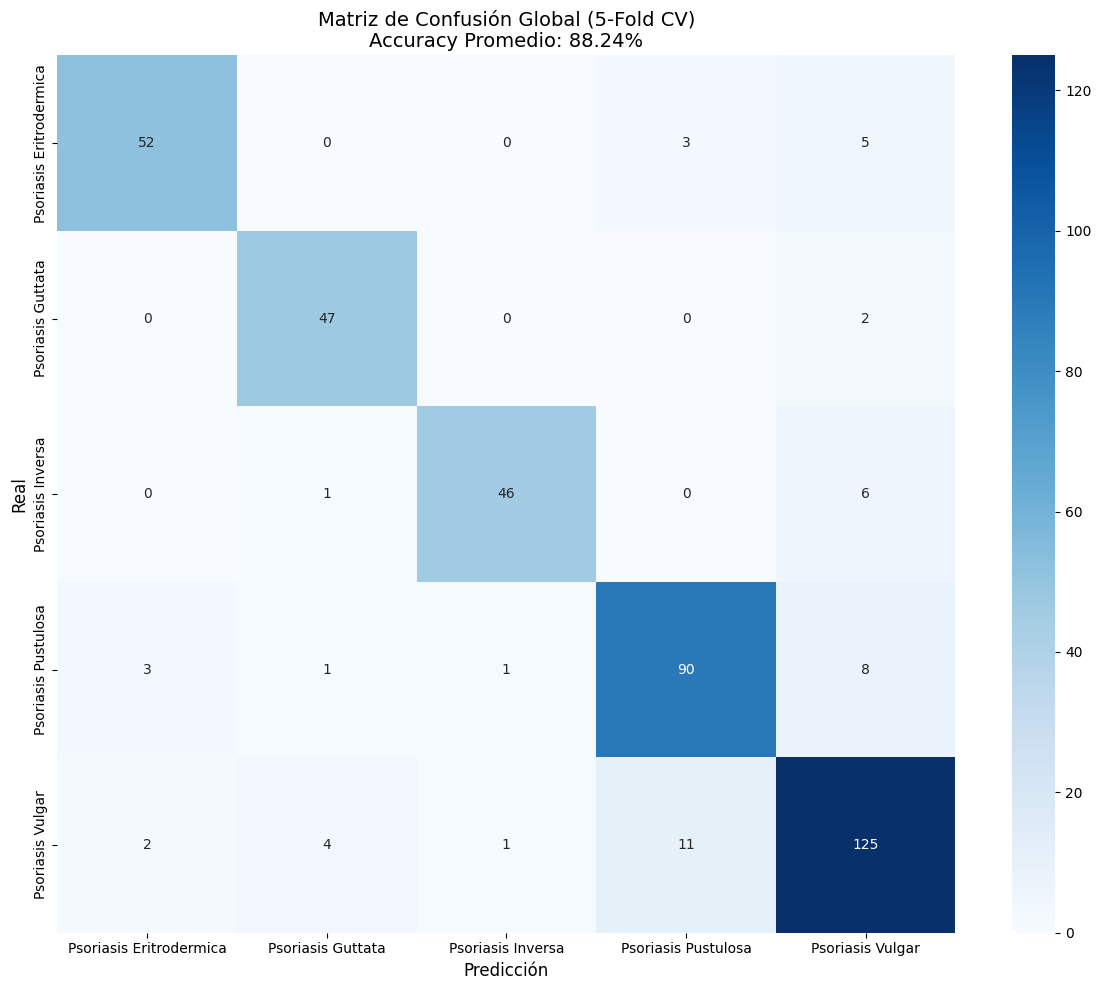


===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====
Cargando el dataset completo de train/val para el modelo final...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 143 imágenes. Objetivo por clase: 357
Generando 297 imágenes para la clase Psoriasis Eritrodermica...
Generando 308 imágenes para la clase Psoriasis Guttata...
Generando 304 imágenes para la clase Psoriasis Inversa...
Generando 254 imágenes para la clase Psoriasis Pustulosa...
Generando 214 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando modelo final con 1785 imágenes...
Epoch 1/100
201/201 - 56s - 280ms/step - accuracy: 0.7179 - loss: 0.8346 - val_accuracy: 0.8492 - val_loss: 0.4187 - learning_rate: 0.0010
Epoch 2/100
201/201 - 4s - 18ms/step - accuracy: 0.8574 - loss: 0.4071 - val_accuracy: 0.9162 - val_loss: 0.2810 - learning_rate: 0.0010
Epoch 3/100
201/201 - 3s - 15ms/step - accuracy: 0.9016 - loss: 0.2888 - val_accuracy: 0.8939 - val

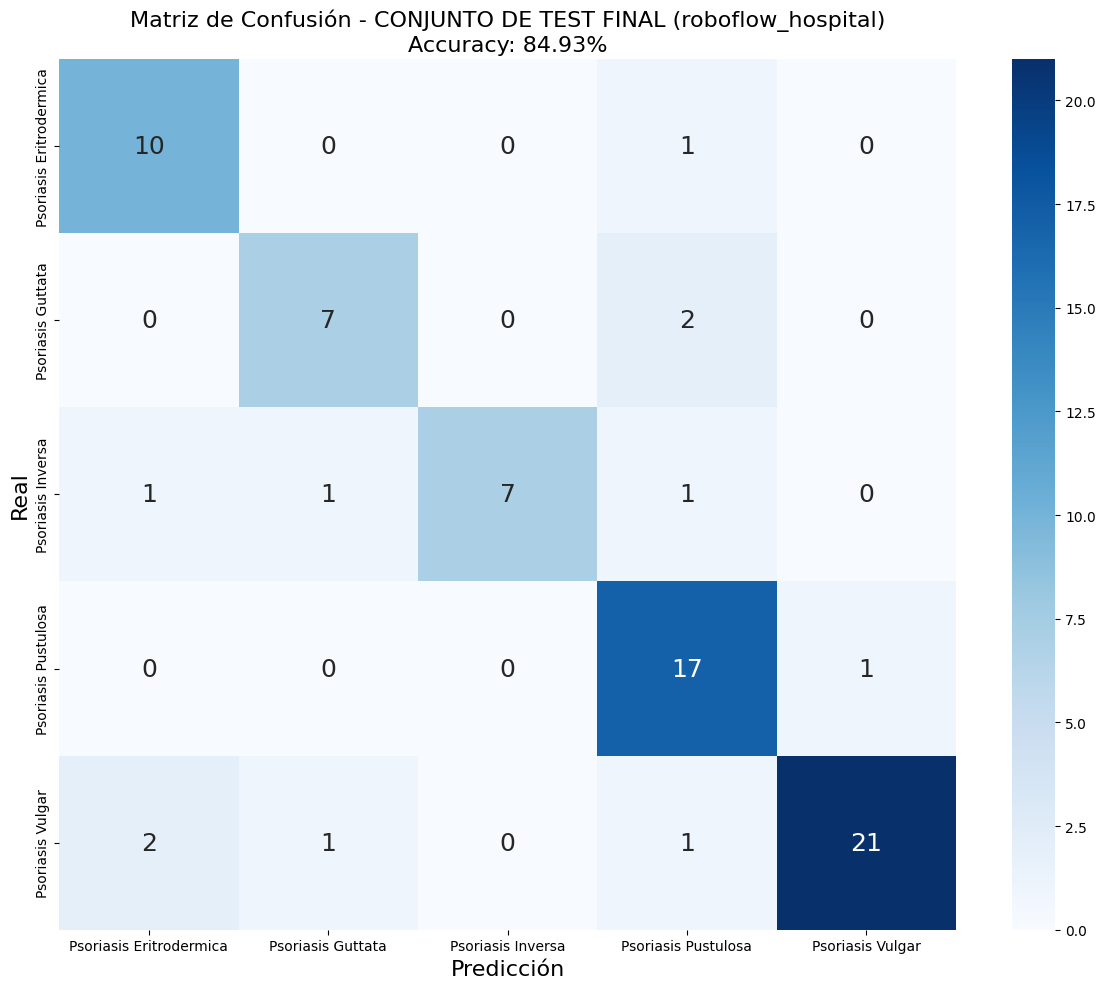


--- PROCESO COMPLETO FINALIZADO ---


In [2]:
# ==============================================================================
# SCRIPT COMPLETO DE ENTRENAMIENTO Y EVALUACIÓN - METODOLOGÍA TFG FINAL
# ==============================================================================
# Este script implementa el protocolo de evaluación de dos niveles:
# 1. Validación Cruzada K-Fold (K=5) sobre el 85% de los datos.
# 2. Entrenamiento de un Modelo Final y Evaluación sobre el 15% de test reservado.
#
# Se asume que el script de preparación con el split 85/15 ya ha sido ejecutado.
# ------------------------------------------------------------------------------

import os
import gc
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter

# Importaciones específicas de la metodología del TFG
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###

# ------------------------------------------------------------------------------
# MODIFICA ESTA VARIABLE PARA CAMBIAR DE EXPERIMENTO
# Opciones: "roboflow", "dermnet", "roboflow_dermnet"
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "roboflow_hospital"

# --- Rutas y Configuración General ---
BASE_PATH = "/kaggle/working/datasets_csv_85_15_caseib/splits"
OUTPUT_DIR = f"/kaggle/working/results_{EXPERIMENT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 44
tf.random.set_seed(SEED)
np.random.seed(SEED)

# --- Configuración K-Fold (Sección 3.6 del TFG) ---
N_SPLITS = 5

# --- Configuración del Modelo y Entrenamiento (Secciones 3.3, 3.4, 3.5 del TFG) ---
MODEL_CHOICE = EfficientNetB0
IMG_SIZE = 224 # Tamaño para EfficientNetB0
BATCH_SIZE = 8
EPOCHS = 100 # Un número alto, EarlyStopping decidirá cuándo parar
OVERSAMPLE_FACTOR = 2.5 # Factor de sobremuestreo descrito en el TFG

### --- 2. CARGA DE DATOS --- ###

# Rutas a los nuevos archivos 85/15
train_val_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_train_val_85.csv")
test_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_test_15.csv")

try:
    df_train_val = pd.read_csv(train_val_csv_path)
    df_test = pd.read_csv(test_csv_path)
    print(f"Datos cargados para '{EXPERIMENT_NAME}':")
    print(f"  - {len(df_train_val)} imágenes para K-Fold (85%)")
    print(f"  - {len(df_test)} imágenes para Test Final (15%)")
except FileNotFoundError as e:
    print(f"ERROR: No se encontró el archivo CSV: {e}. Asegúrate de ejecutar la Celda de Preparación primero.")
    raise e

# Mapeo de etiquetas a enteros
class_names = sorted(df_train_val['label_reassigned'].unique())
label_to_int = {label: i for i, label in enumerate(class_names)}
NUM_CLASSES = len(class_names)
df_train_val['label_int'] = df_train_val['label_reassigned'].map(label_to_int)
df_test['label_int'] = df_test['label_reassigned'].map(label_to_int)
print(f"Clases detectadas ({NUM_CLASSES}): {class_names}")


### --- 3. FUNCIONES AUXILIARES (Implementación de la Metodología) --- ###

def load_images_from_df(df):
    """Carga un conjunto de imágenes desde un dataframe a un array de NumPy."""
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(row['label_int'])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
            
    if not images:
        return np.array([]), np.array([])
        
    # Aplicar preprocesamiento de EfficientNet
    images_preprocessed = efficientnet_preprocess(np.array(images))
    return images_preprocessed, tf.keras.utils.to_categorical(np.array(labels), num_classes=NUM_CLASSES)

def balance_dataset_with_augmentation(X_data, y_data):
    """
    Implementación del balanceo de clases descrito en la Sección 3.2 del TFG.
    Aumenta las clases minoritarias hasta 2.5x el tamaño de la clase mayoritaria.
    """
    print("Iniciando balanceo de clases con aumento de datos...")
    
    # Parámetros de ImageDataGenerator descritos en el TFG
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )
    
    y_integers = np.argmax(y_data, axis=1)
    class_counts = Counter(y_integers)
    max_count = max(class_counts.values()) if class_counts else 0
    target_count = int(max_count * OVERSAMPLE_FACTOR)
    print(f"Clase mayoritaria: {max_count} imágenes. Objetivo por clase: {target_count}")

    X_balanced, y_balanced = list(X_data), list(y_data)
    
    for class_idx in range(NUM_CLASSES):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < target_count:
            needed = target_count - current_count
            print(f"Generando {needed} imágenes para la clase {class_names[class_idx]}...")
            
            images_to_augment = X_data[y_integers == class_idx]
            
            generator_flow = datagen.flow(images_to_augment, batch_size=1, seed=SEED)
            for _ in range(needed):
                X_balanced.append(next(generator_flow)[0])
                y_balanced.append(tf.keras.utils.to_categorical(class_idx, num_classes=NUM_CLASSES))
            
    print("Balanceo completado.")
    # Barajar el dataset final
    indices = np.arange(len(X_balanced))
    np.random.shuffle(indices)
    
    return np.array(X_balanced)[indices], np.array(y_balanced)[indices]

def create_model():
    """
    Crea la arquitectura del modelo descrita en la Sección 3.3 del TFG.
    """
    base_model = MODEL_CHOICE(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Base convolucional congelada

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

### --- 4. NIVEL 1 DE EVALUACIÓN: K-FOLD SOBRE EL 85% DEL DATASET --- ###

print("\n===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====")

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_accuracies = []
all_true_labels_kfold = []
all_pred_labels_kfold = []

for fold, (train_indices, val_indices) in enumerate(kf.split(df_train_val, df_train_val['label_int'])):
    print(f"\n--- INICIANDO FOLD {fold+1}/{N_SPLITS} ---")
    
    df_train_fold = df_train_val.iloc[train_indices]
    df_val_fold = df_train_val.iloc[val_indices]

    print("Cargando imágenes del fold en memoria...")
    X_train_fold, y_train_fold = load_images_from_df(df_train_fold)
    X_val_fold, y_val_fold = load_images_from_df(df_val_fold)
    
    if X_train_fold.size == 0 or X_val_fold.size == 0:
        print("Fold vacío, saltando.")
        continue
    
    X_train_balanced, y_train_balanced = balance_dataset_with_augmentation(X_train_fold, y_train_fold)

    model_fold = create_model()
    model_fold.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    
    print(f"Entrenando fold {fold+1} con {len(X_train_balanced)} imágenes de entrenamiento...")
    model_fold.fit(
        X_train_balanced, y_train_balanced,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=2 # Se pone a 0 para no saturar la salida. Cambiar a 1 o 2 para más detalle.
    )
    
    y_pred_probs = model_fold.predict(X_val_fold)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val_fold, axis=1)
    
    fold_accuracies.append(accuracy_score(y_true, y_pred))
    all_true_labels_kfold.extend(y_true)
    all_pred_labels_kfold.extend(y_pred)
    
    print(f"Accuracy del Fold {fold+1}: {fold_accuracies[-1]:.4f}")
    
    del model_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold, X_train_balanced, y_train_balanced
    tf.keras.backend.clear_session()
    gc.collect()

# --- Resultados Globales de K-Fold ---
print("\n--- RESULTADOS GLOBALES DE K-FOLD CROSS-VALIDATION (sobre el 85% del dataset) ---")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Precisión (Accuracy) Promedio en Folds de Validación: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
report_kfold = classification_report(all_true_labels_kfold, all_pred_labels_kfold, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación Global (K-Fold):\n", report_kfold)

cm_kfold = confusion_matrix(all_true_labels_kfold, all_pred_labels_kfold)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión Global ({N_SPLITS}-Fold CV)\nAccuracy Promedio: {mean_accuracy:.2%}', fontsize=14)
plt.xlabel('Predicción', fontsize=12); plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kfold_global_confusion_matrix.png"))
plt.show()

### --- 5. NIVEL 2 DE EVALUACIÓN: MODELO FINAL Y TEST RESERVADO (15%) --- ###

print("\n===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====")

# 1. Cargar todos los datos de entrenamiento/validación (el 85% completo)
print("Cargando el dataset completo de train/val para el modelo final...")
X_train_full, y_train_full = load_images_from_df(df_train_val)

# 2. Balancear el dataset completo
X_train_full_balanced, y_train_full_balanced = balance_dataset_with_augmentation(X_train_full, y_train_full)

# 3. Crear y compilar el modelo final
final_model = create_model()
final_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para el modelo final
final_model_path = os.path.join(OUTPUT_DIR, "final_model_best.h5")
checkpoint_final = ModelCheckpoint(final_model_path, monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping_final = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 5. Entrenar el modelo final
print(f"Entrenando modelo final con {len(X_train_full_balanced)} imágenes...")
# Usamos validation_split aquí para que los callbacks tengan datos en los que basarse.
final_model.fit(
    X_train_full_balanced, y_train_full_balanced,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1, # 10% de los datos de entrenamiento para validar internamente
    callbacks=[checkpoint_final, early_stopping_final, reduce_lr_final],
    verbose=2
)

# 6. Cargar los datos de test y el mejor modelo guardado
print("\n--- EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST RESERVADO (15%) ---")
X_test, y_test = load_images_from_df(df_test)
best_final_model = tf.keras.models.load_model(final_model_path)

# 7. Evaluar y mostrar resultados finales
loss, accuracy = best_final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nResultados en el Conjunto de Test Final:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

y_pred_probs_test = best_final_model.predict(X_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test, axis=1)

report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación (Test Final):\n", report_test)
with open(os.path.join(OUTPUT_DIR, "final_test_report.txt"), "w") as f:
    f.write(report_test)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
plt.title(f'Matriz de Confusión - CONJUNTO DE TEST FINAL ({EXPERIMENT_NAME})\nAccuracy: {accuracy:.2%}', fontsize=16)
plt.xlabel('Predicción', fontsize=16)
plt.ylabel('Real', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_test_confusion_matrix.png"))
plt.show()

print("\n--- PROCESO COMPLETO FINALIZADO ---")

## Dermnet 

Datos cargados para 'dermnet':
  - 421 imágenes para K-Fold (85%)
  - 75 imágenes para Test Final (15%)
Clases detectadas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====

--- INICIANDO FOLD 1/5 ---
Cargando imágenes del fold en memoria...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 106 imágenes. Objetivo por clase: 265
Generando 236 imágenes para la clase Psoriasis Eritrodermica...
Generando 192 imágenes para la clase Psoriasis Guttata...
Generando 214 imágenes para la clase Psoriasis Inversa...
Generando 159 imágenes para la clase Psoriasis Pustulosa...
Generando 188 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando fold 1 con 1325 imágenes de entrenamiento...
Epoch 1/100
166/166 - 47s - 283ms/step - accuracy: 0.6755 - loss: 0.9307 - val_accuracy: 0.7647 - val_loss: 0.6895 - learning_rate

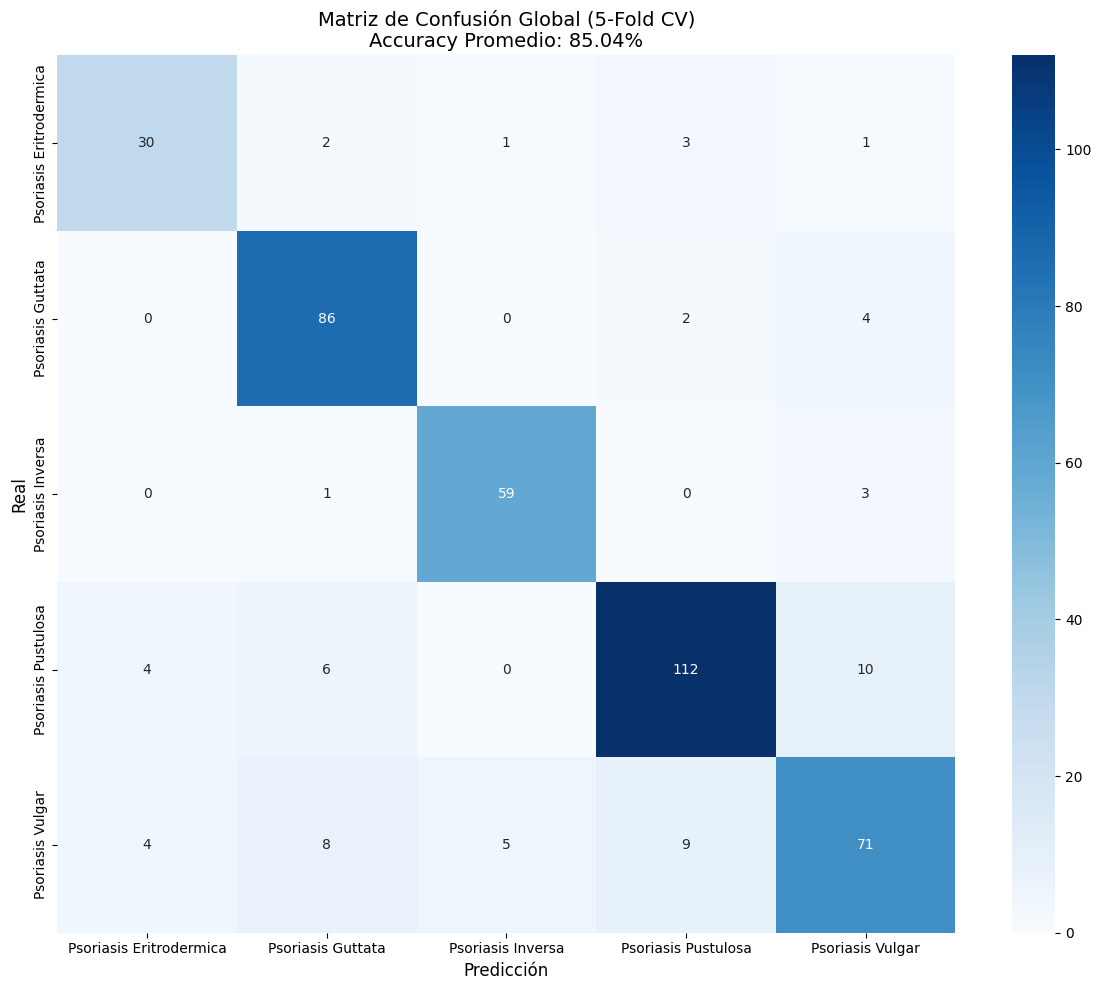


===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====
Cargando el dataset completo de train/val para el modelo final...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 132 imágenes. Objetivo por clase: 330
Generando 293 imágenes para la clase Psoriasis Eritrodermica...
Generando 238 imágenes para la clase Psoriasis Guttata...
Generando 267 imágenes para la clase Psoriasis Inversa...
Generando 198 imágenes para la clase Psoriasis Pustulosa...
Generando 233 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando modelo final con 1650 imágenes...
Epoch 1/100
186/186 - 46s - 247ms/step - accuracy: 0.6734 - loss: 0.9801 - val_accuracy: 0.8788 - val_loss: 0.3960 - learning_rate: 0.0010
Epoch 2/100
186/186 - 3s - 17ms/step - accuracy: 0.8175 - loss: 0.5555 - val_accuracy: 0.8848 - val_loss: 0.3065 - learning_rate: 0.0010
Epoch 3/100
186/186 - 3s - 17ms/step - accuracy: 0.8714 - loss: 0.3739 - val_accuracy: 0.8970 - val

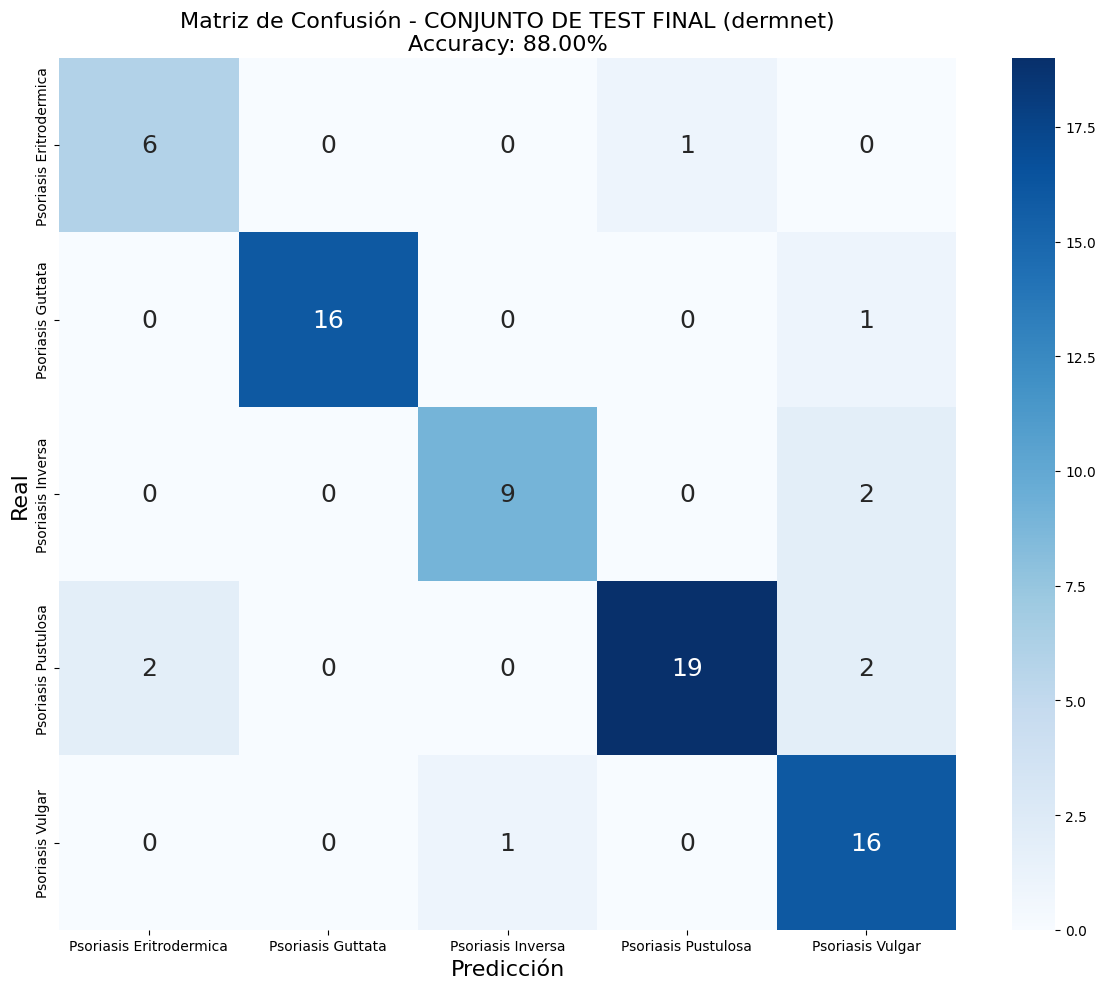


--- PROCESO COMPLETO FINALIZADO ---


In [5]:
# ==============================================================================
# SCRIPT COMPLETO DE ENTRENAMIENTO Y EVALUACIÓN - METODOLOGÍA TFG FINAL
# ==============================================================================
# Este script implementa el protocolo de evaluación de dos niveles:
# 1. Validación Cruzada K-Fold (K=5) sobre el 85% de los datos.
# 2. Entrenamiento de un Modelo Final y Evaluación sobre el 15% de test reservado.
#
# Se asume que el script de preparación con el split 85/15 ya ha sido ejecutado.
# ------------------------------------------------------------------------------

import os
import gc
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter

# Importaciones específicas de la metodología del TFG
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###

# ------------------------------------------------------------------------------
# MODIFICA ESTA VARIABLE PARA CAMBIAR DE EXPERIMENTO
# Opciones: "roboflow", "dermnet", "roboflow_dermnet"
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "dermnet"

# --- Rutas y Configuración General ---
BASE_PATH = "/kaggle/working/datasets_csv_85_15_caseib/splits"
OUTPUT_DIR = f"/kaggle/working/results_{EXPERIMENT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 44
tf.random.set_seed(SEED)
np.random.seed(SEED)

# --- Configuración K-Fold (Sección 3.6 del TFG) ---
N_SPLITS = 5

# --- Configuración del Modelo y Entrenamiento (Secciones 3.3, 3.4, 3.5 del TFG) ---
MODEL_CHOICE = EfficientNetB0
IMG_SIZE = 224 # Tamaño para EfficientNetB0
BATCH_SIZE = 8
EPOCHS = 100 # Un número alto, EarlyStopping decidirá cuándo parar
OVERSAMPLE_FACTOR = 2.5 # Factor de sobremuestreo descrito en el TFG

### --- 2. CARGA DE DATOS --- ###

# Rutas a los nuevos archivos 85/15
train_val_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_train_val_85.csv")
test_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_test_15.csv")

try:
    df_train_val = pd.read_csv(train_val_csv_path)
    df_test = pd.read_csv(test_csv_path)
    print(f"Datos cargados para '{EXPERIMENT_NAME}':")
    print(f"  - {len(df_train_val)} imágenes para K-Fold (85%)")
    print(f"  - {len(df_test)} imágenes para Test Final (15%)")
except FileNotFoundError as e:
    print(f"ERROR: No se encontró el archivo CSV: {e}. Asegúrate de ejecutar la Celda de Preparación primero.")
    raise e

# Mapeo de etiquetas a enteros
class_names = sorted(df_train_val['label_reassigned'].unique())
label_to_int = {label: i for i, label in enumerate(class_names)}
NUM_CLASSES = len(class_names)
df_train_val['label_int'] = df_train_val['label_reassigned'].map(label_to_int)
df_test['label_int'] = df_test['label_reassigned'].map(label_to_int)
print(f"Clases detectadas ({NUM_CLASSES}): {class_names}")


### --- 3. FUNCIONES AUXILIARES (Implementación de la Metodología) --- ###

def load_images_from_df(df):
    """Carga un conjunto de imágenes desde un dataframe a un array de NumPy."""
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(row['label_int'])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
            
    if not images:
        return np.array([]), np.array([])
        
    # Aplicar preprocesamiento de EfficientNet
    images_preprocessed = efficientnet_preprocess(np.array(images))
    return images_preprocessed, tf.keras.utils.to_categorical(np.array(labels), num_classes=NUM_CLASSES)

def balance_dataset_with_augmentation(X_data, y_data):
    """
    Implementación del balanceo de clases descrito en la Sección 3.2 del TFG.
    Aumenta las clases minoritarias hasta 2.5x el tamaño de la clase mayoritaria.
    """
    print("Iniciando balanceo de clases con aumento de datos...")
    
    # Parámetros de ImageDataGenerator descritos en el TFG
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )
    
    y_integers = np.argmax(y_data, axis=1)
    class_counts = Counter(y_integers)
    max_count = max(class_counts.values()) if class_counts else 0
    target_count = int(max_count * OVERSAMPLE_FACTOR)
    print(f"Clase mayoritaria: {max_count} imágenes. Objetivo por clase: {target_count}")

    X_balanced, y_balanced = list(X_data), list(y_data)
    
    for class_idx in range(NUM_CLASSES):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < target_count:
            needed = target_count - current_count
            print(f"Generando {needed} imágenes para la clase {class_names[class_idx]}...")
            
            images_to_augment = X_data[y_integers == class_idx]
            
            generator_flow = datagen.flow(images_to_augment, batch_size=1, seed=SEED)
            for _ in range(needed):
                X_balanced.append(next(generator_flow)[0])
                y_balanced.append(tf.keras.utils.to_categorical(class_idx, num_classes=NUM_CLASSES))
            
    print("Balanceo completado.")
    # Barajar el dataset final
    indices = np.arange(len(X_balanced))
    np.random.shuffle(indices)
    
    return np.array(X_balanced)[indices], np.array(y_balanced)[indices]

def create_model():
    """
    Crea la arquitectura del modelo descrita en la Sección 3.3 del TFG.
    """
    base_model = MODEL_CHOICE(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Base convolucional congelada

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

### --- 4. NIVEL 1 DE EVALUACIÓN: K-FOLD SOBRE EL 85% DEL DATASET --- ###

print("\n===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====")

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_accuracies = []
all_true_labels_kfold = []
all_pred_labels_kfold = []

for fold, (train_indices, val_indices) in enumerate(kf.split(df_train_val, df_train_val['label_int'])):
    print(f"\n--- INICIANDO FOLD {fold+1}/{N_SPLITS} ---")
    
    df_train_fold = df_train_val.iloc[train_indices]
    df_val_fold = df_train_val.iloc[val_indices]

    print("Cargando imágenes del fold en memoria...")
    X_train_fold, y_train_fold = load_images_from_df(df_train_fold)
    X_val_fold, y_val_fold = load_images_from_df(df_val_fold)
    
    if X_train_fold.size == 0 or X_val_fold.size == 0:
        print("Fold vacío, saltando.")
        continue
    
    X_train_balanced, y_train_balanced = balance_dataset_with_augmentation(X_train_fold, y_train_fold)

    model_fold = create_model()
    model_fold.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    
    print(f"Entrenando fold {fold+1} con {len(X_train_balanced)} imágenes de entrenamiento...")
    model_fold.fit(
        X_train_balanced, y_train_balanced,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=2 # Se pone a 0 para no saturar la salida. Cambiar a 1 o 2 para más detalle.
    )
    
    y_pred_probs = model_fold.predict(X_val_fold)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val_fold, axis=1)
    
    fold_accuracies.append(accuracy_score(y_true, y_pred))
    all_true_labels_kfold.extend(y_true)
    all_pred_labels_kfold.extend(y_pred)
    
    print(f"Accuracy del Fold {fold+1}: {fold_accuracies[-1]:.4f}")
    
    del model_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold, X_train_balanced, y_train_balanced
    tf.keras.backend.clear_session()
    gc.collect()

# --- Resultados Globales de K-Fold ---
print("\n--- RESULTADOS GLOBALES DE K-FOLD CROSS-VALIDATION (sobre el 85% del dataset) ---")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Precisión (Accuracy) Promedio en Folds de Validación: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
report_kfold = classification_report(all_true_labels_kfold, all_pred_labels_kfold, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación Global (K-Fold):\n", report_kfold)

cm_kfold = confusion_matrix(all_true_labels_kfold, all_pred_labels_kfold)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión Global ({N_SPLITS}-Fold CV)\nAccuracy Promedio: {mean_accuracy:.2%}', fontsize=14)
plt.xlabel('Predicción', fontsize=12); plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kfold_global_confusion_matrix.png"))
plt.show()

### --- 5. NIVEL 2 DE EVALUACIÓN: MODELO FINAL Y TEST RESERVADO (15%) --- ###

print("\n===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====")

# 1. Cargar todos los datos de entrenamiento/validación (el 85% completo)
print("Cargando el dataset completo de train/val para el modelo final...")
X_train_full, y_train_full = load_images_from_df(df_train_val)

# 2. Balancear el dataset completo
X_train_full_balanced, y_train_full_balanced = balance_dataset_with_augmentation(X_train_full, y_train_full)

# 3. Crear y compilar el modelo final
final_model = create_model()
final_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para el modelo final
final_model_path = os.path.join(OUTPUT_DIR, "final_model_best.h5")
checkpoint_final = ModelCheckpoint(final_model_path, monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping_final = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 5. Entrenar el modelo final
print(f"Entrenando modelo final con {len(X_train_full_balanced)} imágenes...")
# Usamos validation_split aquí para que los callbacks tengan datos en los que basarse.
final_model.fit(
    X_train_full_balanced, y_train_full_balanced,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1, # 10% de los datos de entrenamiento para validar internamente
    callbacks=[checkpoint_final, early_stopping_final, reduce_lr_final],
    verbose=2
)

# 6. Cargar los datos de test y el mejor modelo guardado
print("\n--- EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST RESERVADO (15%) ---")
X_test, y_test = load_images_from_df(df_test)
best_final_model = tf.keras.models.load_model(final_model_path)

# 7. Evaluar y mostrar resultados finales
loss, accuracy = best_final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nResultados en el Conjunto de Test Final:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

y_pred_probs_test = best_final_model.predict(X_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test, axis=1)

report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación (Test Final):\n", report_test)
with open(os.path.join(OUTPUT_DIR, "final_test_report.txt"), "w") as f:
    f.write(report_test)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
plt.title(f'Matriz de Confusión - CONJUNTO DE TEST FINAL ({EXPERIMENT_NAME})\nAccuracy: {accuracy:.2%}', fontsize=16)
plt.xlabel('Predicción', fontsize=16)
plt.ylabel('Real', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_test_confusion_matrix.png"))
plt.show()

print("\n--- PROCESO COMPLETO FINALIZADO ---")

Datos cargados para 'dermnet_hospital':
  - 452 imágenes para K-Fold (85%)
  - 80 imágenes para Test Final (15%)
Clases detectadas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====

--- INICIANDO FOLD 1/5 ---
Cargando imágenes del fold en memoria...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 106 imágenes. Objetivo por clase: 265
Generando 232 imágenes para la clase Psoriasis Eritrodermica...
Generando 191 imágenes para la clase Psoriasis Guttata...
Generando 215 imágenes para la clase Psoriasis Inversa...
Generando 159 imágenes para la clase Psoriasis Pustulosa...
Generando 167 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando fold 1 con 1325 imágenes de entrenamiento...
Epoch 1/100
166/166 - 48s - 289ms/step - accuracy: 0.6543 - loss: 1.0080 - val_accuracy: 0.8352 - val_loss: 0.4169 - lear

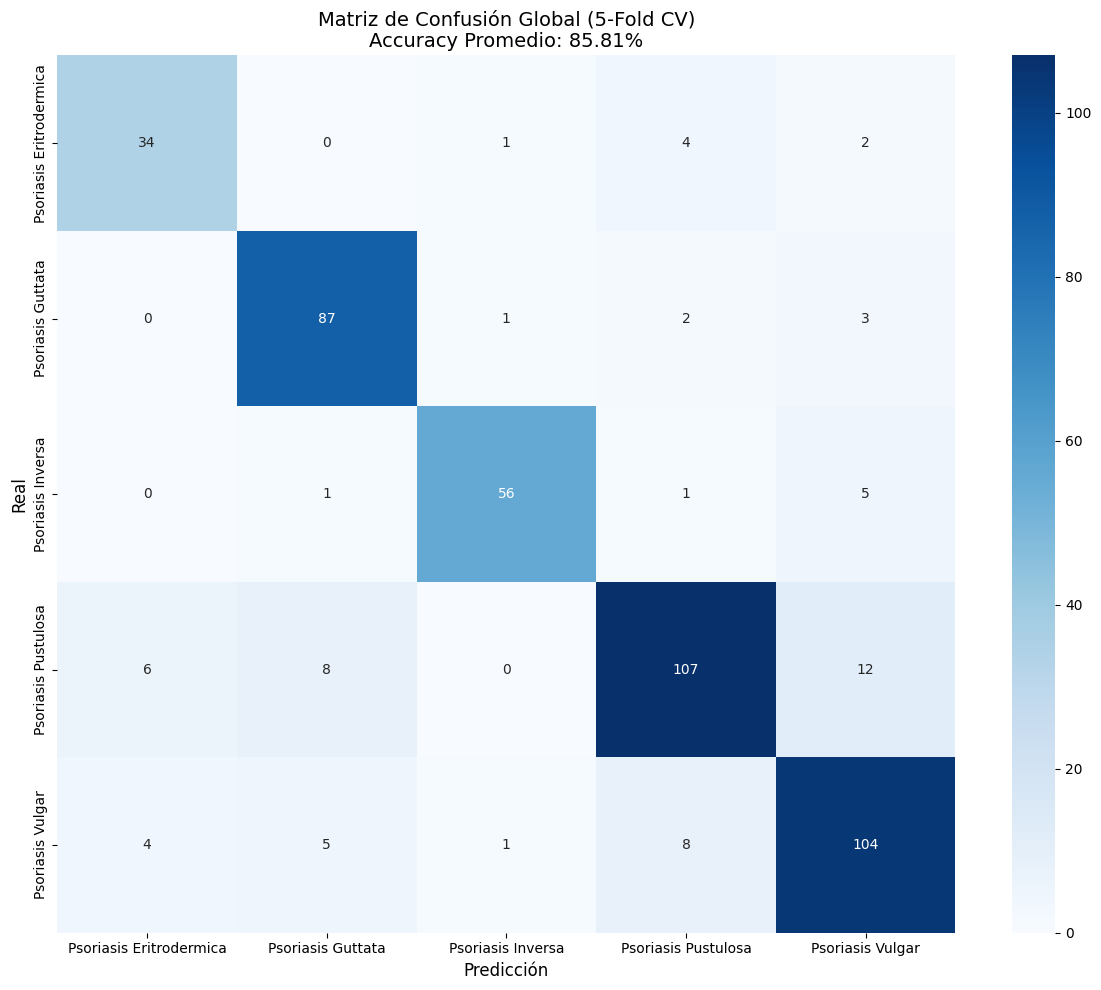


===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====
Cargando el dataset completo de train/val para el modelo final...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 133 imágenes. Objetivo por clase: 332
Generando 291 imágenes para la clase Psoriasis Eritrodermica...
Generando 239 imágenes para la clase Psoriasis Guttata...
Generando 269 imágenes para la clase Psoriasis Inversa...
Generando 199 imágenes para la clase Psoriasis Pustulosa...
Generando 210 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando modelo final con 1660 imágenes...
Epoch 1/100
187/187 - 52s - 279ms/step - accuracy: 0.6640 - loss: 0.9739 - val_accuracy: 0.8675 - val_loss: 0.4392 - learning_rate: 0.0010
Epoch 2/100
187/187 - 3s - 18ms/step - accuracy: 0.8280 - loss: 0.4895 - val_accuracy: 0.8916 - val_loss: 0.3466 - learning_rate: 0.0010
Epoch 3/100
187/187 - 3s - 15ms/step - accuracy: 0.8896 - loss: 0.3277 - val_accuracy: 0.8916 - val

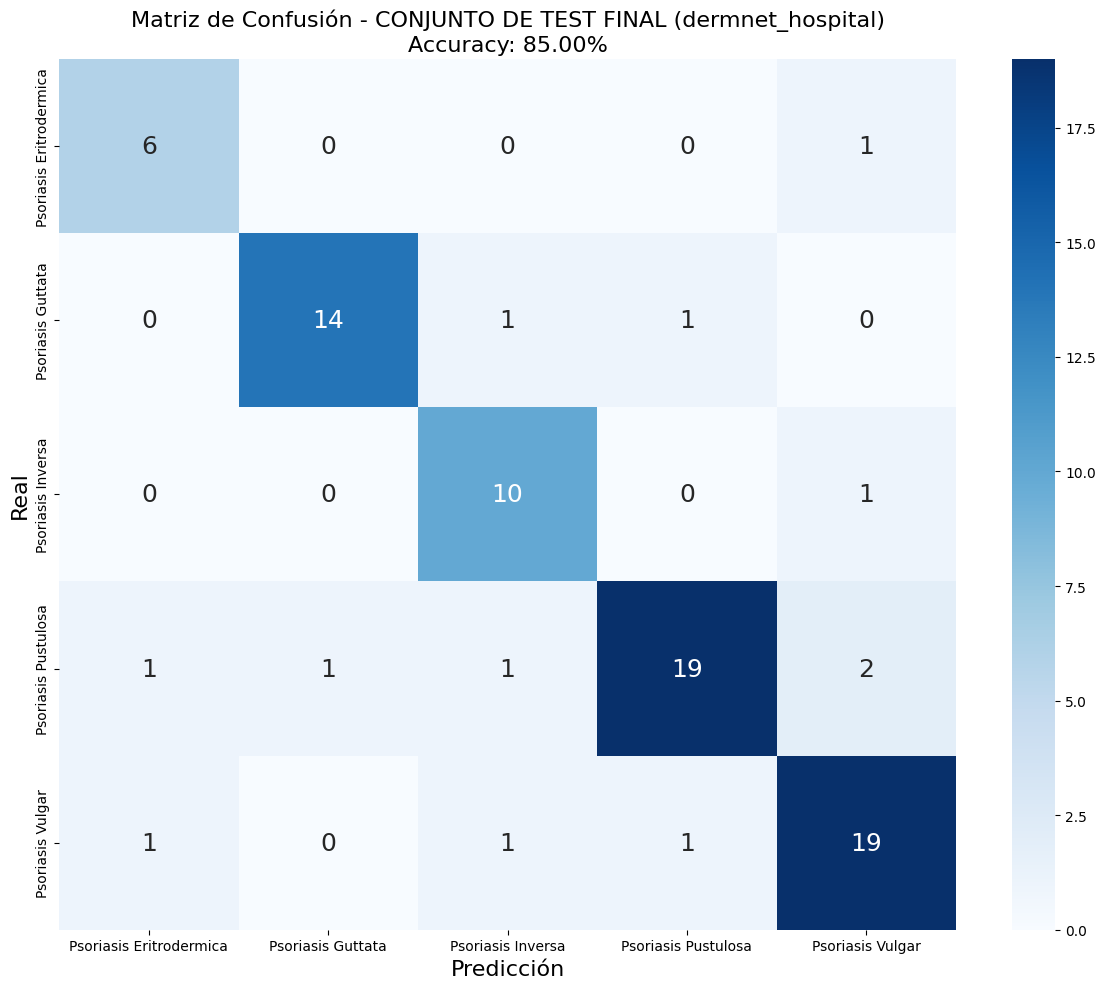


--- PROCESO COMPLETO FINALIZADO ---


In [3]:
# ==============================================================================
# SCRIPT COMPLETO DE ENTRENAMIENTO Y EVALUACIÓN - METODOLOGÍA TFG FINAL
# ==============================================================================
# Este script implementa el protocolo de evaluación de dos niveles:
# 1. Validación Cruzada K-Fold (K=5) sobre el 85% de los datos.
# 2. Entrenamiento de un Modelo Final y Evaluación sobre el 15% de test reservado.
#
# Se asume que el script de preparación con el split 85/15 ya ha sido ejecutado.
# ------------------------------------------------------------------------------

import os
import gc
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter

# Importaciones específicas de la metodología del TFG
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###

# ------------------------------------------------------------------------------
# MODIFICA ESTA VARIABLE PARA CAMBIAR DE EXPERIMENTO
# Opciones: "roboflow", "dermnet", "roboflow_dermnet"
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "dermnet_hospital"

# --- Rutas y Configuración General ---
BASE_PATH = "/kaggle/working/datasets_csv_85_15_caseib/splits"
OUTPUT_DIR = f"/kaggle/working/results_{EXPERIMENT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 44
tf.random.set_seed(SEED)
np.random.seed(SEED)

# --- Configuración K-Fold (Sección 3.6 del TFG) ---
N_SPLITS = 5

# --- Configuración del Modelo y Entrenamiento (Secciones 3.3, 3.4, 3.5 del TFG) ---
MODEL_CHOICE = EfficientNetB0
IMG_SIZE = 224 # Tamaño para EfficientNetB0
BATCH_SIZE = 8
EPOCHS = 100 # Un número alto, EarlyStopping decidirá cuándo parar
OVERSAMPLE_FACTOR = 2.5 # Factor de sobremuestreo descrito en el TFG

### --- 2. CARGA DE DATOS --- ###

# Rutas a los nuevos archivos 85/15
train_val_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_train_val_85.csv")
test_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_test_15.csv")

try:
    df_train_val = pd.read_csv(train_val_csv_path)
    df_test = pd.read_csv(test_csv_path)
    print(f"Datos cargados para '{EXPERIMENT_NAME}':")
    print(f"  - {len(df_train_val)} imágenes para K-Fold (85%)")
    print(f"  - {len(df_test)} imágenes para Test Final (15%)")
except FileNotFoundError as e:
    print(f"ERROR: No se encontró el archivo CSV: {e}. Asegúrate de ejecutar la Celda de Preparación primero.")
    raise e

# Mapeo de etiquetas a enteros
class_names = sorted(df_train_val['label_reassigned'].unique())
label_to_int = {label: i for i, label in enumerate(class_names)}
NUM_CLASSES = len(class_names)
df_train_val['label_int'] = df_train_val['label_reassigned'].map(label_to_int)
df_test['label_int'] = df_test['label_reassigned'].map(label_to_int)
print(f"Clases detectadas ({NUM_CLASSES}): {class_names}")


### --- 3. FUNCIONES AUXILIARES (Implementación de la Metodología) --- ###

def load_images_from_df(df):
    """Carga un conjunto de imágenes desde un dataframe a un array de NumPy."""
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(row['label_int'])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
            
    if not images:
        return np.array([]), np.array([])
        
    # Aplicar preprocesamiento de EfficientNet
    images_preprocessed = efficientnet_preprocess(np.array(images))
    return images_preprocessed, tf.keras.utils.to_categorical(np.array(labels), num_classes=NUM_CLASSES)

def balance_dataset_with_augmentation(X_data, y_data):
    """
    Implementación del balanceo de clases descrito en la Sección 3.2 del TFG.
    Aumenta las clases minoritarias hasta 2.5x el tamaño de la clase mayoritaria.
    """
    print("Iniciando balanceo de clases con aumento de datos...")
    
    # Parámetros de ImageDataGenerator descritos en el TFG
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )
    
    y_integers = np.argmax(y_data, axis=1)
    class_counts = Counter(y_integers)
    max_count = max(class_counts.values()) if class_counts else 0
    target_count = int(max_count * OVERSAMPLE_FACTOR)
    print(f"Clase mayoritaria: {max_count} imágenes. Objetivo por clase: {target_count}")

    X_balanced, y_balanced = list(X_data), list(y_data)
    
    for class_idx in range(NUM_CLASSES):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < target_count:
            needed = target_count - current_count
            print(f"Generando {needed} imágenes para la clase {class_names[class_idx]}...")
            
            images_to_augment = X_data[y_integers == class_idx]
            
            generator_flow = datagen.flow(images_to_augment, batch_size=1, seed=SEED)
            for _ in range(needed):
                X_balanced.append(next(generator_flow)[0])
                y_balanced.append(tf.keras.utils.to_categorical(class_idx, num_classes=NUM_CLASSES))
            
    print("Balanceo completado.")
    # Barajar el dataset final
    indices = np.arange(len(X_balanced))
    np.random.shuffle(indices)
    
    return np.array(X_balanced)[indices], np.array(y_balanced)[indices]

def create_model():
    """
    Crea la arquitectura del modelo descrita en la Sección 3.3 del TFG.
    """
    base_model = MODEL_CHOICE(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Base convolucional congelada

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

### --- 4. NIVEL 1 DE EVALUACIÓN: K-FOLD SOBRE EL 85% DEL DATASET --- ###

print("\n===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====")

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_accuracies = []
all_true_labels_kfold = []
all_pred_labels_kfold = []

for fold, (train_indices, val_indices) in enumerate(kf.split(df_train_val, df_train_val['label_int'])):
    print(f"\n--- INICIANDO FOLD {fold+1}/{N_SPLITS} ---")
    
    df_train_fold = df_train_val.iloc[train_indices]
    df_val_fold = df_train_val.iloc[val_indices]

    print("Cargando imágenes del fold en memoria...")
    X_train_fold, y_train_fold = load_images_from_df(df_train_fold)
    X_val_fold, y_val_fold = load_images_from_df(df_val_fold)
    
    if X_train_fold.size == 0 or X_val_fold.size == 0:
        print("Fold vacío, saltando.")
        continue
    
    X_train_balanced, y_train_balanced = balance_dataset_with_augmentation(X_train_fold, y_train_fold)

    model_fold = create_model()
    model_fold.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    
    print(f"Entrenando fold {fold+1} con {len(X_train_balanced)} imágenes de entrenamiento...")
    model_fold.fit(
        X_train_balanced, y_train_balanced,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=2 # Se pone a 0 para no saturar la salida. Cambiar a 1 o 2 para más detalle.
    )
    
    y_pred_probs = model_fold.predict(X_val_fold)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val_fold, axis=1)
    
    fold_accuracies.append(accuracy_score(y_true, y_pred))
    all_true_labels_kfold.extend(y_true)
    all_pred_labels_kfold.extend(y_pred)
    
    print(f"Accuracy del Fold {fold+1}: {fold_accuracies[-1]:.4f}")
    
    del model_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold, X_train_balanced, y_train_balanced
    tf.keras.backend.clear_session()
    gc.collect()

# --- Resultados Globales de K-Fold ---
print("\n--- RESULTADOS GLOBALES DE K-FOLD CROSS-VALIDATION (sobre el 85% del dataset) ---")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Precisión (Accuracy) Promedio en Folds de Validación: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
report_kfold = classification_report(all_true_labels_kfold, all_pred_labels_kfold, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación Global (K-Fold):\n", report_kfold)

cm_kfold = confusion_matrix(all_true_labels_kfold, all_pred_labels_kfold)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión Global ({N_SPLITS}-Fold CV)\nAccuracy Promedio: {mean_accuracy:.2%}', fontsize=14)
plt.xlabel('Predicción', fontsize=12); plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kfold_global_confusion_matrix.png"))
plt.show()

### --- 5. NIVEL 2 DE EVALUACIÓN: MODELO FINAL Y TEST RESERVADO (15%) --- ###

print("\n===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====")

# 1. Cargar todos los datos de entrenamiento/validación (el 85% completo)
print("Cargando el dataset completo de train/val para el modelo final...")
X_train_full, y_train_full = load_images_from_df(df_train_val)

# 2. Balancear el dataset completo
X_train_full_balanced, y_train_full_balanced = balance_dataset_with_augmentation(X_train_full, y_train_full)

# 3. Crear y compilar el modelo final
final_model = create_model()
final_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para el modelo final
final_model_path = os.path.join(OUTPUT_DIR, "final_model_best.h5")
checkpoint_final = ModelCheckpoint(final_model_path, monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping_final = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 5. Entrenar el modelo final
print(f"Entrenando modelo final con {len(X_train_full_balanced)} imágenes...")
# Usamos validation_split aquí para que los callbacks tengan datos en los que basarse.
final_model.fit(
    X_train_full_balanced, y_train_full_balanced,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1, # 10% de los datos de entrenamiento para validar internamente
    callbacks=[checkpoint_final, early_stopping_final, reduce_lr_final],
    verbose=2
)

# 6. Cargar los datos de test y el mejor modelo guardado
print("\n--- EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST RESERVADO (15%) ---")
X_test, y_test = load_images_from_df(df_test)
best_final_model = tf.keras.models.load_model(final_model_path)

# 7. Evaluar y mostrar resultados finales
loss, accuracy = best_final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nResultados en el Conjunto de Test Final:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

y_pred_probs_test = best_final_model.predict(X_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test, axis=1)

report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación (Test Final):\n", report_test)
with open(os.path.join(OUTPUT_DIR, "final_test_report.txt"), "w") as f:
    f.write(report_test)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
plt.title(f'Matriz de Confusión - CONJUNTO DE TEST FINAL ({EXPERIMENT_NAME})\nAccuracy: {accuracy:.2%}', fontsize=16)
plt.xlabel('Predicción', fontsize=16)
plt.ylabel('Real', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_test_confusion_matrix.png"))
plt.show()

print("\n--- PROCESO COMPLETO FINALIZADO ---")

## Combinación de ambos datasets 

2025-08-28 08:32:34.726008: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756369954.925192      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756369954.982013      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Datos cargados para 'roboflow_dermnet':
  - 799 imágenes para K-Fold (85%)
  - 142 imágenes para Test Final (15%)
Clases detectadas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====

--- INICIANDO FOLD 1/5 ---
Cargando imágenes del fold en memoria...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 187 imágenes. Objetivo por clase: 467
Generando 392 imágenes para la clase Psoriasis Eritrodermica...
Generando 354 imágenes para la clase Psoriasis Guttata...
Generando 374 imágenes para la clase Psoriasis Inversa...
Generando 280 imágenes para la clase Psoriasis Pustulosa...
Generando 296 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.


I0000 00:00:1756369991.292518      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756369991.293358      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenando fold 1 con 2335 imágenes de entrenamiento...
Epoch 1/100


I0000 00:00:1756370014.588750     101 service.cc:148] XLA service 0x7dd580015580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756370014.589593     101 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756370014.589614     101 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756370016.594036     101 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756370027.055792     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


292/292 - 51s - 176ms/step - accuracy: 0.6604 - loss: 0.9859 - val_accuracy: 0.8000 - val_loss: 0.8229 - learning_rate: 0.0010
Epoch 2/100
292/292 - 4s - 13ms/step - accuracy: 0.8214 - loss: 0.5008 - val_accuracy: 0.8313 - val_loss: 0.7392 - learning_rate: 0.0010
Epoch 3/100
292/292 - 4s - 13ms/step - accuracy: 0.8660 - loss: 0.3612 - val_accuracy: 0.8625 - val_loss: 0.7000 - learning_rate: 0.0010
Epoch 4/100
292/292 - 4s - 13ms/step - accuracy: 0.8981 - loss: 0.2877 - val_accuracy: 0.8313 - val_loss: 0.8181 - learning_rate: 0.0010
Epoch 5/100
292/292 - 4s - 13ms/step - accuracy: 0.9161 - loss: 0.2395 - val_accuracy: 0.7688 - val_loss: 1.2231 - learning_rate: 0.0010
Epoch 6/100
292/292 - 4s - 13ms/step - accuracy: 0.9255 - loss: 0.2002 - val_accuracy: 0.8562 - val_loss: 0.6588 - learning_rate: 0.0010
Epoch 7/100
292/292 - 4s - 13ms/step - accuracy: 0.9242 - loss: 0.2019 - val_accuracy: 0.8188 - val_loss: 1.0094 - learning_rate: 0.0010
Epoch 8/100
292/292 - 4s - 13ms/step - accuracy: 0.

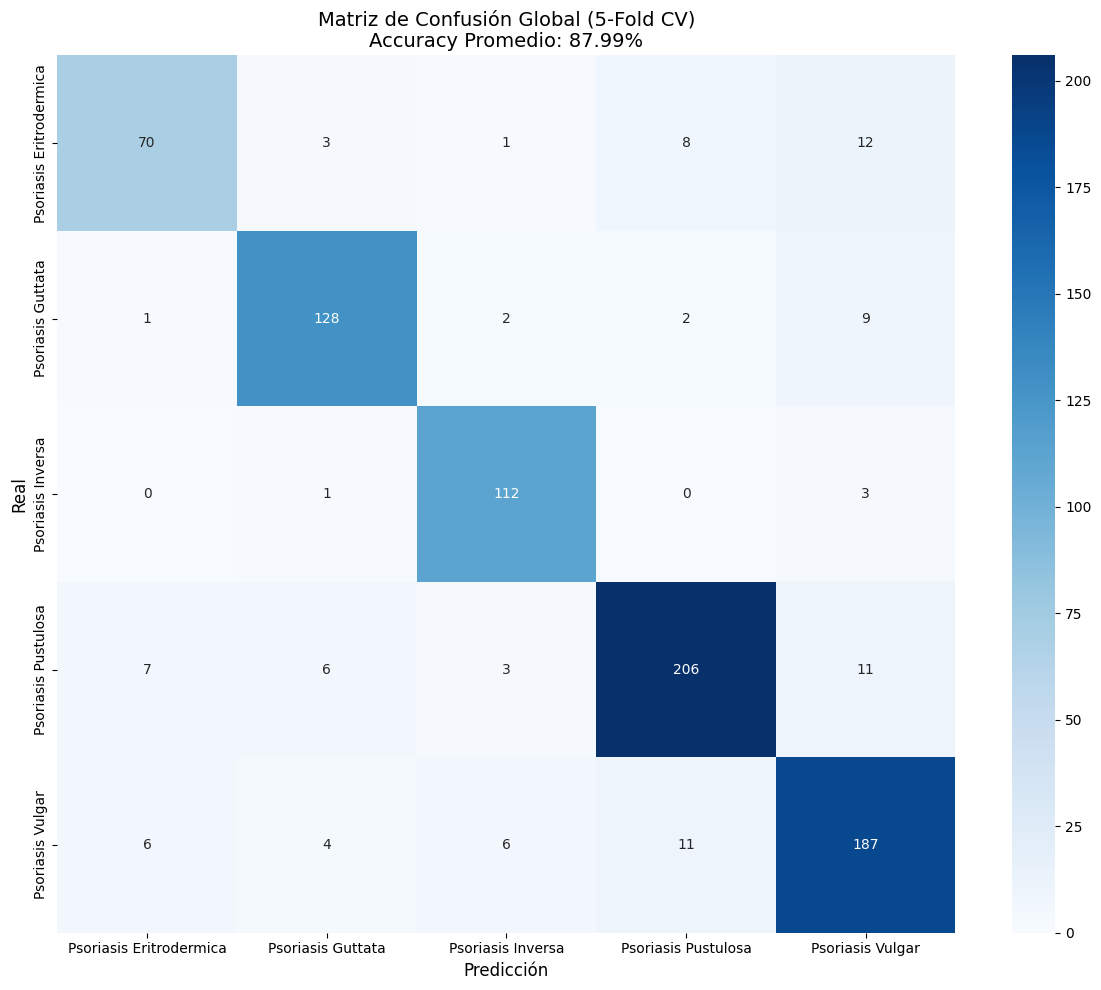


===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====
Cargando el dataset completo de train/val para el modelo final...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 233 imágenes. Objetivo por clase: 582
Generando 488 imágenes para la clase Psoriasis Eritrodermica...
Generando 440 imágenes para la clase Psoriasis Guttata...
Generando 466 imágenes para la clase Psoriasis Inversa...
Generando 349 imágenes para la clase Psoriasis Pustulosa...
Generando 368 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando modelo final con 2910 imágenes...
Epoch 1/100
328/328 - 49s - 150ms/step - accuracy: 0.6907 - loss: 0.9258 - val_accuracy: 0.8282 - val_loss: 0.5256 - learning_rate: 0.0010
Epoch 2/100
328/328 - 5s - 15ms/step - accuracy: 0.8121 - loss: 0.5445 - val_accuracy: 0.8557 - val_loss: 0.4507 - learning_rate: 0.0010
Epoch 3/100
328/328 - 5s - 15ms/step - accuracy: 0.8530 - loss: 0.4098 - val_accuracy: 0.8797 - val

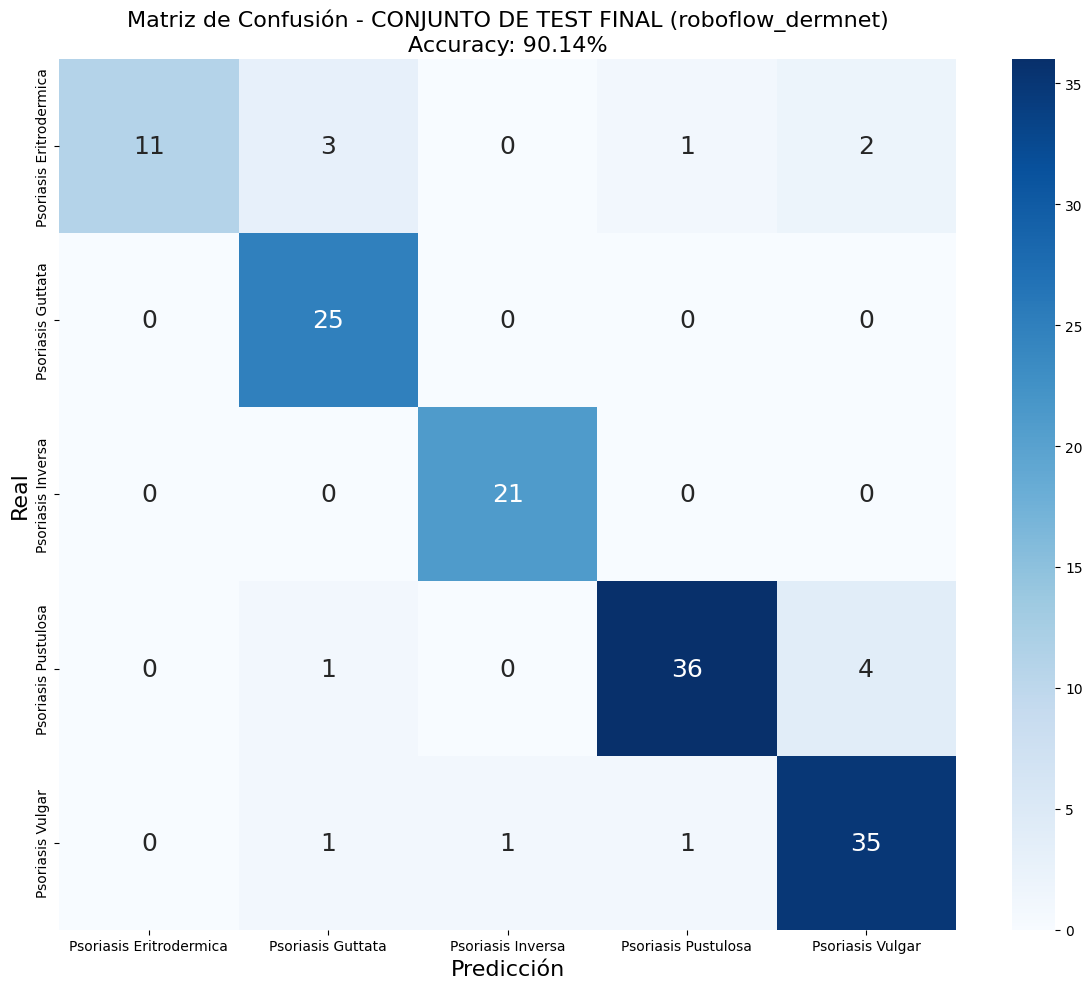


--- PROCESO COMPLETO FINALIZADO ---


In [2]:
# ==============================================================================
# SCRIPT COMPLETO DE ENTRENAMIENTO Y EVALUACIÓN - METODOLOGÍA TFG FINAL
# ==============================================================================
# Este script implementa el protocolo de evaluación de dos niveles:
# 1. Validación Cruzada K-Fold (K=5) sobre el 85% de los datos.
# 2. Entrenamiento de un Modelo Final y Evaluación sobre el 15% de test reservado.
#
# Se asume que el script de preparación con el split 85/15 ya ha sido ejecutado.
# ------------------------------------------------------------------------------

import os
import gc
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter

# Importaciones específicas de la metodología del TFG
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###

# ------------------------------------------------------------------------------
# MODIFICA ESTA VARIABLE PARA CAMBIAR DE EXPERIMENTO
# Opciones: "roboflow", "dermnet", "roboflow_dermnet"
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "roboflow_dermnet"

# --- Rutas y Configuración General ---
BASE_PATH = "/kaggle/working/datasets_csv_85_15_caseib/splits"
OUTPUT_DIR = f"/kaggle/working/results_{EXPERIMENT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 44
tf.random.set_seed(SEED)
np.random.seed(SEED)

# --- Configuración K-Fold (Sección 3.6 del TFG) ---
N_SPLITS = 5

# --- Configuración del Modelo y Entrenamiento (Secciones 3.3, 3.4, 3.5 del TFG) ---
MODEL_CHOICE = EfficientNetB0
IMG_SIZE = 224 # Tamaño para EfficientNetB0
BATCH_SIZE = 8
EPOCHS = 100 # Un número alto, EarlyStopping decidirá cuándo parar
OVERSAMPLE_FACTOR = 2.5 # Factor de sobremuestreo descrito en el TFG

### --- 2. CARGA DE DATOS --- ###

# Rutas a los nuevos archivos 85/15
train_val_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_train_val_85.csv")
test_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_test_15.csv")

try:
    df_train_val = pd.read_csv(train_val_csv_path)
    df_test = pd.read_csv(test_csv_path)
    print(f"Datos cargados para '{EXPERIMENT_NAME}':")
    print(f"  - {len(df_train_val)} imágenes para K-Fold (85%)")
    print(f"  - {len(df_test)} imágenes para Test Final (15%)")
except FileNotFoundError as e:
    print(f"ERROR: No se encontró el archivo CSV: {e}. Asegúrate de ejecutar la Celda de Preparación primero.")
    raise e

# Mapeo de etiquetas a enteros
class_names = sorted(df_train_val['label_reassigned'].unique())
label_to_int = {label: i for i, label in enumerate(class_names)}
NUM_CLASSES = len(class_names)
df_train_val['label_int'] = df_train_val['label_reassigned'].map(label_to_int)
df_test['label_int'] = df_test['label_reassigned'].map(label_to_int)
print(f"Clases detectadas ({NUM_CLASSES}): {class_names}")


### --- 3. FUNCIONES AUXILIARES (Implementación de la Metodología) --- ###

def load_images_from_df(df):
    """Carga un conjunto de imágenes desde un dataframe a un array de NumPy."""
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(row['label_int'])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
            
    if not images:
        return np.array([]), np.array([])
        
    # Aplicar preprocesamiento de EfficientNet
    images_preprocessed = efficientnet_preprocess(np.array(images))
    return images_preprocessed, tf.keras.utils.to_categorical(np.array(labels), num_classes=NUM_CLASSES)

def balance_dataset_with_augmentation(X_data, y_data):
    """
    Implementación del balanceo de clases descrito en la Sección 3.2 del TFG.
    Aumenta las clases minoritarias hasta 2.5x el tamaño de la clase mayoritaria.
    """
    print("Iniciando balanceo de clases con aumento de datos...")
    
    # Parámetros de ImageDataGenerator descritos en el TFG
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )
    
    y_integers = np.argmax(y_data, axis=1)
    class_counts = Counter(y_integers)
    max_count = max(class_counts.values()) if class_counts else 0
    target_count = int(max_count * OVERSAMPLE_FACTOR)
    print(f"Clase mayoritaria: {max_count} imágenes. Objetivo por clase: {target_count}")

    X_balanced, y_balanced = list(X_data), list(y_data)
    
    for class_idx in range(NUM_CLASSES):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < target_count:
            needed = target_count - current_count
            print(f"Generando {needed} imágenes para la clase {class_names[class_idx]}...")
            
            images_to_augment = X_data[y_integers == class_idx]
            
            generator_flow = datagen.flow(images_to_augment, batch_size=1, seed=SEED)
            for _ in range(needed):
                X_balanced.append(next(generator_flow)[0])
                y_balanced.append(tf.keras.utils.to_categorical(class_idx, num_classes=NUM_CLASSES))
            
    print("Balanceo completado.")
    # Barajar el dataset final
    indices = np.arange(len(X_balanced))
    np.random.shuffle(indices)
    
    return np.array(X_balanced)[indices], np.array(y_balanced)[indices]

def create_model():
    """
    Crea la arquitectura del modelo descrita en la Sección 3.3 del TFG.
    """
    base_model = MODEL_CHOICE(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Base convolucional congelada

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

### --- 4. NIVEL 1 DE EVALUACIÓN: K-FOLD SOBRE EL 85% DEL DATASET --- ###

print("\n===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====")

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_accuracies = []
all_true_labels_kfold = []
all_pred_labels_kfold = []

for fold, (train_indices, val_indices) in enumerate(kf.split(df_train_val, df_train_val['label_int'])):
    print(f"\n--- INICIANDO FOLD {fold+1}/{N_SPLITS} ---")
    
    df_train_fold = df_train_val.iloc[train_indices]
    df_val_fold = df_train_val.iloc[val_indices]

    print("Cargando imágenes del fold en memoria...")
    X_train_fold, y_train_fold = load_images_from_df(df_train_fold)
    X_val_fold, y_val_fold = load_images_from_df(df_val_fold)
    
    if X_train_fold.size == 0 or X_val_fold.size == 0:
        print("Fold vacío, saltando.")
        continue
    
    X_train_balanced, y_train_balanced = balance_dataset_with_augmentation(X_train_fold, y_train_fold)

    model_fold = create_model()
    model_fold.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    
    print(f"Entrenando fold {fold+1} con {len(X_train_balanced)} imágenes de entrenamiento...")
    model_fold.fit(
        X_train_balanced, y_train_balanced,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=2 # Se pone a 0 para no saturar la salida. Cambiar a 1 o 2 para más detalle.
    )
    
    y_pred_probs = model_fold.predict(X_val_fold)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val_fold, axis=1)
    
    fold_accuracies.append(accuracy_score(y_true, y_pred))
    all_true_labels_kfold.extend(y_true)
    all_pred_labels_kfold.extend(y_pred)
    
    print(f"Accuracy del Fold {fold+1}: {fold_accuracies[-1]:.4f}")
    
    del model_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold, X_train_balanced, y_train_balanced
    tf.keras.backend.clear_session()
    gc.collect()

# --- Resultados Globales de K-Fold ---
print("\n--- RESULTADOS GLOBALES DE K-FOLD CROSS-VALIDATION (sobre el 85% del dataset) ---")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Precisión (Accuracy) Promedio en Folds de Validación: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
report_kfold = classification_report(all_true_labels_kfold, all_pred_labels_kfold, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación Global (K-Fold):\n", report_kfold)

cm_kfold = confusion_matrix(all_true_labels_kfold, all_pred_labels_kfold)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión Global ({N_SPLITS}-Fold CV)\nAccuracy Promedio: {mean_accuracy:.2%}', fontsize=14)
plt.xlabel('Predicción', fontsize=12); plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kfold_global_confusion_matrix.png"))
plt.show()

### --- 5. NIVEL 2 DE EVALUACIÓN: MODELO FINAL Y TEST RESERVADO (15%) --- ###

print("\n===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====")

# 1. Cargar todos los datos de entrenamiento/validación (el 85% completo)
print("Cargando el dataset completo de train/val para el modelo final...")
X_train_full, y_train_full = load_images_from_df(df_train_val)

# 2. Balancear el dataset completo
X_train_full_balanced, y_train_full_balanced = balance_dataset_with_augmentation(X_train_full, y_train_full)

# 3. Crear y compilar el modelo final
final_model = create_model()
final_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para el modelo final
final_model_path = os.path.join(OUTPUT_DIR, "final_model_best.h5")
checkpoint_final = ModelCheckpoint(final_model_path, monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping_final = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 5. Entrenar el modelo final
print(f"Entrenando modelo final con {len(X_train_full_balanced)} imágenes...")
# Usamos validation_split aquí para que los callbacks tengan datos en los que basarse.
final_model.fit(
    X_train_full_balanced, y_train_full_balanced,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1, # 10% de los datos de entrenamiento para validar internamente
    callbacks=[checkpoint_final, early_stopping_final, reduce_lr_final],
    verbose=2
)

# 6. Cargar los datos de test y el mejor modelo guardado
print("\n--- EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST RESERVADO (15%) ---")
X_test, y_test = load_images_from_df(df_test)
best_final_model = tf.keras.models.load_model(final_model_path)

# 7. Evaluar y mostrar resultados finales
loss, accuracy = best_final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nResultados en el Conjunto de Test Final:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

y_pred_probs_test = best_final_model.predict(X_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test, axis=1)

report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación (Test Final):\n", report_test)
with open(os.path.join(OUTPUT_DIR, "final_test_report.txt"), "w") as f:
    f.write(report_test)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
plt.title(f'Matriz de Confusión - CONJUNTO DE TEST FINAL ({EXPERIMENT_NAME})\nAccuracy: {accuracy:.2%}', fontsize=16)
plt.xlabel('Predicción', fontsize=16)
plt.ylabel('Real', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_test_confusion_matrix.png"))
plt.show()

print("\n--- PROCESO COMPLETO FINALIZADO ---")

Datos cargados para 'roboflow_dermnet_hospital':
  - 830 imágenes para K-Fold (85%)
  - 147 imágenes para Test Final (15%)
Clases detectadas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====

--- INICIANDO FOLD 1/5 ---
Cargando imágenes del fold en memoria...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 192 imágenes. Objetivo por clase: 480
Generando 401 imágenes para la clase Psoriasis Eritrodermica...
Generando 367 imágenes para la clase Psoriasis Guttata...
Generando 388 imágenes para la clase Psoriasis Inversa...
Generando 292 imágenes para la clase Psoriasis Pustulosa...
Generando 288 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando fold 1 con 2400 imágenes de entrenamiento...
Epoch 1/100
300/300 - 39s - 130ms/step - accuracy: 0.6854 - loss: 0.9372 - val_accuracy: 0.8253 - val_loss: 0.6

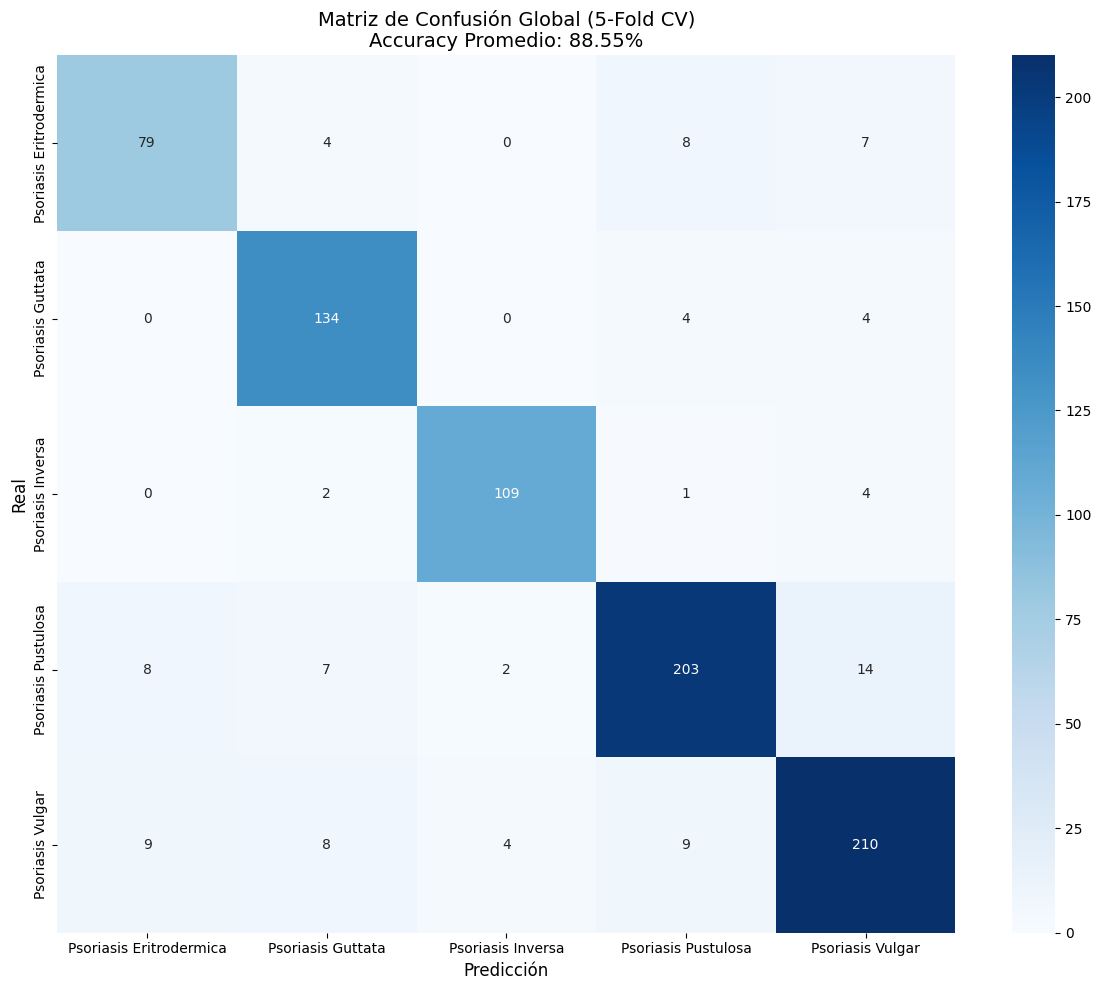


===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====
Cargando el dataset completo de train/val para el modelo final...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 240 imágenes. Objetivo por clase: 600
Generando 502 imágenes para la clase Psoriasis Eritrodermica...
Generando 458 imágenes para la clase Psoriasis Guttata...
Generando 484 imágenes para la clase Psoriasis Inversa...
Generando 366 imágenes para la clase Psoriasis Pustulosa...
Generando 360 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando modelo final con 3000 imágenes...
Epoch 1/100
338/338 - 48s - 142ms/step - accuracy: 0.6711 - loss: 0.9469 - val_accuracy: 0.8133 - val_loss: 0.7104 - learning_rate: 0.0010
Epoch 2/100
338/338 - 5s - 15ms/step - accuracy: 0.8107 - loss: 0.5408 - val_accuracy: 0.8533 - val_loss: 0.5842 - learning_rate: 0.0010
Epoch 3/100
338/338 - 5s - 15ms/step - accuracy: 0.8674 - loss: 0.3844 - val_accuracy: 0.8567 - val

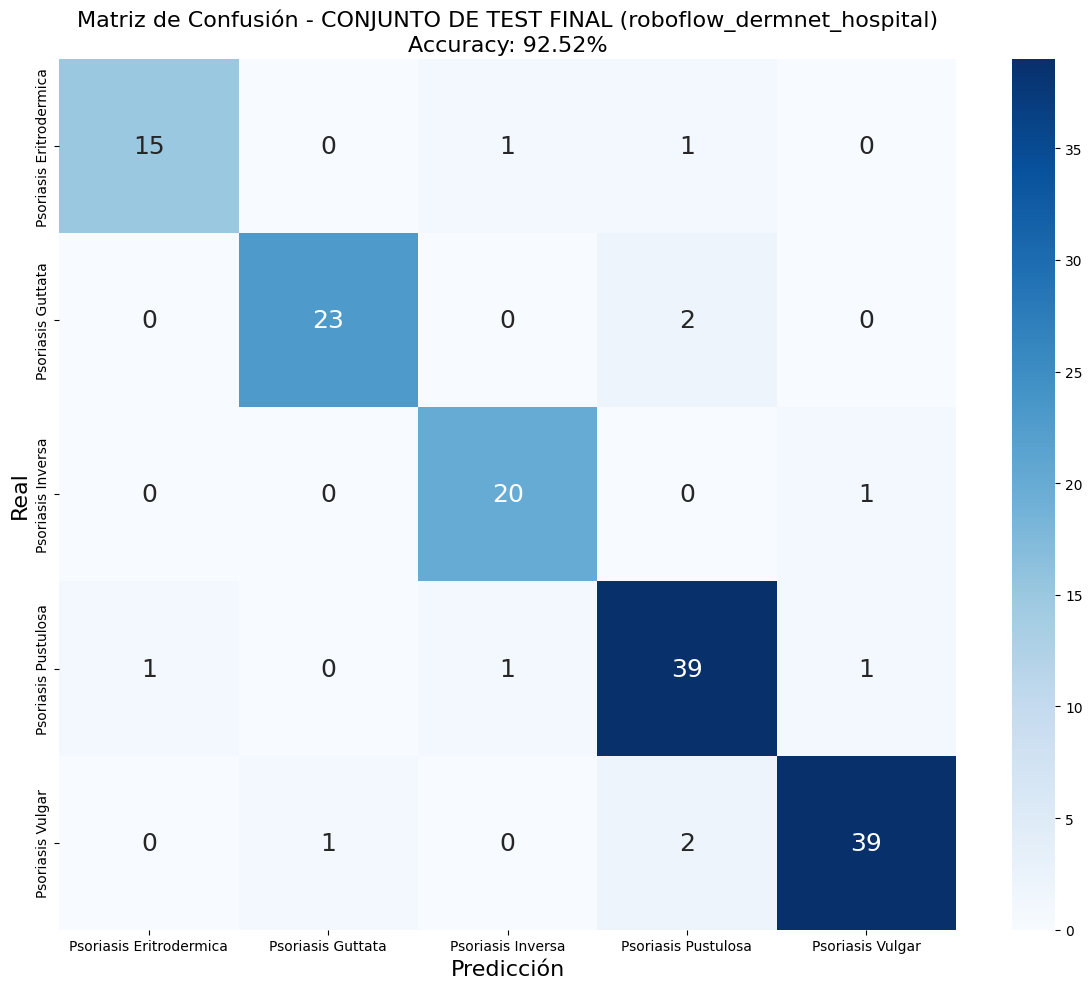


--- PROCESO COMPLETO FINALIZADO ---


In [6]:
# ==============================================================================
# SCRIPT COMPLETO DE ENTRENAMIENTO Y EVALUACIÓN - METODOLOGÍA TFG FINAL
# ==============================================================================
# Este script implementa el protocolo de evaluación de dos niveles:
# 1. Validación Cruzada K-Fold (K=5) sobre el 85% de los datos.
# 2. Entrenamiento de un Modelo Final y Evaluación sobre el 15% de test reservado.
#
# Se asume que el script de preparación con el split 85/15 ya ha sido ejecutado.
# ------------------------------------------------------------------------------

import os
import gc
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter

# Importaciones específicas de la metodología del TFG
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###

# ------------------------------------------------------------------------------
# MODIFICA ESTA VARIABLE PARA CAMBIAR DE EXPERIMENTO
# Opciones: "roboflow", "dermnet", "roboflow_dermnet"
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "roboflow_dermnet_hospital"

# --- Rutas y Configuración General ---
BASE_PATH = "/kaggle/working/datasets_csv_85_15_caseib/splits"
OUTPUT_DIR = f"/kaggle/working/results_{EXPERIMENT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 44
tf.random.set_seed(SEED)
np.random.seed(SEED)

# --- Configuración K-Fold (Sección 3.6 del TFG) ---
N_SPLITS = 5

# --- Configuración del Modelo y Entrenamiento (Secciones 3.3, 3.4, 3.5 del TFG) ---
MODEL_CHOICE = EfficientNetB0
IMG_SIZE = 224 # Tamaño para EfficientNetB0
BATCH_SIZE = 8
EPOCHS = 100 # Un número alto, EarlyStopping decidirá cuándo parar
OVERSAMPLE_FACTOR = 2.5 # Factor de sobremuestreo descrito en el TFG

### --- 2. CARGA DE DATOS --- ###

# Rutas a los nuevos archivos 85/15
train_val_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_train_val_85.csv")
test_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_test_15.csv")

try:
    df_train_val = pd.read_csv(train_val_csv_path)
    df_test = pd.read_csv(test_csv_path)
    print(f"Datos cargados para '{EXPERIMENT_NAME}':")
    print(f"  - {len(df_train_val)} imágenes para K-Fold (85%)")
    print(f"  - {len(df_test)} imágenes para Test Final (15%)")
except FileNotFoundError as e:
    print(f"ERROR: No se encontró el archivo CSV: {e}. Asegúrate de ejecutar la Celda de Preparación primero.")
    raise e

# Mapeo de etiquetas a enteros
class_names = sorted(df_train_val['label_reassigned'].unique())
label_to_int = {label: i for i, label in enumerate(class_names)}
NUM_CLASSES = len(class_names)
df_train_val['label_int'] = df_train_val['label_reassigned'].map(label_to_int)
df_test['label_int'] = df_test['label_reassigned'].map(label_to_int)
print(f"Clases detectadas ({NUM_CLASSES}): {class_names}")


### --- 3. FUNCIONES AUXILIARES (Implementación de la Metodología) --- ###

def load_images_from_df(df):
    """Carga un conjunto de imágenes desde un dataframe a un array de NumPy."""
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(row['label_int'])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
            
    if not images:
        return np.array([]), np.array([])
        
    # Aplicar preprocesamiento de EfficientNet
    images_preprocessed = efficientnet_preprocess(np.array(images))
    return images_preprocessed, tf.keras.utils.to_categorical(np.array(labels), num_classes=NUM_CLASSES)

def balance_dataset_with_augmentation(X_data, y_data):
    """
    Implementación del balanceo de clases descrito en la Sección 3.2 del TFG.
    Aumenta las clases minoritarias hasta 2.5x el tamaño de la clase mayoritaria.
    """
    print("Iniciando balanceo de clases con aumento de datos...")
    
    # Parámetros de ImageDataGenerator descritos en el TFG
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )
    
    y_integers = np.argmax(y_data, axis=1)
    class_counts = Counter(y_integers)
    max_count = max(class_counts.values()) if class_counts else 0
    target_count = int(max_count * OVERSAMPLE_FACTOR)
    print(f"Clase mayoritaria: {max_count} imágenes. Objetivo por clase: {target_count}")

    X_balanced, y_balanced = list(X_data), list(y_data)
    
    for class_idx in range(NUM_CLASSES):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < target_count:
            needed = target_count - current_count
            print(f"Generando {needed} imágenes para la clase {class_names[class_idx]}...")
            
            images_to_augment = X_data[y_integers == class_idx]
            
            generator_flow = datagen.flow(images_to_augment, batch_size=1, seed=SEED)
            for _ in range(needed):
                X_balanced.append(next(generator_flow)[0])
                y_balanced.append(tf.keras.utils.to_categorical(class_idx, num_classes=NUM_CLASSES))
            
    print("Balanceo completado.")
    # Barajar el dataset final
    indices = np.arange(len(X_balanced))
    np.random.shuffle(indices)
    
    return np.array(X_balanced)[indices], np.array(y_balanced)[indices]

def create_model():
    """
    Crea la arquitectura del modelo descrita en la Sección 3.3 del TFG.
    """
    base_model = MODEL_CHOICE(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Base convolucional congelada

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

### --- 4. NIVEL 1 DE EVALUACIÓN: K-FOLD SOBRE EL 85% DEL DATASET --- ###

print("\n===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====")

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_accuracies = []
all_true_labels_kfold = []
all_pred_labels_kfold = []

for fold, (train_indices, val_indices) in enumerate(kf.split(df_train_val, df_train_val['label_int'])):
    print(f"\n--- INICIANDO FOLD {fold+1}/{N_SPLITS} ---")
    
    df_train_fold = df_train_val.iloc[train_indices]
    df_val_fold = df_train_val.iloc[val_indices]

    print("Cargando imágenes del fold en memoria...")
    X_train_fold, y_train_fold = load_images_from_df(df_train_fold)
    X_val_fold, y_val_fold = load_images_from_df(df_val_fold)
    
    if X_train_fold.size == 0 or X_val_fold.size == 0:
        print("Fold vacío, saltando.")
        continue
    
    X_train_balanced, y_train_balanced = balance_dataset_with_augmentation(X_train_fold, y_train_fold)

    model_fold = create_model()
    model_fold.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    
    print(f"Entrenando fold {fold+1} con {len(X_train_balanced)} imágenes de entrenamiento...")
    model_fold.fit(
        X_train_balanced, y_train_balanced,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=2 # Se pone a 0 para no saturar la salida. Cambiar a 1 o 2 para más detalle.
    )
    
    y_pred_probs = model_fold.predict(X_val_fold)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val_fold, axis=1)
    
    fold_accuracies.append(accuracy_score(y_true, y_pred))
    all_true_labels_kfold.extend(y_true)
    all_pred_labels_kfold.extend(y_pred)
    
    print(f"Accuracy del Fold {fold+1}: {fold_accuracies[-1]:.4f}")
    
    del model_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold, X_train_balanced, y_train_balanced
    tf.keras.backend.clear_session()
    gc.collect()

# --- Resultados Globales de K-Fold ---
print("\n--- RESULTADOS GLOBALES DE K-FOLD CROSS-VALIDATION (sobre el 85% del dataset) ---")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Precisión (Accuracy) Promedio en Folds de Validación: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
report_kfold = classification_report(all_true_labels_kfold, all_pred_labels_kfold, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación Global (K-Fold):\n", report_kfold)

cm_kfold = confusion_matrix(all_true_labels_kfold, all_pred_labels_kfold)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión Global ({N_SPLITS}-Fold CV)\nAccuracy Promedio: {mean_accuracy:.2%}', fontsize=14)
plt.xlabel('Predicción', fontsize=12); plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kfold_global_confusion_matrix.png"))
plt.show()

### --- 5. NIVEL 2 DE EVALUACIÓN: MODELO FINAL Y TEST RESERVADO (15%) --- ###

print("\n===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====")

# 1. Cargar todos los datos de entrenamiento/validación (el 85% completo)
print("Cargando el dataset completo de train/val para el modelo final...")
X_train_full, y_train_full = load_images_from_df(df_train_val)

# 2. Balancear el dataset completo
X_train_full_balanced, y_train_full_balanced = balance_dataset_with_augmentation(X_train_full, y_train_full)

# 3. Crear y compilar el modelo final
final_model = create_model()
final_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para el modelo final
final_model_path = os.path.join(OUTPUT_DIR, "final_model_best.h5")
checkpoint_final = ModelCheckpoint(final_model_path, monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping_final = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 5. Entrenar el modelo final
print(f"Entrenando modelo final con {len(X_train_full_balanced)} imágenes...")
# Usamos validation_split aquí para que los callbacks tengan datos en los que basarse.
final_model.fit(
    X_train_full_balanced, y_train_full_balanced,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1, # 10% de los datos de entrenamiento para validar internamente
    callbacks=[checkpoint_final, early_stopping_final, reduce_lr_final],
    verbose=2
)

# 6. Cargar los datos de test y el mejor modelo guardado
print("\n--- EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST RESERVADO (15%) ---")
X_test, y_test = load_images_from_df(df_test)
best_final_model = tf.keras.models.load_model(final_model_path)

# 7. Evaluar y mostrar resultados finales
loss, accuracy = best_final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nResultados en el Conjunto de Test Final:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

y_pred_probs_test = best_final_model.predict(X_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test, axis=1)

report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación (Test Final):\n", report_test)
with open(os.path.join(OUTPUT_DIR, "final_test_report.txt"), "w") as f:
    f.write(report_test)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
plt.title(f'Matriz de Confusión - CONJUNTO DE TEST FINAL ({EXPERIMENT_NAME})\nAccuracy: {accuracy:.2%}', fontsize=16)
plt.xlabel('Predicción', fontsize=16)
plt.ylabel('Real', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_test_confusion_matrix.png"))
plt.show()

print("\n--- PROCESO COMPLETO FINALIZADO ---")

### K = 10 Folds

2025-08-29 07:48:17.246722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756453697.656719      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756453697.767846      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Datos cargados para 'roboflow_dermnet_hospital':
  - 830 imágenes para K-Fold (85%)
  - 147 imágenes para Test Final (15%)
Clases detectadas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====

--- INICIANDO FOLD 1/10 ---
Cargando imágenes del fold en memoria...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 216 imágenes. Objetivo por clase: 540
Generando 451 imágenes para la clase Psoriasis Eritrodermica...
Generando 413 imágenes para la clase Psoriasis Guttata...
Generando 436 imágenes para la clase Psoriasis Inversa...
Generando 329 imágenes para la clase Psoriasis Pustulosa...
Generando 324 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.


I0000 00:00:1756453743.280193      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756453743.280890      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenando fold 1 con 2700 imágenes de entrenamiento...
Epoch 1/100


I0000 00:00:1756453766.589322     101 service.cc:148] XLA service 0x78246c092750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756453766.590623     101 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756453766.590644     101 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756453768.522426     101 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756453778.811938     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


338/338 - 54s - 159ms/step - accuracy: 0.6989 - loss: 0.9039 - val_accuracy: 0.7229 - val_loss: 0.8435 - learning_rate: 0.0010
Epoch 2/100
338/338 - 4s - 13ms/step - accuracy: 0.8122 - loss: 0.5213 - val_accuracy: 0.7831 - val_loss: 0.8897 - learning_rate: 0.0010
Epoch 3/100
338/338 - 4s - 12ms/step - accuracy: 0.8674 - loss: 0.3715 - val_accuracy: 0.7711 - val_loss: 0.8109 - learning_rate: 0.0010
Epoch 4/100
338/338 - 4s - 12ms/step - accuracy: 0.8885 - loss: 0.2994 - val_accuracy: 0.7711 - val_loss: 1.0578 - learning_rate: 0.0010
Epoch 5/100
338/338 - 4s - 12ms/step - accuracy: 0.9174 - loss: 0.2311 - val_accuracy: 0.7952 - val_loss: 0.7990 - learning_rate: 0.0010
Epoch 6/100
338/338 - 4s - 12ms/step - accuracy: 0.9289 - loss: 0.1944 - val_accuracy: 0.7952 - val_loss: 0.8197 - learning_rate: 0.0010
Epoch 7/100
338/338 - 4s - 12ms/step - accuracy: 0.9263 - loss: 0.1928 - val_accuracy: 0.7952 - val_loss: 0.8982 - learning_rate: 0.0010
Epoch 8/100
338/338 - 4s - 12ms/step - accuracy: 0.

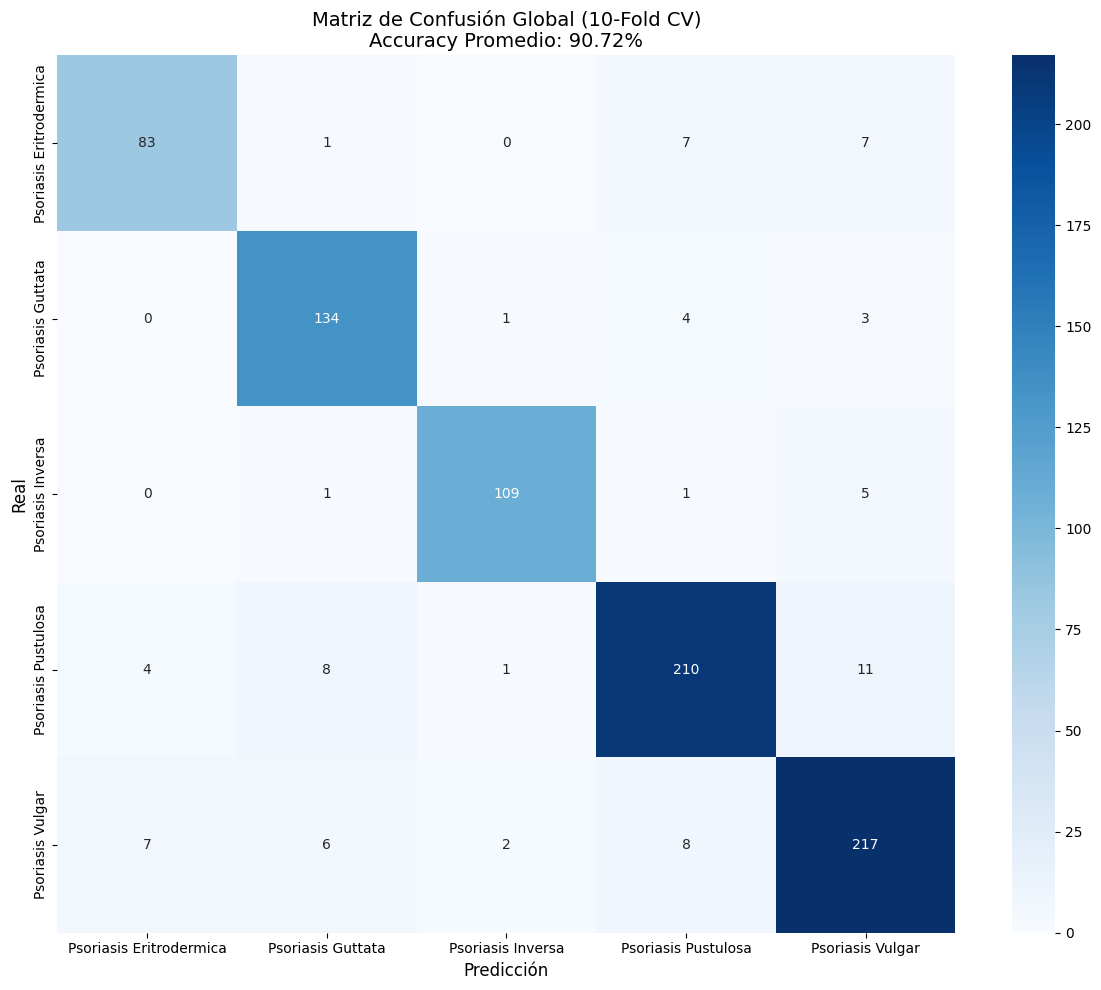


===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====
Cargando el dataset completo de train/val para el modelo final...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 240 imágenes. Objetivo por clase: 600
Generando 502 imágenes para la clase Psoriasis Eritrodermica...
Generando 458 imágenes para la clase Psoriasis Guttata...
Generando 484 imágenes para la clase Psoriasis Inversa...
Generando 366 imágenes para la clase Psoriasis Pustulosa...
Generando 360 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando modelo final con 3000 imágenes...
Epoch 1/100
338/338 - 48s - 141ms/step - accuracy: 0.6889 - loss: 0.9080 - val_accuracy: 0.8233 - val_loss: 0.6855 - learning_rate: 0.0010
Epoch 2/100
338/338 - 5s - 15ms/step - accuracy: 0.8115 - loss: 0.5530 - val_accuracy: 0.8400 - val_loss: 0.5890 - learning_rate: 0.0010
Epoch 3/100
338/338 - 5s - 15ms/step - accuracy: 0.8719 - loss: 0.3768 - val_accuracy: 0.8533 - val

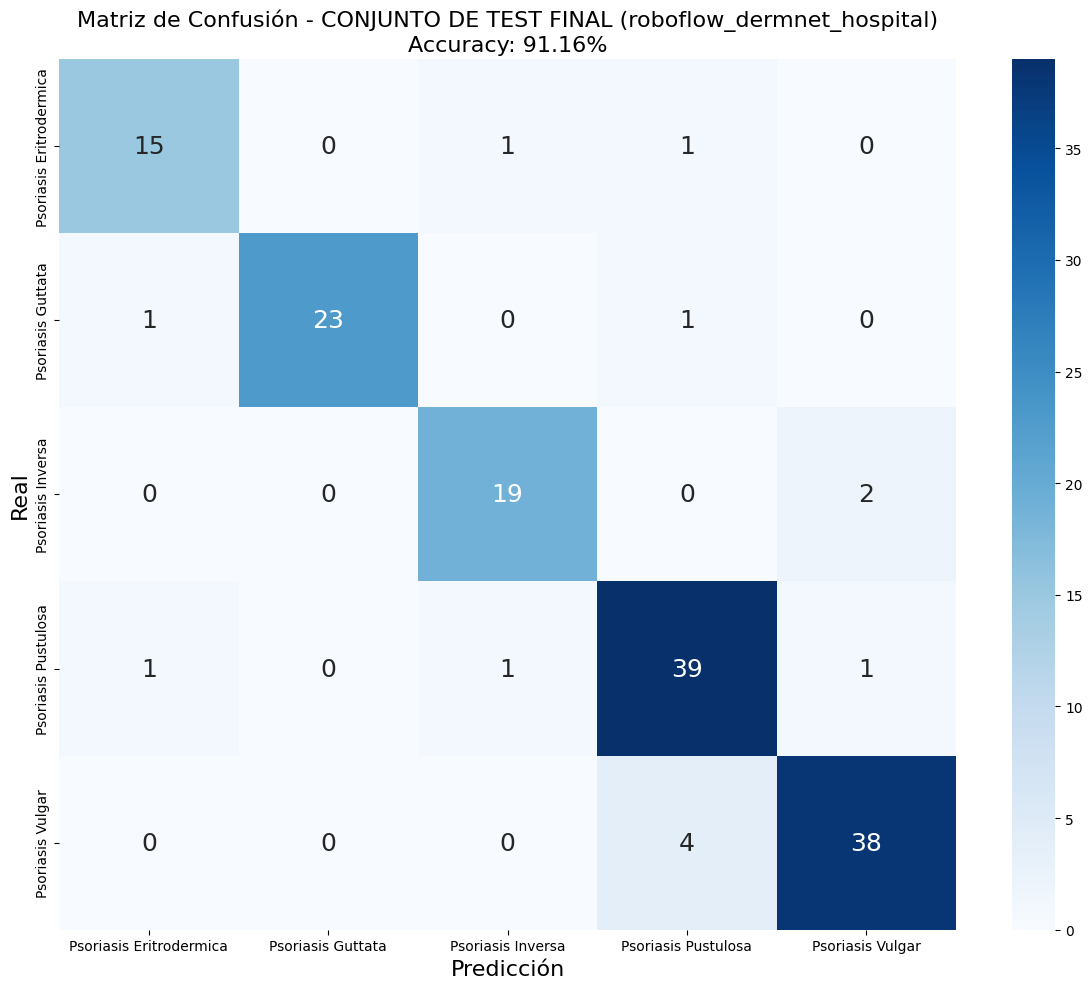


--- PROCESO COMPLETO FINALIZADO ---


In [2]:
# ==============================================================================
# SCRIPT COMPLETO DE ENTRENAMIENTO Y EVALUACIÓN - METODOLOGÍA TFG FINAL
# ==============================================================================
# Este script implementa el protocolo de evaluación de dos niveles:
# 1. Validación Cruzada K-Fold (K=5) sobre el 85% de los datos.
# 2. Entrenamiento de un Modelo Final y Evaluación sobre el 15% de test reservado.
#
# Se asume que el script de preparación con el split 85/15 ya ha sido ejecutado.
# ------------------------------------------------------------------------------

import os
import gc
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter

# Importaciones específicas de la metodología del TFG
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###

# ------------------------------------------------------------------------------
# MODIFICA ESTA VARIABLE PARA CAMBIAR DE EXPERIMENTO
# Opciones: "roboflow", "dermnet", "roboflow_dermnet"
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "roboflow_dermnet_hospital"

# --- Rutas y Configuración General ---
BASE_PATH = "/kaggle/working/datasets_csv_85_15_caseib/splits"
OUTPUT_DIR = f"/kaggle/working/results_{EXPERIMENT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 44
tf.random.set_seed(SEED)
np.random.seed(SEED)

# --- Configuración K-Fold (Sección 3.6 del TFG) ---
N_SPLITS = 10

# --- Configuración del Modelo y Entrenamiento (Secciones 3.3, 3.4, 3.5 del TFG) ---
MODEL_CHOICE = EfficientNetB0
IMG_SIZE = 224 # Tamaño para EfficientNetB0
BATCH_SIZE = 8
EPOCHS = 100 # Un número alto, EarlyStopping decidirá cuándo parar
OVERSAMPLE_FACTOR = 2.5 # Factor de sobremuestreo descrito en el TFG

### --- 2. CARGA DE DATOS --- ###

# Rutas a los nuevos archivos 85/15
train_val_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_train_val_85.csv")
test_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_test_15.csv")

try:
    df_train_val = pd.read_csv(train_val_csv_path)
    df_test = pd.read_csv(test_csv_path)
    print(f"Datos cargados para '{EXPERIMENT_NAME}':")
    print(f"  - {len(df_train_val)} imágenes para K-Fold (85%)")
    print(f"  - {len(df_test)} imágenes para Test Final (15%)")
except FileNotFoundError as e:
    print(f"ERROR: No se encontró el archivo CSV: {e}. Asegúrate de ejecutar la Celda de Preparación primero.")
    raise e

# Mapeo de etiquetas a enteros
class_names = sorted(df_train_val['label_reassigned'].unique())
label_to_int = {label: i for i, label in enumerate(class_names)}
NUM_CLASSES = len(class_names)
df_train_val['label_int'] = df_train_val['label_reassigned'].map(label_to_int)
df_test['label_int'] = df_test['label_reassigned'].map(label_to_int)
print(f"Clases detectadas ({NUM_CLASSES}): {class_names}")


### --- 3. FUNCIONES AUXILIARES (Implementación de la Metodología) --- ###

def load_images_from_df(df):
    """Carga un conjunto de imágenes desde un dataframe a un array de NumPy."""
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(row['label_int'])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
            
    if not images:
        return np.array([]), np.array([])
        
    # Aplicar preprocesamiento de EfficientNet
    images_preprocessed = efficientnet_preprocess(np.array(images))
    return images_preprocessed, tf.keras.utils.to_categorical(np.array(labels), num_classes=NUM_CLASSES)

def balance_dataset_with_augmentation(X_data, y_data):
    """
    Implementación del balanceo de clases descrito en la Sección 3.2 del TFG.
    Aumenta las clases minoritarias hasta 2.5x el tamaño de la clase mayoritaria.
    """
    print("Iniciando balanceo de clases con aumento de datos...")
    
    # Parámetros de ImageDataGenerator descritos en el TFG
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )
    
    y_integers = np.argmax(y_data, axis=1)
    class_counts = Counter(y_integers)
    max_count = max(class_counts.values()) if class_counts else 0
    target_count = int(max_count * OVERSAMPLE_FACTOR)
    print(f"Clase mayoritaria: {max_count} imágenes. Objetivo por clase: {target_count}")

    X_balanced, y_balanced = list(X_data), list(y_data)
    
    for class_idx in range(NUM_CLASSES):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < target_count:
            needed = target_count - current_count
            print(f"Generando {needed} imágenes para la clase {class_names[class_idx]}...")
            
            images_to_augment = X_data[y_integers == class_idx]
            
            generator_flow = datagen.flow(images_to_augment, batch_size=1, seed=SEED)
            for _ in range(needed):
                X_balanced.append(next(generator_flow)[0])
                y_balanced.append(tf.keras.utils.to_categorical(class_idx, num_classes=NUM_CLASSES))
            
    print("Balanceo completado.")
    # Barajar el dataset final
    indices = np.arange(len(X_balanced))
    np.random.shuffle(indices)
    
    return np.array(X_balanced)[indices], np.array(y_balanced)[indices]

def create_model():
    """
    Crea la arquitectura del modelo descrita en la Sección 3.3 del TFG.
    """
    base_model = MODEL_CHOICE(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Base convolucional congelada

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

### --- 4. NIVEL 1 DE EVALUACIÓN: K-FOLD SOBRE EL 85% DEL DATASET --- ###

print("\n===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====")

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_accuracies = []
all_true_labels_kfold = []
all_pred_labels_kfold = []

for fold, (train_indices, val_indices) in enumerate(kf.split(df_train_val, df_train_val['label_int'])):
    print(f"\n--- INICIANDO FOLD {fold+1}/{N_SPLITS} ---")
    
    df_train_fold = df_train_val.iloc[train_indices]
    df_val_fold = df_train_val.iloc[val_indices]

    print("Cargando imágenes del fold en memoria...")
    X_train_fold, y_train_fold = load_images_from_df(df_train_fold)
    X_val_fold, y_val_fold = load_images_from_df(df_val_fold)
    
    if X_train_fold.size == 0 or X_val_fold.size == 0:
        print("Fold vacío, saltando.")
        continue
    
    X_train_balanced, y_train_balanced = balance_dataset_with_augmentation(X_train_fold, y_train_fold)

    model_fold = create_model()
    model_fold.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    
    print(f"Entrenando fold {fold+1} con {len(X_train_balanced)} imágenes de entrenamiento...")
    model_fold.fit(
        X_train_balanced, y_train_balanced,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=2 # Se pone a 0 para no saturar la salida. Cambiar a 1 o 2 para más detalle.
    )
    
    y_pred_probs = model_fold.predict(X_val_fold)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val_fold, axis=1)
    
    fold_accuracies.append(accuracy_score(y_true, y_pred))
    all_true_labels_kfold.extend(y_true)
    all_pred_labels_kfold.extend(y_pred)
    
    print(f"Accuracy del Fold {fold+1}: {fold_accuracies[-1]:.4f}")
    
    del model_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold, X_train_balanced, y_train_balanced
    tf.keras.backend.clear_session()
    gc.collect()

# --- Resultados Globales de K-Fold ---
print("\n--- RESULTADOS GLOBALES DE K-FOLD CROSS-VALIDATION (sobre el 85% del dataset) ---")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Precisión (Accuracy) Promedio en Folds de Validación: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
report_kfold = classification_report(all_true_labels_kfold, all_pred_labels_kfold, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación Global (K-Fold):\n", report_kfold)

cm_kfold = confusion_matrix(all_true_labels_kfold, all_pred_labels_kfold)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión Global ({N_SPLITS}-Fold CV)\nAccuracy Promedio: {mean_accuracy:.2%}', fontsize=14)
plt.xlabel('Predicción', fontsize=12); plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kfold_global_confusion_matrix.png"))
plt.show()

### --- 5. NIVEL 2 DE EVALUACIÓN: MODELO FINAL Y TEST RESERVADO (15%) --- ###

print("\n===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====")

# 1. Cargar todos los datos de entrenamiento/validación (el 85% completo)
print("Cargando el dataset completo de train/val para el modelo final...")
X_train_full, y_train_full = load_images_from_df(df_train_val)

# 2. Balancear el dataset completo
X_train_full_balanced, y_train_full_balanced = balance_dataset_with_augmentation(X_train_full, y_train_full)

# 3. Crear y compilar el modelo final
final_model = create_model()
final_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para el modelo final
final_model_path = os.path.join(OUTPUT_DIR, "final_model_best.h5")
checkpoint_final = ModelCheckpoint(final_model_path, monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping_final = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 5. Entrenar el modelo final
print(f"Entrenando modelo final con {len(X_train_full_balanced)} imágenes...")
# Usamos validation_split aquí para que los callbacks tengan datos en los que basarse.
final_model.fit(
    X_train_full_balanced, y_train_full_balanced,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1, # 10% de los datos de entrenamiento para validar internamente
    callbacks=[checkpoint_final, early_stopping_final, reduce_lr_final],
    verbose=2
)

# 6. Cargar los datos de test y el mejor modelo guardado
print("\n--- EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST RESERVADO (15%) ---")
X_test, y_test = load_images_from_df(df_test)
best_final_model = tf.keras.models.load_model(final_model_path)

# 7. Evaluar y mostrar resultados finales
loss, accuracy = best_final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nResultados en el Conjunto de Test Final:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

y_pred_probs_test = best_final_model.predict(X_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test, axis=1)

report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación (Test Final):\n", report_test)
with open(os.path.join(OUTPUT_DIR, "final_test_report.txt"), "w") as f:
    f.write(report_test)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
plt.title(f'Matriz de Confusión - CONJUNTO DE TEST FINAL ({EXPERIMENT_NAME})\nAccuracy: {accuracy:.2%}', fontsize=16)
plt.xlabel('Predicción', fontsize=16)
plt.ylabel('Real', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_test_confusion_matrix.png"))
plt.show()

print("\n--- PROCESO COMPLETO FINALIZADO ---")

Datos cargados para 'roboflow_dermnet_hospital':
  - 830 imágenes para K-Fold (85%)
  - 147 imágenes para Test Final (15%)
Clases detectadas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====

--- INICIANDO FOLD 1/20 ---
Cargando imágenes del fold en memoria...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 228 imágenes. Objetivo por clase: 570
Generando 477 imágenes para la clase Psoriasis Eritrodermica...
Generando 435 imágenes para la clase Psoriasis Guttata...
Generando 460 imágenes para la clase Psoriasis Inversa...
Generando 348 imágenes para la clase Psoriasis Pustulosa...
Generando 342 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando fold 1 con 2850 imágenes de entrenamiento...
Epoch 1/100
357/357 - 50s - 140ms/step - accuracy: 0.6751 - loss: 0.9613 - val_accuracy: 0.7381 - val_loss: 1.

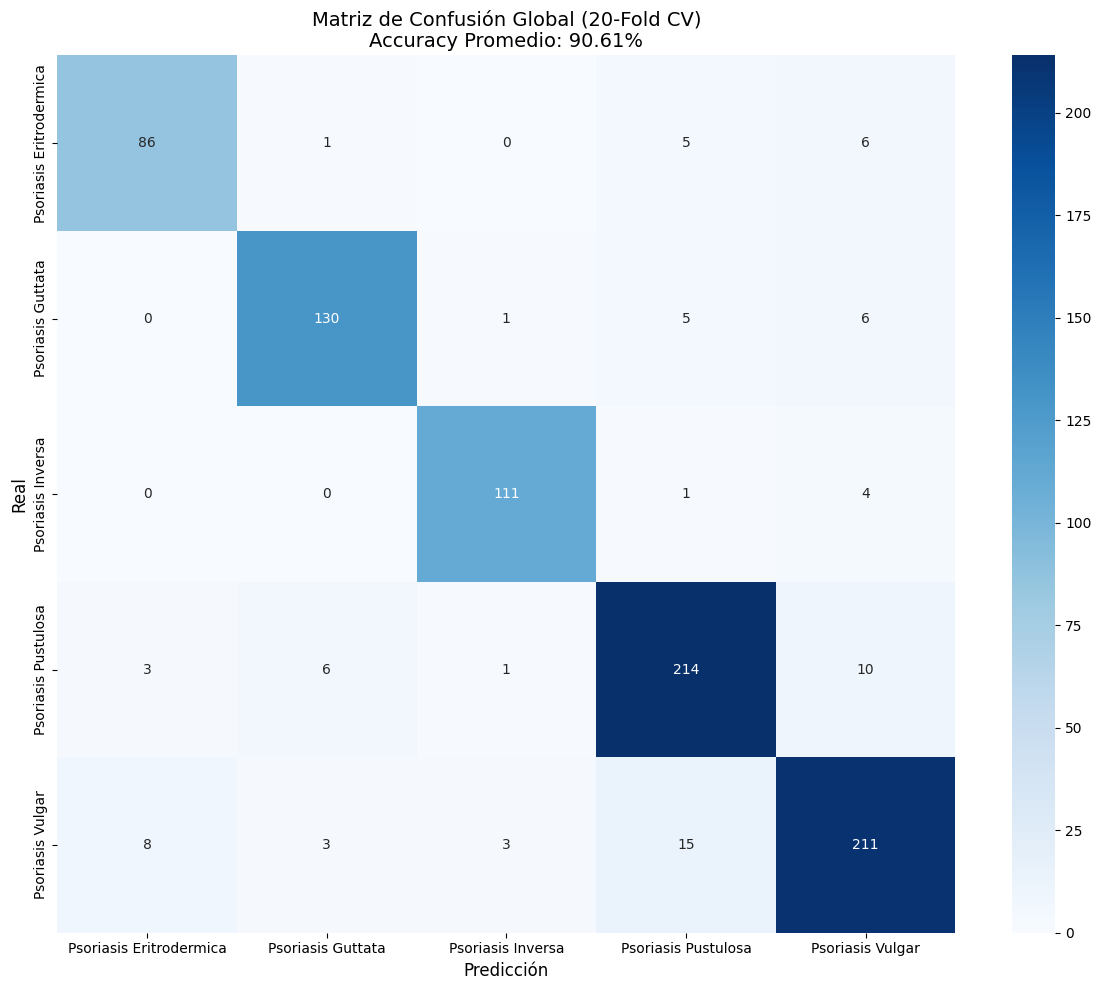


===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====
Cargando el dataset completo de train/val para el modelo final...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 240 imágenes. Objetivo por clase: 600
Generando 502 imágenes para la clase Psoriasis Eritrodermica...
Generando 458 imágenes para la clase Psoriasis Guttata...
Generando 484 imágenes para la clase Psoriasis Inversa...
Generando 366 imágenes para la clase Psoriasis Pustulosa...
Generando 360 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando modelo final con 3000 imágenes...
Epoch 1/100
338/338 - 45s - 134ms/step - accuracy: 0.6822 - loss: 0.9339 - val_accuracy: 0.8267 - val_loss: 0.6369 - learning_rate: 0.0010
Epoch 2/100
338/338 - 5s - 15ms/step - accuracy: 0.8159 - loss: 0.5168 - val_accuracy: 0.8400 - val_loss: 0.5761 - learning_rate: 0.0010
Epoch 3/100
338/338 - 4s - 13ms/step - accuracy: 0.8689 - loss: 0.3559 - val_accuracy: 0.8333 - val

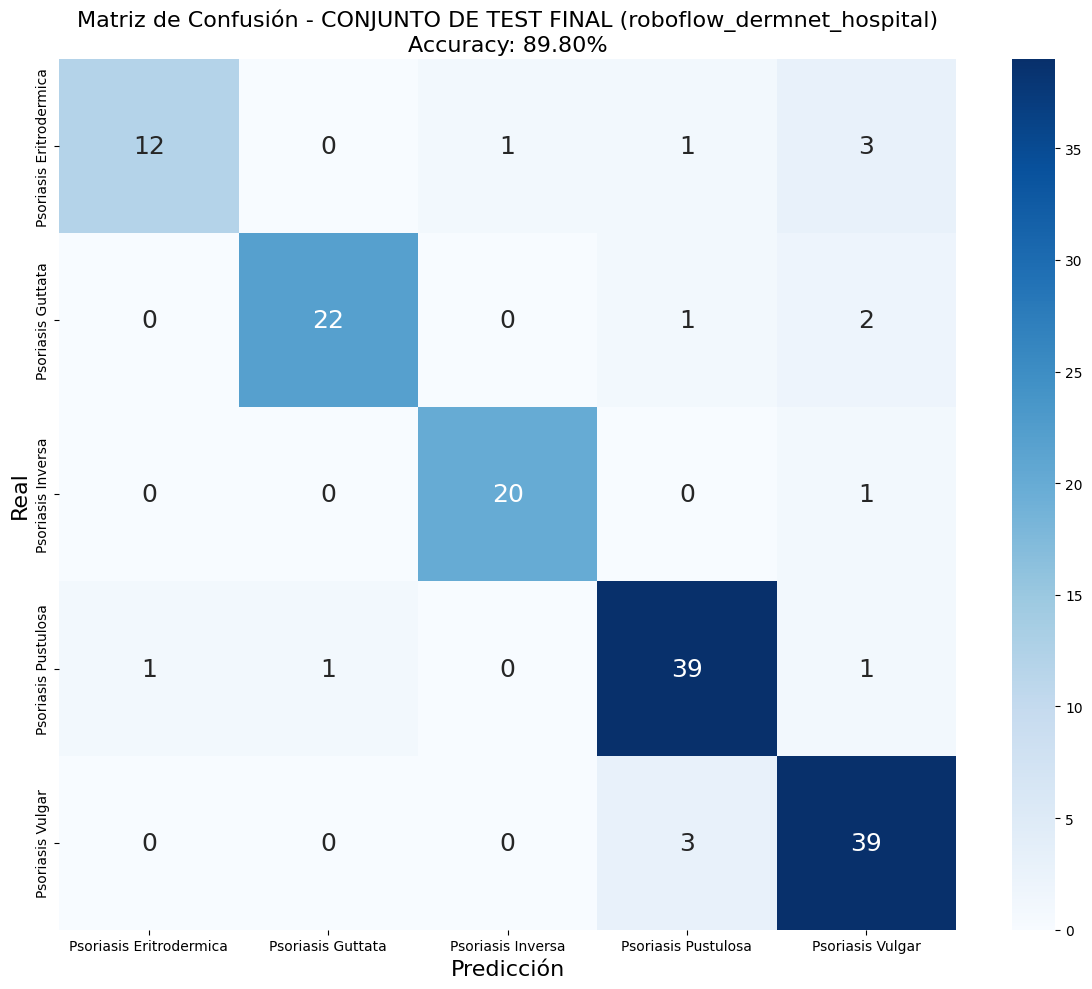


--- PROCESO COMPLETO FINALIZADO ---


In [3]:
# ==============================================================================
# SCRIPT COMPLETO DE ENTRENAMIENTO Y EVALUACIÓN - METODOLOGÍA TFG FINAL
# ==============================================================================
# Este script implementa el protocolo de evaluación de dos niveles:
# 1. Validación Cruzada K-Fold (K=5) sobre el 85% de los datos.
# 2. Entrenamiento de un Modelo Final y Evaluación sobre el 15% de test reservado.
#
# Se asume que el script de preparación con el split 85/15 ya ha sido ejecutado.
# ------------------------------------------------------------------------------

import os
import gc
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter

# Importaciones específicas de la metodología del TFG
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###

# ------------------------------------------------------------------------------
# MODIFICA ESTA VARIABLE PARA CAMBIAR DE EXPERIMENTO
# Opciones: "roboflow", "dermnet", "roboflow_dermnet"
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "roboflow_dermnet_hospital"

# --- Rutas y Configuración General ---
BASE_PATH = "/kaggle/working/datasets_csv_85_15_caseib/splits"
OUTPUT_DIR = f"/kaggle/working/results_{EXPERIMENT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 44
tf.random.set_seed(SEED)
np.random.seed(SEED)

# --- Configuración K-Fold (Sección 3.6 del TFG) ---
N_SPLITS = 20

# --- Configuración del Modelo y Entrenamiento (Secciones 3.3, 3.4, 3.5 del TFG) ---
MODEL_CHOICE = EfficientNetB0
IMG_SIZE = 224 # Tamaño para EfficientNetB0
BATCH_SIZE = 8
EPOCHS = 100 # Un número alto, EarlyStopping decidirá cuándo parar
OVERSAMPLE_FACTOR = 2.5 # Factor de sobremuestreo descrito en el TFG

### --- 2. CARGA DE DATOS --- ###

# Rutas a los nuevos archivos 85/15
train_val_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_train_val_85.csv")
test_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_test_15.csv")

try:
    df_train_val = pd.read_csv(train_val_csv_path)
    df_test = pd.read_csv(test_csv_path)
    print(f"Datos cargados para '{EXPERIMENT_NAME}':")
    print(f"  - {len(df_train_val)} imágenes para K-Fold (85%)")
    print(f"  - {len(df_test)} imágenes para Test Final (15%)")
except FileNotFoundError as e:
    print(f"ERROR: No se encontró el archivo CSV: {e}. Asegúrate de ejecutar la Celda de Preparación primero.")
    raise e

# Mapeo de etiquetas a enteros
class_names = sorted(df_train_val['label_reassigned'].unique())
label_to_int = {label: i for i, label in enumerate(class_names)}
NUM_CLASSES = len(class_names)
df_train_val['label_int'] = df_train_val['label_reassigned'].map(label_to_int)
df_test['label_int'] = df_test['label_reassigned'].map(label_to_int)
print(f"Clases detectadas ({NUM_CLASSES}): {class_names}")


### --- 3. FUNCIONES AUXILIARES (Implementación de la Metodología) --- ###

def load_images_from_df(df):
    """Carga un conjunto de imágenes desde un dataframe a un array de NumPy."""
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(row['label_int'])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
            
    if not images:
        return np.array([]), np.array([])
        
    # Aplicar preprocesamiento de EfficientNet
    images_preprocessed = efficientnet_preprocess(np.array(images))
    return images_preprocessed, tf.keras.utils.to_categorical(np.array(labels), num_classes=NUM_CLASSES)

def balance_dataset_with_augmentation(X_data, y_data):
    """
    Implementación del balanceo de clases descrito en la Sección 3.2 del TFG.
    Aumenta las clases minoritarias hasta 2.5x el tamaño de la clase mayoritaria.
    """
    print("Iniciando balanceo de clases con aumento de datos...")
    
    # Parámetros de ImageDataGenerator descritos en el TFG
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )
    
    y_integers = np.argmax(y_data, axis=1)
    class_counts = Counter(y_integers)
    max_count = max(class_counts.values()) if class_counts else 0
    target_count = int(max_count * OVERSAMPLE_FACTOR)
    print(f"Clase mayoritaria: {max_count} imágenes. Objetivo por clase: {target_count}")

    X_balanced, y_balanced = list(X_data), list(y_data)
    
    for class_idx in range(NUM_CLASSES):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < target_count:
            needed = target_count - current_count
            print(f"Generando {needed} imágenes para la clase {class_names[class_idx]}...")
            
            images_to_augment = X_data[y_integers == class_idx]
            
            generator_flow = datagen.flow(images_to_augment, batch_size=1, seed=SEED)
            for _ in range(needed):
                X_balanced.append(next(generator_flow)[0])
                y_balanced.append(tf.keras.utils.to_categorical(class_idx, num_classes=NUM_CLASSES))
            
    print("Balanceo completado.")
    # Barajar el dataset final
    indices = np.arange(len(X_balanced))
    np.random.shuffle(indices)
    
    return np.array(X_balanced)[indices], np.array(y_balanced)[indices]

def create_model():
    """
    Crea la arquitectura del modelo descrita en la Sección 3.3 del TFG.
    """
    base_model = MODEL_CHOICE(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Base convolucional congelada

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

### --- 4. NIVEL 1 DE EVALUACIÓN: K-FOLD SOBRE EL 85% DEL DATASET --- ###

print("\n===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====")

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_accuracies = []
all_true_labels_kfold = []
all_pred_labels_kfold = []

for fold, (train_indices, val_indices) in enumerate(kf.split(df_train_val, df_train_val['label_int'])):
    print(f"\n--- INICIANDO FOLD {fold+1}/{N_SPLITS} ---")
    
    df_train_fold = df_train_val.iloc[train_indices]
    df_val_fold = df_train_val.iloc[val_indices]

    print("Cargando imágenes del fold en memoria...")
    X_train_fold, y_train_fold = load_images_from_df(df_train_fold)
    X_val_fold, y_val_fold = load_images_from_df(df_val_fold)
    
    if X_train_fold.size == 0 or X_val_fold.size == 0:
        print("Fold vacío, saltando.")
        continue
    
    X_train_balanced, y_train_balanced = balance_dataset_with_augmentation(X_train_fold, y_train_fold)

    model_fold = create_model()
    model_fold.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    
    print(f"Entrenando fold {fold+1} con {len(X_train_balanced)} imágenes de entrenamiento...")
    model_fold.fit(
        X_train_balanced, y_train_balanced,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=2 # Se pone a 0 para no saturar la salida. Cambiar a 1 o 2 para más detalle.
    )
    
    y_pred_probs = model_fold.predict(X_val_fold)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val_fold, axis=1)
    
    fold_accuracies.append(accuracy_score(y_true, y_pred))
    all_true_labels_kfold.extend(y_true)
    all_pred_labels_kfold.extend(y_pred)
    
    print(f"Accuracy del Fold {fold+1}: {fold_accuracies[-1]:.4f}")
    
    del model_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold, X_train_balanced, y_train_balanced
    tf.keras.backend.clear_session()
    gc.collect()

# --- Resultados Globales de K-Fold ---
print("\n--- RESULTADOS GLOBALES DE K-FOLD CROSS-VALIDATION (sobre el 85% del dataset) ---")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Precisión (Accuracy) Promedio en Folds de Validación: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
report_kfold = classification_report(all_true_labels_kfold, all_pred_labels_kfold, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación Global (K-Fold):\n", report_kfold)

cm_kfold = confusion_matrix(all_true_labels_kfold, all_pred_labels_kfold)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión Global ({N_SPLITS}-Fold CV)\nAccuracy Promedio: {mean_accuracy:.2%}', fontsize=14)
plt.xlabel('Predicción', fontsize=12); plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kfold_global_confusion_matrix.png"))
plt.show()

### --- 5. NIVEL 2 DE EVALUACIÓN: MODELO FINAL Y TEST RESERVADO (15%) --- ###

print("\n===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====")

# 1. Cargar todos los datos de entrenamiento/validación (el 85% completo)
print("Cargando el dataset completo de train/val para el modelo final...")
X_train_full, y_train_full = load_images_from_df(df_train_val)

# 2. Balancear el dataset completo
X_train_full_balanced, y_train_full_balanced = balance_dataset_with_augmentation(X_train_full, y_train_full)

# 3. Crear y compilar el modelo final
final_model = create_model()
final_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para el modelo final
final_model_path = os.path.join(OUTPUT_DIR, "final_model_best.h5")
checkpoint_final = ModelCheckpoint(final_model_path, monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping_final = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 5. Entrenar el modelo final
print(f"Entrenando modelo final con {len(X_train_full_balanced)} imágenes...")
# Usamos validation_split aquí para que los callbacks tengan datos en los que basarse.
final_model.fit(
    X_train_full_balanced, y_train_full_balanced,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1, # 10% de los datos de entrenamiento para validar internamente
    callbacks=[checkpoint_final, early_stopping_final, reduce_lr_final],
    verbose=2
)

# 6. Cargar los datos de test y el mejor modelo guardado
print("\n--- EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST RESERVADO (15%) ---")
X_test, y_test = load_images_from_df(df_test)
best_final_model = tf.keras.models.load_model(final_model_path)

# 7. Evaluar y mostrar resultados finales
loss, accuracy = best_final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nResultados en el Conjunto de Test Final:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

y_pred_probs_test = best_final_model.predict(X_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test, axis=1)

report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación (Test Final):\n", report_test)
with open(os.path.join(OUTPUT_DIR, "final_test_report.txt"), "w") as f:
    f.write(report_test)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
plt.title(f'Matriz de Confusión - CONJUNTO DE TEST FINAL ({EXPERIMENT_NAME})\nAccuracy: {accuracy:.2%}', fontsize=16)
plt.xlabel('Predicción', fontsize=16)
plt.ylabel('Real', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_test_confusion_matrix.png"))
plt.show()

print("\n--- PROCESO COMPLETO FINALIZADO ---")

2025-08-29 17:19:34.112403: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756487974.453024      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756487974.550811      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Datos cargados para 'roboflow_dermnet_hospital':
  - 830 imágenes para K-Fold (85%)
  - 147 imágenes para Test Final (15%)
Clases detectadas (5): ['Psoriasis Eritrodermica', 'Psoriasis Guttata', 'Psoriasis Inversa', 'Psoriasis Pustulosa', 'Psoriasis Vulgar']

===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====

--- INICIANDO FOLD 1/30 ---
Cargando imágenes del fold en memoria...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 232 imágenes. Objetivo por clase: 580
Generando 485 imágenes para la clase Psoriasis Eritrodermica...
Generando 443 imágenes para la clase Psoriasis Guttata...
Generando 468 imágenes para la clase Psoriasis Inversa...
Generando 354 imágenes para la clase Psoriasis Pustulosa...
Generando 348 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.


I0000 00:00:1756488019.305331      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756488019.305983      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenando fold 1 con 2900 imágenes de entrenamiento...
Epoch 1/100


I0000 00:00:1756488042.319229      97 service.cc:148] XLA service 0x7d9e900506a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756488042.320731      97 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756488042.320752      97 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756488044.246115      97 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1756488054.103552      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


363/363 - 52s - 143ms/step - accuracy: 0.6952 - loss: 0.8989 - val_accuracy: 0.7143 - val_loss: 0.7731 - learning_rate: 0.0010
Epoch 2/100
363/363 - 4s - 12ms/step - accuracy: 0.8117 - loss: 0.5203 - val_accuracy: 0.6786 - val_loss: 1.1548 - learning_rate: 0.0010
Epoch 3/100
363/363 - 4s - 12ms/step - accuracy: 0.8614 - loss: 0.4014 - val_accuracy: 0.8571 - val_loss: 0.5724 - learning_rate: 0.0010
Epoch 4/100
363/363 - 4s - 12ms/step - accuracy: 0.8886 - loss: 0.3138 - val_accuracy: 0.7857 - val_loss: 0.9570 - learning_rate: 0.0010
Epoch 5/100
363/363 - 4s - 12ms/step - accuracy: 0.9062 - loss: 0.2520 - val_accuracy: 0.6071 - val_loss: 1.4245 - learning_rate: 0.0010
Epoch 6/100
363/363 - 4s - 12ms/step - accuracy: 0.9272 - loss: 0.2124 - val_accuracy: 0.7500 - val_loss: 0.8165 - learning_rate: 0.0010
Epoch 7/100
363/363 - 4s - 12ms/step - accuracy: 0.9307 - loss: 0.1988 - val_accuracy: 0.7500 - val_loss: 1.1015 - learning_rate: 0.0010
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing le

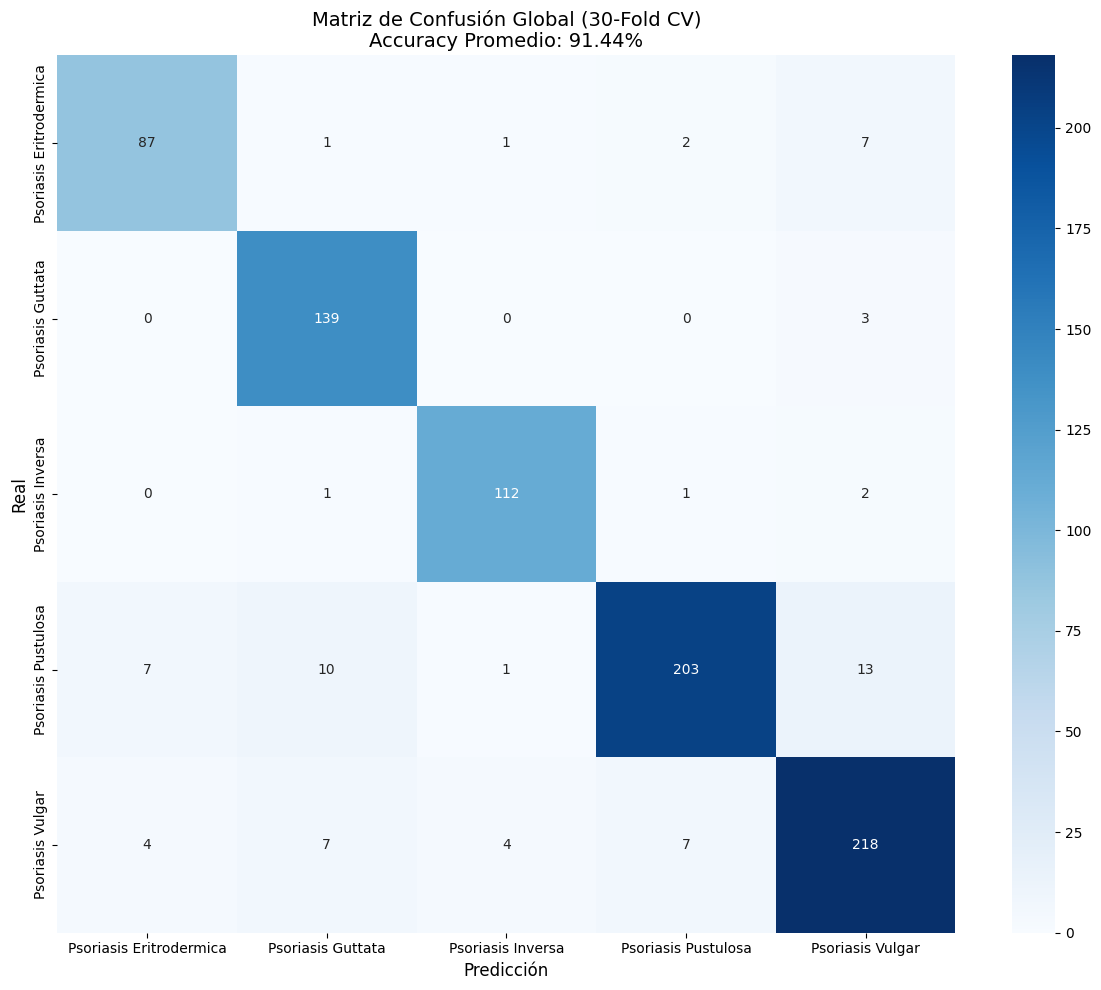


===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====
Cargando el dataset completo de train/val para el modelo final...
Iniciando balanceo de clases con aumento de datos...
Clase mayoritaria: 240 imágenes. Objetivo por clase: 600
Generando 502 imágenes para la clase Psoriasis Eritrodermica...
Generando 458 imágenes para la clase Psoriasis Guttata...
Generando 484 imágenes para la clase Psoriasis Inversa...
Generando 366 imágenes para la clase Psoriasis Pustulosa...
Generando 360 imágenes para la clase Psoriasis Vulgar...
Balanceo completado.
Entrenando modelo final con 3000 imágenes...
Epoch 1/100
338/338 - 46s - 135ms/step - accuracy: 0.6893 - loss: 0.9302 - val_accuracy: 0.8233 - val_loss: 0.6379 - learning_rate: 0.0010
Epoch 2/100
338/338 - 5s - 15ms/step - accuracy: 0.8270 - loss: 0.5020 - val_accuracy: 0.8533 - val_loss: 0.6086 - learning_rate: 0.0010
Epoch 3/100
338/338 - 5s - 15ms/step - accuracy: 0.8593 - loss: 0.3943 - val_accuracy: 0.8567 - val

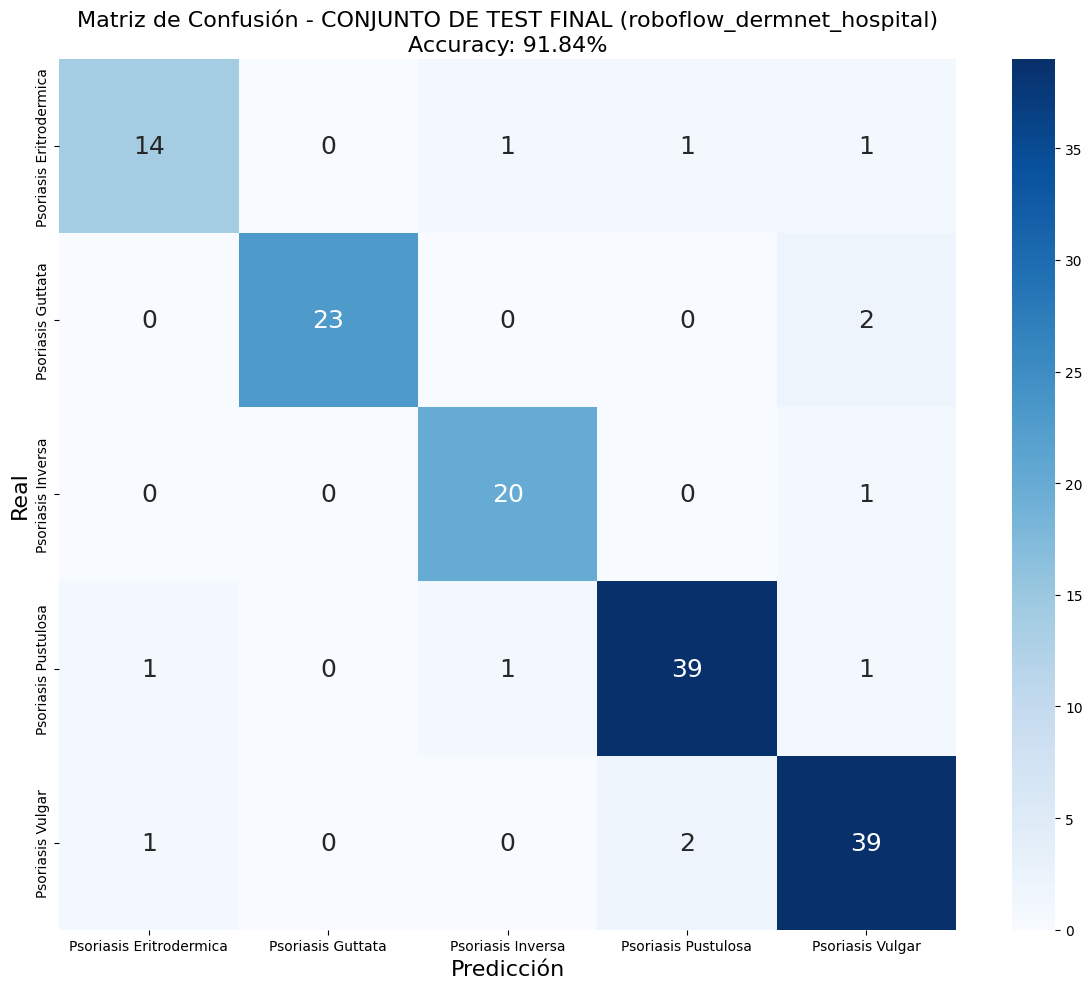


--- PROCESO COMPLETO FINALIZADO ---


In [2]:
# ==============================================================================
# SCRIPT COMPLETO DE ENTRENAMIENTO Y EVALUACIÓN - METODOLOGÍA TFG FINAL
# ==============================================================================
# Este script implementa el protocolo de evaluación de dos niveles:
# 1. Validación Cruzada K-Fold (K=5) sobre el 85% de los datos.
# 2. Entrenamiento de un Modelo Final y Evaluación sobre el 15% de test reservado.
#
# Se asume que el script de preparación con el split 85/15 ya ha sido ejecutado.
# ------------------------------------------------------------------------------

import os
import gc
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter

# Importaciones específicas de la metodología del TFG
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

### --- 1. CONFIGURACIÓN DEL EXPERIMENTO --- ###

# ------------------------------------------------------------------------------
# MODIFICA ESTA VARIABLE PARA CAMBIAR DE EXPERIMENTO
# Opciones: "roboflow", "dermnet", "roboflow_dermnet"
# ------------------------------------------------------------------------------
EXPERIMENT_NAME = "roboflow_dermnet_hospital"

# --- Rutas y Configuración General ---
BASE_PATH = "/kaggle/working/datasets_csv_85_15_caseib/splits"
OUTPUT_DIR = f"/kaggle/working/results_{EXPERIMENT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
SEED = 44
tf.random.set_seed(SEED)
np.random.seed(SEED)

# --- Configuración K-Fold (Sección 3.6 del TFG) ---
N_SPLITS = 30

# --- Configuración del Modelo y Entrenamiento (Secciones 3.3, 3.4, 3.5 del TFG) ---
MODEL_CHOICE = EfficientNetB0
IMG_SIZE = 224 # Tamaño para EfficientNetB0
BATCH_SIZE = 8
EPOCHS = 100 # Un número alto, EarlyStopping decidirá cuándo parar
OVERSAMPLE_FACTOR = 2.5 # Factor de sobremuestreo descrito en el TFG

### --- 2. CARGA DE DATOS --- ###

# Rutas a los nuevos archivos 85/15
train_val_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_train_val_85.csv")
test_csv_path = os.path.join(BASE_PATH, f"{EXPERIMENT_NAME}_test_15.csv")

try:
    df_train_val = pd.read_csv(train_val_csv_path)
    df_test = pd.read_csv(test_csv_path)
    print(f"Datos cargados para '{EXPERIMENT_NAME}':")
    print(f"  - {len(df_train_val)} imágenes para K-Fold (85%)")
    print(f"  - {len(df_test)} imágenes para Test Final (15%)")
except FileNotFoundError as e:
    print(f"ERROR: No se encontró el archivo CSV: {e}. Asegúrate de ejecutar la Celda de Preparación primero.")
    raise e

# Mapeo de etiquetas a enteros
class_names = sorted(df_train_val['label_reassigned'].unique())
label_to_int = {label: i for i, label in enumerate(class_names)}
NUM_CLASSES = len(class_names)
df_train_val['label_int'] = df_train_val['label_reassigned'].map(label_to_int)
df_test['label_int'] = df_test['label_reassigned'].map(label_to_int)
print(f"Clases detectadas ({NUM_CLASSES}): {class_names}")


### --- 3. FUNCIONES AUXILIARES (Implementación de la Metodología) --- ###

def load_images_from_df(df):
    """Carga un conjunto de imágenes desde un dataframe a un array de NumPy."""
    images, labels = [], []
    for _, row in df.iterrows():
        try:
            img = load_img(row['filepath'], target_size=(IMG_SIZE, IMG_SIZE))
            img_array = img_to_array(img)
            images.append(img_array)
            labels.append(row['label_int'])
        except Exception as e:
            print(f"Error cargando imagen {row['filepath']}: {e}")
            
    if not images:
        return np.array([]), np.array([])
        
    # Aplicar preprocesamiento de EfficientNet
    images_preprocessed = efficientnet_preprocess(np.array(images))
    return images_preprocessed, tf.keras.utils.to_categorical(np.array(labels), num_classes=NUM_CLASSES)

def balance_dataset_with_augmentation(X_data, y_data):
    """
    Implementación del balanceo de clases descrito en la Sección 3.2 del TFG.
    Aumenta las clases minoritarias hasta 2.5x el tamaño de la clase mayoritaria.
    """
    print("Iniciando balanceo de clases con aumento de datos...")
    
    # Parámetros de ImageDataGenerator descritos en el TFG
    datagen = ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        brightness_range=[0.9, 1.1],
        fill_mode='nearest'
    )
    
    y_integers = np.argmax(y_data, axis=1)
    class_counts = Counter(y_integers)
    max_count = max(class_counts.values()) if class_counts else 0
    target_count = int(max_count * OVERSAMPLE_FACTOR)
    print(f"Clase mayoritaria: {max_count} imágenes. Objetivo por clase: {target_count}")

    X_balanced, y_balanced = list(X_data), list(y_data)
    
    for class_idx in range(NUM_CLASSES):
        current_count = class_counts.get(class_idx, 0)
        if 0 < current_count < target_count:
            needed = target_count - current_count
            print(f"Generando {needed} imágenes para la clase {class_names[class_idx]}...")
            
            images_to_augment = X_data[y_integers == class_idx]
            
            generator_flow = datagen.flow(images_to_augment, batch_size=1, seed=SEED)
            for _ in range(needed):
                X_balanced.append(next(generator_flow)[0])
                y_balanced.append(tf.keras.utils.to_categorical(class_idx, num_classes=NUM_CLASSES))
            
    print("Balanceo completado.")
    # Barajar el dataset final
    indices = np.arange(len(X_balanced))
    np.random.shuffle(indices)
    
    return np.array(X_balanced)[indices], np.array(y_balanced)[indices]

def create_model():
    """
    Crea la arquitectura del modelo descrita en la Sección 3.3 del TFG.
    """
    base_model = MODEL_CHOICE(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Base convolucional congelada

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

### --- 4. NIVEL 1 DE EVALUACIÓN: K-FOLD SOBRE EL 85% DEL DATASET --- ###

print("\n===== INICIANDO NIVEL 1: VALIDACIÓN CRUZADA K-FOLD (K=5) sobre el 85% =====")

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_accuracies = []
all_true_labels_kfold = []
all_pred_labels_kfold = []

for fold, (train_indices, val_indices) in enumerate(kf.split(df_train_val, df_train_val['label_int'])):
    print(f"\n--- INICIANDO FOLD {fold+1}/{N_SPLITS} ---")
    
    df_train_fold = df_train_val.iloc[train_indices]
    df_val_fold = df_train_val.iloc[val_indices]

    print("Cargando imágenes del fold en memoria...")
    X_train_fold, y_train_fold = load_images_from_df(df_train_fold)
    X_val_fold, y_val_fold = load_images_from_df(df_val_fold)
    
    if X_train_fold.size == 0 or X_val_fold.size == 0:
        print("Fold vacío, saltando.")
        continue
    
    X_train_balanced, y_train_balanced = balance_dataset_with_augmentation(X_train_fold, y_train_fold)

    model_fold = create_model()
    model_fold.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    
    print(f"Entrenando fold {fold+1} con {len(X_train_balanced)} imágenes de entrenamiento...")
    model_fold.fit(
        X_train_balanced, y_train_balanced,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=2 # Se pone a 0 para no saturar la salida. Cambiar a 1 o 2 para más detalle.
    )
    
    y_pred_probs = model_fold.predict(X_val_fold)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val_fold, axis=1)
    
    fold_accuracies.append(accuracy_score(y_true, y_pred))
    all_true_labels_kfold.extend(y_true)
    all_pred_labels_kfold.extend(y_pred)
    
    print(f"Accuracy del Fold {fold+1}: {fold_accuracies[-1]:.4f}")
    
    del model_fold, X_train_fold, y_train_fold, X_val_fold, y_val_fold, X_train_balanced, y_train_balanced
    tf.keras.backend.clear_session()
    gc.collect()

# --- Resultados Globales de K-Fold ---
print("\n--- RESULTADOS GLOBALES DE K-FOLD CROSS-VALIDATION (sobre el 85% del dataset) ---")
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

print(f"Precisión (Accuracy) Promedio en Folds de Validación: {mean_accuracy:.4f} (+/- {std_accuracy:.4f})")
report_kfold = classification_report(all_true_labels_kfold, all_pred_labels_kfold, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación Global (K-Fold):\n", report_kfold)

cm_kfold = confusion_matrix(all_true_labels_kfold, all_pred_labels_kfold)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_kfold, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión Global ({N_SPLITS}-Fold CV)\nAccuracy Promedio: {mean_accuracy:.2%}', fontsize=14)
plt.xlabel('Predicción', fontsize=12); plt.ylabel('Real', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kfold_global_confusion_matrix.png"))
plt.show()

### --- 5. NIVEL 2 DE EVALUACIÓN: MODELO FINAL Y TEST RESERVADO (15%) --- ###

print("\n===== INICIANDO NIVEL 2: ENTRENAMIENTO FINAL Y EVALUACIÓN SOBRE EL 15% DE TEST =====")

# 1. Cargar todos los datos de entrenamiento/validación (el 85% completo)
print("Cargando el dataset completo de train/val para el modelo final...")
X_train_full, y_train_full = load_images_from_df(df_train_val)

# 2. Balancear el dataset completo
X_train_full_balanced, y_train_full_balanced = balance_dataset_with_augmentation(X_train_full, y_train_full)

# 3. Crear y compilar el modelo final
final_model = create_model()
final_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks para el modelo final
final_model_path = os.path.join(OUTPUT_DIR, "final_model_best.h5")
checkpoint_final = ModelCheckpoint(final_model_path, monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping_final = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# 5. Entrenar el modelo final
print(f"Entrenando modelo final con {len(X_train_full_balanced)} imágenes...")
# Usamos validation_split aquí para que los callbacks tengan datos en los que basarse.
final_model.fit(
    X_train_full_balanced, y_train_full_balanced,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1, # 10% de los datos de entrenamiento para validar internamente
    callbacks=[checkpoint_final, early_stopping_final, reduce_lr_final],
    verbose=2
)

# 6. Cargar los datos de test y el mejor modelo guardado
print("\n--- EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST RESERVADO (15%) ---")
X_test, y_test = load_images_from_df(df_test)
best_final_model = tf.keras.models.load_model(final_model_path)

# 7. Evaluar y mostrar resultados finales
loss, accuracy = best_final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nResultados en el Conjunto de Test Final:")
print(f"Pérdida (Loss): {loss:.4f}")
print(f"Precisión (Accuracy): {accuracy:.4f}")

y_pred_probs_test = best_final_model.predict(X_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test, axis=1)

report_test = classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0)
print("\nInforme de Clasificación (Test Final):\n", report_test)
with open(os.path.join(OUTPUT_DIR, "final_test_report.txt"), "w") as f:
    f.write(report_test)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 18})
plt.title(f'Matriz de Confusión - CONJUNTO DE TEST FINAL ({EXPERIMENT_NAME})\nAccuracy: {accuracy:.2%}', fontsize=16)
plt.xlabel('Predicción', fontsize=16)
plt.ylabel('Real', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_test_confusion_matrix.png"))
plt.show()

print("\n--- PROCESO COMPLETO FINALIZADO ---")